# IMU - Thesis

Filip and Gottfrid

## 1.2 Reading Data from Files

Read your data from the file into a DataFrame variable so that the column names correspond with
the field names from the dataset. Print a list of all the column names.

First we start of by importing all libraries needed for this assignment and defining paths for the files.

### 1.2.1 Importing libraries

In [2]:
#@title
# Import all libraries needed for this tutorial

# Pandas: used to create and work with DataFrames
import pandas as pd #imports all of pandas library
from pandas import DataFrame, read_csv #imports some of the important functions from the pandas library.

# Scikit-learn: import preprocessing functions
from sklearn.preprocessing import LabelEncoder, label_binarize, OrdinalEncoder

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Matplotlib: used for data visualization/plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
# Enable inline plotting, allows the plots to be seen in the notebook and stored with the document
%matplotlib inline

# numpy
import numpy as np

# seaborn: used for heatmaps and other statistical plots
import seaborn as sns #might require installation with: conda install -c anaconda seaborn

# Importing statistical function for t-test from scipy
import scipy.stats as stats

# import KMeans
from sklearn.cluster import KMeans
# import nearest neighbors
#from sklearn.neighbors import NearestNeighbors

# Saving variables as files on disk
import pickle

import warnings
warnings.filterwarnings("ignore") #some warnings are supressed



KeyboardInterrupt: 

### 1.2.2 Opening and saving data to variables

In our group we had one person (Arvid) working on his own computer and the rest of the group (Filip and Jens) working on Google Colab, which led to us having to include two different sections for opening and saving data. So At 1.2.2 and 1.4.8 you will find two different sections for opening and saving data.

#### 1.2.2.2 Using own computer

In [ ]:
# If you are working on your own computer, change the working directory to the lab-1 folder
import os

# Print the current working directory
print("Current working directory:", os.getcwd())

# Change the working directory to the lab-1 folder
os.chdir("./lab-assignments/lab-1/") # If you (probably Gion) are working on your own computer, modify this to navigate to the correct folder
#print("Current working directory:", os.getcwd())

Current working directory: /Users/filipnordqvist


FileNotFoundError: [Errno 2] No such file or directory: './lab-assignments/lab-1/'

In [1498]:
#print("Current working directory:", os.getcwd())

# Opening and saving data to variables

# Saving emission data
rawdata_emissions=pd.read_csv('CO2 emission by countries.csv', sep=",", encoding='latin1')

# Saving world population data
rawdata_population=pd.read_csv('population-for-countries-by-year.csv', sep=",")

# Saving world emission data v2
new_emission_data=pd.read_csv('annual-co2-emissions-per-country.csv')

# Saving world event data
rawdata_worlds_events=pd.read_csv('World Important Dates.csv')

# Saving % of GDP in industries data
rawdata_gdp_industries=pd.read_csv('Download-Shares-countries.csv')

# Saving life expectancy data
rawdata_life_expectancy=pd.read_csv('Life Expectancy Data.csv')


print("Emissions DataFrame Columns:", rawdata_emissions.columns)
print("Population DataFrame Columns:", rawdata_population.columns)
print("World Events DataFrame Columns:", rawdata_worlds_events.columns)

Emissions DataFrame Columns: Index(['Country', 'Code', 'Calling Code', 'Year', 'CO2 emission (Tons)',
       'Population(2022)', 'Area', '% of World', 'Density(km2)'],
      dtype='object')
Population DataFrame Columns: Index(['geo', 'name', 'time', 'Population'], dtype='object')
World Events DataFrame Columns: Index(['Sl. No', 'Name of Incident', 'Date', 'Month', 'Year', 'Country',
       'Type of Event', 'Place Name', 'Impact', 'Affected Population',
       'Important Person/Group Responsible', 'Outcome'],
      dtype='object')


### 1.2.3 Looking at the data


In [1499]:
rawdata_worlds_events[rawdata_worlds_events['Country'] == 'Saudi Arabia']

,Sl. No,Name of Incident,Date,Month,Year,Country,Type of Event,Place Name,Impact,Affected Population,Important Person/Group Responsible,Outcome
444,476,First Saudi State Established,Unknown,Unknown,1744,Saudi Arabia,State Formation,Diriyah,Marked the beginning of Saudi rule in the Arab...,Arabian Peninsula,"Muhammad ibn Saud, Muhammad ibn Abd alUnknownW...",Positive
445,477,Destruction of the First Saudi State,Unknown,Unknown,1818,Saudi Arabia,Military Defeat,Diriyah,The First Saudi State was destroyed by the Ott...,Arabian Peninsula,Ottoman Empire,Negative
446,478,Establishment of the Second Saudi State,Unknown,Unknown,1824,Saudi Arabia,State Formation,Najd,"Following the fall of the First Saudi State, t...",Arabian Peninsula,Turki ibn Abdullah ibn Muhammad,Positive
447,479,Annexation of Hejaz,Unknown,Unknown,1925,Saudi Arabia,Territorial Expansion,Hejaz,The conquest of Hejaz was a significant territ...,Hejaz,Abdulaziz Ibn Saud,Positive
448,480,Ikhwan Revolt,Unknown,Unknown,1929,Saudi Arabia,Rebellion,"Najd, Hejaz","The Ikhwan, initially allies of Ibn Saud, revo...",Arabian Peninsula,"Ikhwan, Abdulaziz Ibn Saud",Mixed
449,481,Treaty of Jeddah,Unknown,Unknown,1927,Saudi Arabia,Diplomatic Agreement,Jeddah,This treaty between Ibn Saud and the United Ki...,"Arabian Peninsula, UK","Abdulaziz Ibn Saud, United Kingdom",Positive
450,482,Discovery of Oil,3,March,1938,Saudi Arabia,Economic Development,Dammam,The discovery of oil transformed the economy o...,Saudi Arabia,Saudi Aramco,Positive
451,483,Founding of Saudi Aramco,Unknown,Unknown,1933,Saudi Arabia,Economic Development,Dhahran,The creation of the Arabian American Oil Compa...,Saudi Arabia,"Saudi Government, American oil companies",Positive
452,484,Establishment of the Kingdom of Saudi Arabia,23,September,1932,Saudi Arabia,Political Unification,Saudi Arabia,Abdulaziz Ibn Saud unified the regions into a ...,Arabian Peninsula,Abdulaziz Ibn Saud,Positive
453,485,SaudiUnknownYemeni War,Unknown,Unknown,1934,Saudi Arabia,Military Conflict,Yemen border,Conflict with Yemen resulted in the Treaty of ...,"Saudi Arabia, Yemen",Abdulaziz Ibn Saud,Mixed


#### 1.2.3.1 Looking at the CO2 emission data

In [1500]:
rawdata_emissions.head(3)

,Country,Code,Calling Code,Year,CO2 emission (Tons),Population(2022),Area,% of World,Density(km2)
0,Afghanistan,AF,93,1750,0.0,41128771.0,652230.0,0.40%,63/km²
1,Afghanistan,AF,93,1751,0.0,41128771.0,652230.0,0.40%,63/km²
2,Afghanistan,AF,93,1752,0.0,41128771.0,652230.0,0.40%,63/km²


In [1501]:
rawdata_emissions.dtypes

Country                 object
Code                    object
Calling Code            object
Year                     int64
CO2 emission (Tons)    float64
Population(2022)       float64
Area                   float64
% of World              object
Density(km2)            object
dtype: object

In [1502]:
rawdata_emissions.shape

(59620, 9)

#### 1.2.3.2 Looking at the population data

In [1503]:
rawdata_population.head(3)

,geo,name,time,Population
0,afg,Afghanistan,1800,3280000.0
1,afg,Afghanistan,1801,3280000.0
2,afg,Afghanistan,1802,3280000.0


In [1504]:
rawdata_population.dtypes

geo            object
name           object
time            int64
Population    float64
dtype: object

In [1505]:
rawdata_population.shape

(59297, 4)

#### 1.2.3.3 Looking at the improved CO2 emission data

In [1506]:
new_emission_data.head(3)

,Entity,Code,Year,Annual CO₂ emissions
0,Afghanistan,AFG,1949,14656.0
1,Afghanistan,AFG,1950,84272.0
2,Afghanistan,AFG,1951,91600.0


In [1507]:
new_emission_data.dtypes

Entity                   object
Code                     object
Year                      int64
Annual CO₂ emissions    float64
dtype: object

In [1508]:
new_emission_data.shape

(30308, 4)

#### 1.2.3.4 Looking at the world events data

In [1509]:
rawdata_worlds_events.head(3)

,Sl. No,Name of Incident,Date,Month,Year,Country,Type of Event,Place Name,Impact,Affected Population,Important Person/Group Responsible,Outcome
0,1,Indus Valley Civilization Flourishes,Unknown,Unknown,2600 BC,India,Civilization,Indus Valley,Development of one of the world's earliest urb...,Local inhabitants,Indus Valley people,Positive
1,2,Battle of the Ten Kings,Unknown,Unknown,1400 BC,India,Battle,Punjab,Rigvedic tribes consolidated their control ove...,Rigvedic tribes,Sudas,Positive
2,6,Establishment of the Delhi Sultanate,Unknown,Unknown,1206,India,Political,Delhi,Muslim rule established in parts of India,People of Delhi and surrounding regions,QutbUnknownudUnknowndin Aibak,Mixed


In [1510]:
rawdata_worlds_events.dtypes

Sl. No                                 int64
Name of Incident                      object
Date                                  object
Month                                 object
Year                                  object
Country                               object
Type of Event                         object
Place Name                            object
Impact                                object
Affected Population                   object
Important Person/Group Responsible    object
Outcome                               object
dtype: object

In [1511]:
rawdata_worlds_events.shape

(1096, 12)

#### 1.2.3.5 Looking at the % of GDP in industries data

In [1512]:
rawdata_gdp_industries.head(3)

,Shares of breakdown of GDP/Value Added at current prices in Percent (all countries),Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50,Unnamed: 51,Unnamed: 52,Unnamed: 53,Unnamed: 54,Unnamed: 55
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CountryID,Country,IndicatorName,1970,1971,1972,1973,1974,1975,1976,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
2,4,Afghanistan,Final consumption expenditure,"96,7","99,8","96,8","94,5","92,1","91,8","88,0",...,"110,1","103,4","101,9","101,0","97,7","110,5","110,4","114,4","109,7","119,5"


In [1513]:
rawdata_gdp_industries.dtypes

Shares of breakdown of GDP/Value Added at current prices in Percent (all countries)    object
Unnamed: 1                                                                             object
Unnamed: 2                                                                             object
Unnamed: 3                                                                             object
Unnamed: 4                                                                             object
Unnamed: 5                                                                             object
Unnamed: 6                                                                             object
Unnamed: 7                                                                             object
Unnamed: 8                                                                             object
Unnamed: 9                                                                             object
Unnamed: 10                                                 

In [1514]:
rawdata_gdp_industries.shape

(3277, 56)

#### 1.2.3.6 Looking at Life expectancy data


In [1515]:
rawdata_life_expectancy.head(3)

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9


In [1516]:
rawdata_life_expectancy.dtypes

Country                             object
Year                                 int64
Status                              object
Life expectancy                    float64
Adult Mortality                    float64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
 BMI                               float64
under-five deaths                    int64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
 HIV/AIDS                          float64
GDP                                float64
Population                         float64
 thinness  1-19 years              float64
 thinness 5-9 years                float64
Income composition of resources    float64
Schooling                          float64
dtype: object

In [1517]:
rawdata_life_expectancy.shape

(2938, 22)

## 1.3. Manipulating Data


Go through the list of actions taken in the tutorial to ‘clean’ your data. If needed, show in your
notebook how you carried out the following tasks and show the results that you got after each step:
- finding and handling missing values
- correcting wrong values
- eliminating unreliable data
- checking and converting data types
- solving problems with thousand separators or with other special signs
- ? (contact the teacher if there is something else that causes problems)

We start of by cleaning the **CO2 emission** dataset.

The dataset contains two columns related to country identification: Code and Calling Code. The Code column represents the ISO Alpha-2 country code, while Calling Code contains the international calling code for each country. Since the analysis of CO2 emissions primarily focuses on factors like population, area, and density, and can rely on the Country column for identification, both Code and Calling Code columns are deemed irrelevant and should be removed.

In [1518]:
# Dropping the columns calling code and code
rawdata_emissions = rawdata_emissions.drop(columns=['Calling Code', 'Code'])

# Confirming its removed
rawdata_emissions.columns

Index(['Country', 'Year', 'CO2 emission (Tons)', 'Population(2022)', 'Area',
       '% of World', 'Density(km2)'],
      dtype='object')

We also look at how many null rows there are in the data.

In [1519]:
# See how many rows are null in C02 emission data
rawdata_emissions.isnull().sum()

Country                   0
Year                      0
CO2 emission (Tons)       0
Population(2022)       6504
Area                   4336
% of World             4336
Density(km2)           6504
dtype: int64

In this case it doesn't make sense to set unknown values to zero or to another fixed value since it is a case of no data being available to fill the rows. Therefore the null rows are removed entirely from the Dataframe

In [1520]:
# Deleting all null rows

# Making a copy of the original data
cleaned_rawdata_emissions = rawdata_emissions.copy()

# Showing the dimension of the data before removing rows
print(cleaned_rawdata_emissions.shape)

# Saving and dropping rows
cleaned_rawdata_emissions = cleaned_rawdata_emissions.dropna()

# Showing the dimension of the data after removing rows
print(cleaned_rawdata_emissions.shape)

# Printing final results
print('Total number of missing values after dropna: ')
cleaned_rawdata_emissions.isnull().sum()

(59620, 7)
(51219, 7)
Total number of missing values after dropna: 


Country                0
Year                   0
CO2 emission (Tons)    0
Population(2022)       0
Area                   0
% of World             0
Density(km2)           0
dtype: int64

To further clean the dataset we check if all columns contain the appropiate datatypes.

In [1521]:
# Checking datatypes
cleaned_rawdata_emissions.dtypes

Country                 object
Year                     int64
CO2 emission (Tons)    float64
Population(2022)       float64
Area                   float64
% of World              object
Density(km2)            object
dtype: object

### 1.3.1 Fixing column names
We see that both "% of World" and "Density(km2)" are objects. These should be changed to float64 since they contain integers that we might want to use for calculations and the unit is stated in the column name.

In [1522]:
# Changing the columns value from objects to floats

# Ensure the '% of World' column is string before removing '%'
cleaned_rawdata_emissions['% of World'] = cleaned_rawdata_emissions['% of World'].astype(str).str.rstrip('%').astype('float') / 100.0

# Ensure the 'Density(km2)' column is string before replacing '/km²' and commas
cleaned_rawdata_emissions['Density(km2)'] = cleaned_rawdata_emissions['Density(km2)'].astype(str).str.replace('/km²', '').str.replace(',', '').astype('float')

# Making sure it worked
cleaned_rawdata_emissions.dtypes


Country                 object
Year                     int64
CO2 emission (Tons)    float64
Population(2022)       float64
Area                   float64
% of World             float64
Density(km2)           float64
dtype: object

#### 1.3.1.1 Removing null rows

We then start cleaning the **population dataset**. We start of by removing all null rows and making sure each column contains an appropiate datatype

In [1523]:
# Cleaning world population dataset
rawdata_population.dtypes

# Checking for null values
rawdata_population.isnull()

# Looking what the null values contain
null_rows = rawdata_population.loc[rawdata_population.isnull().any(axis=1)]
print(null_rows)

# Removing rows since they are not relevant
rawdata_population = rawdata_population.dropna()

# Making sure it worked
print(rawdata_population.isnull().sum())

       geo      name  time  Population
21873  hos  Holy See  2001         NaN
21874  hos  Holy See  2002         NaN
21875  hos  Holy See  2003         NaN
21876  hos  Holy See  2004         NaN
21877  hos  Holy See  2005         NaN
...    ...       ...   ...         ...
21968  hos  Holy See  2096         NaN
21969  hos  Holy See  2097         NaN
21970  hos  Holy See  2098         NaN
21971  hos  Holy See  2099         NaN
21972  hos  Holy See  2100         NaN

[100 rows x 4 columns]
geo           0
name          0
time          0
Population    0
dtype: int64


#### 1.3.1.2 Inserting population data
We want to insert the population from the **population dataset** to be able gain insights from the population changes. It is discovered that the population dataset does however not have the same name for each country as in the **CO2 emissions dataset** in all cases so these have to be changed manually. A few countries couldn't be found in **population dataset** so they are removed entirely from the dataset.


In [1524]:
# Renaming countries in order to match the names in the CO2 emission data.
rawdata_population['name'] = rawdata_population['name'].replace({'Slovak Republic': 'Slovakia', 'Swaziland': 'Eswatini', 'St. Vincent and the Grenadines': 'Saint Vincent and the Grenadines', 'St. Lucia': 'Saint Lucia', 'St. Kitts and Nevis': 'Saint Kitts and Nevis', 'Micronesia, Fed. Sts.' : 'Micronesia', 'Kyrgyz Republic': 'Kyrgyzstan', 'Lao' : 'Laos'})

# Removing countries that could not find in population dataset.
countries_to_remove = ['Puerto Rico', 'French Guiana', 'Greenland', 'Guadeloupe', 'Mayotte', 'Martinique']
cleaned_rawdata_emissions = cleaned_rawdata_emissions[~cleaned_rawdata_emissions['Country'].isin(countries_to_remove)]

When the preparation for the merge of data is finished we start inserting the population data from the **population dataset**  in the Population (2022) column of the **CO2 emission dataset** by matching the year and country from both datasets with eachother in order to know which row to insert the population data in.

In [1525]:
# Create a dictionary from rawdata_population for faster lookup
population_dict = {(row['name'], row['time']): row['Population'] for _, row in rawdata_population.iterrows()}

# Now loop through cleaned_rawdata_emissions and replace population values
for i, row in cleaned_rawdata_emissions.iterrows():
    # Get the current country and year from CO2 emission data
    country = row['Country']
    year = row['Year']

    # Check if the (country, year) matches rows in the population_dict
    if (country, year) in population_dict:
        # Replace the population value
        cleaned_rawdata_emissions.at[i, 'Population(2022)'] = population_dict[(country, year)]
    else:
        # If no match is found set it to NaN/another value
        cleaned_rawdata_emissions.at[i, 'Population(2022)'] = -1

cleaned_rawdata_emissions.head()

,Country,Year,CO2 emission (Tons),Population(2022),Area,% of World,Density(km2)
0,Afghanistan,1750,0.0,-1.0,652230.0,0.004,63.0
1,Afghanistan,1751,0.0,-1.0,652230.0,0.004,63.0
2,Afghanistan,1752,0.0,-1.0,652230.0,0.004,63.0
3,Afghanistan,1753,0.0,-1.0,652230.0,0.004,63.0
4,Afghanistan,1754,0.0,-1.0,652230.0,0.004,63.0


We also change the column name of Population(2022) to Population since it now contains data from different years.

In [1526]:
cleaned_rawdata_emissions = cleaned_rawdata_emissions.rename(columns={'Population(2022)': 'Population'})
cleaned_rawdata_emissions.head()
null_rows = cleaned_rawdata_emissions[cleaned_rawdata_emissions.isnull().any(axis=1)]
print(null_rows)

Empty DataFrame
Columns: [Country, Year, CO2 emission (Tons), Population, Area, % of World, Density(km2)]
Index: []


#### 1.3.1.3 Cleaning world events dataset
Now we are to clean the **world events dataset**. We start by removing columns we find irrelevant for our insights and null rows.

In [1527]:
# Removing irrelevant columns
rawdata_worlds_events = rawdata_worlds_events.drop(columns=['Sl. No','Date', 'Place Name', 'Affected Population','Important Person/Group Responsible', 'Outcome'])

# Checking for null rows
rawdata_worlds_events.isnull().sum()

Name of Incident    0
Month               0
Year                0
Country             0
Type of Event       0
Impact              0
dtype: int64

#### 1.3.1.4 Inserting life expectancy data
We realized that we wanted to include life expectancy data in our dataset since it is relevant to our analysis.

In [1528]:
# Get the amount of rows and columns in the dataset
rawdata_life_expectancy.shape

(2938, 22)

In [1529]:
# Initialize the 'Status' column in cleaned_rawdata_emissions with NaN or another default value
rawdata_life_expectancy['Country'].replace({'United States of America' : 'United States', 'United Republic of Tanzania' : 'Tanzania', "Lao People's Democratic Republic" : 'Laos', 'Bolivia (Plurinational State of)' : 'Bolivia', 'Micronesia (Federated States of)' : 'Micronesia', 'Swaziland' : 'Eswatini', 'Iran (Islamic Republic of)': 'Iran', 'Republic of Moldova': 'Moldova', 'Republic of Korea': 'South Korea', "Democratic People's Republic of Korea": 'North Korea','Russian Federation': 'Russia', 'Syrian Arab Republic': 'Syria', 'United Kingdom of Great Britain and Northern Ireland' : 'United Kingdom', 'Venezuela (Bolivarian Republic of)': 'Venezuela', 'Viet Nam' : 'Vietnam' },  inplace=True)

cleaned_rawdata_emissions['Status'] = -1

# Create a dictionary from rawdata_life_expectancy for faster lookup
status_dict = {row['Country']: row['Status'] for _, row in rawdata_life_expectancy.iterrows()}

# Loop through cleaned_rawdata_emissions and fill the 'Status' column based on matching countries
for i, row in cleaned_rawdata_emissions.iterrows():
    country = row['Country']
    if country in status_dict:
        cleaned_rawdata_emissions.at[i, 'Status'] = status_dict[country]

andorra_rows = cleaned_rawdata_emissions[cleaned_rawdata_emissions['Country'] == 'Andorra']
cleaned_rawdata_emissions.loc[andorra_rows.index, 'Status'] = 'Developed'

taiwan_rows = cleaned_rawdata_emissions[cleaned_rawdata_emissions['Country'] == 'Taiwan']
cleaned_rawdata_emissions.loc[taiwan_rows.index, 'Status'] = 'Developed'

liechtenstein_rows = cleaned_rawdata_emissions[cleaned_rawdata_emissions['Country'] == 'Liechtenstein']
cleaned_rawdata_emissions.loc[liechtenstein_rows.index, 'Status'] = 'Developed'

#Display the updated DataFrame
cleaned_rawdata_emissions.head()

,Country,Year,CO2 emission (Tons),Population,Area,% of World,Density(km2),Status
0,Afghanistan,1750,0.0,-1.0,652230.0,0.004,63.0,Developing
1,Afghanistan,1751,0.0,-1.0,652230.0,0.004,63.0,Developing
2,Afghanistan,1752,0.0,-1.0,652230.0,0.004,63.0,Developing
3,Afghanistan,1753,0.0,-1.0,652230.0,0.004,63.0,Developing
4,Afghanistan,1754,0.0,-1.0,652230.0,0.004,63.0,Developing


In [1530]:
# Converting developed and developing
print(cleaned_rawdata_emissions.Status.value_counts())
cleaned_rawdata_emissions.Status=label_binarize(cleaned_rawdata_emissions.Status, classes=['Developing','Developed'])
# Change the name of the column 'Status' to 'Developed'
cleaned_rawdata_emissions.rename(columns={'Status':'Developed'}, inplace=True)

cleaned_rawdata_emissions.head()

Status
Developing    40379
Developed      9214
Name: count, dtype: int64


,Country,Year,CO2 emission (Tons),Population,Area,% of World,Density(km2),Developed
0,Afghanistan,1750,0.0,-1.0,652230.0,0.004,63.0,0
1,Afghanistan,1751,0.0,-1.0,652230.0,0.004,63.0,0
2,Afghanistan,1752,0.0,-1.0,652230.0,0.004,63.0,0
3,Afghanistan,1753,0.0,-1.0,652230.0,0.004,63.0,0
4,Afghanistan,1754,0.0,-1.0,652230.0,0.004,63.0,0


#### 1.3.1.5 Checking for inaproppiate datatypes
We find that the column "Year" should not be a object in order for us to be able to match it with our other data.

It is classified as an object due to years prior to year 0 containing the characters BC in them. Since we only want use data from 1800 we can remove these all togheter while sorting out the years.

To do that we convert the datatype by removing all rows with BC in them, then we convert the datatype to int before removing the years before 1800.

In [1531]:
# Removing all rows containing the characthers "BC" in the Year column
rawdata_worlds_events = rawdata_worlds_events[~rawdata_worlds_events['Year'].str.contains('BC')]

# Converting datatype to ints
rawdata_worlds_events['Year'] = pd.to_numeric(rawdata_worlds_events['Year'], errors='coerce').astype('Int64')

# Removing all rows prior to 1800
rawdata_worlds_events = rawdata_worlds_events[rawdata_worlds_events['Year'] >= 1750]

# Ensuring it worked
rawdata_worlds_events.head()

,Name of Incident,Month,Year,Country,Type of Event,Impact
4,Establishment of British Raj,May,1858,India,Colonial,Start of direct British governance in India
5,Partition of India,August,1947,India,Partition,Creation of India and Pakistan; massive popula...
6,IndoUnknownPakistani War of 1971,December,1971,India,War,Led to the independence of Bangladesh
7,PokhranUnknownII Nuclear Tests,May,1998,India,Nuclear Test,India declared itself a nuclear state
8,Mumbai Terror Attacks,November,2008,India,Terrorism,Highlighted the threat of international terrorism


In [1532]:
new_emission_data.head()

,Entity,Code,Year,Annual CO₂ emissions
0,Afghanistan,AFG,1949,14656.0
1,Afghanistan,AFG,1950,84272.0
2,Afghanistan,AFG,1951,91600.0
3,Afghanistan,AFG,1952,91600.0
4,Afghanistan,AFG,1953,106256.0


When doing the data exploration we found that many values in the emission data must be incorrect due to the massive differences in values from year to year in certain cases. Therefore we imported a new dataset with emission data that we merged with the previous set.

In [1533]:
# Create a dictionary from new_emission_data for faster lookup
new_emission_dict = {(row['Entity'], row['Year']): row['Annual CO₂ emissions'] for _, row in new_emission_data.iterrows()}

# Now loop through cleaned_rawdata_emissions and replace population values
for i, row in cleaned_rawdata_emissions.iterrows():
    # Get the current country and year from CO2 emission data
    country = row['Country']
    year = row['Year']

    # Check if the (country, year) matches rows in the new_emission_dict
    if (country, year) in new_emission_dict:
        # Replace the emission value
        cleaned_rawdata_emissions.at[i, 'CO2 emission (Tons)'] = new_emission_dict[(country, year)]
    else:
        # If no match is found set it to NaN/another value
        cleaned_rawdata_emissions.at[i, 'CO2 emission (Tons)'] = -1

cleaned_rawdata_emissions.head()

,Country,Year,CO2 emission (Tons),Population,Area,% of World,Density(km2),Developed
0,Afghanistan,1750,-1.0,-1.0,652230.0,0.004,63.0,0
1,Afghanistan,1751,-1.0,-1.0,652230.0,0.004,63.0,0
2,Afghanistan,1752,-1.0,-1.0,652230.0,0.004,63.0,0
3,Afghanistan,1753,-1.0,-1.0,652230.0,0.004,63.0,0
4,Afghanistan,1754,-1.0,-1.0,652230.0,0.004,63.0,0


In [1534]:
cleaned_rawdata_emissions[(cleaned_rawdata_emissions['Year'] == 1949) & (cleaned_rawdata_emissions['Country'] == 'Afghanistan')]

,Country,Year,CO2 emission (Tons),Population,Area,% of World,Density(km2),Developed
199,Afghanistan,1949,14656.0,7356890.0,652230.0,0.004,63.0,0


In [1535]:
combined_data = cleaned_rawdata_emissions.copy()

Remove all rows with 0 or less in the CO2 emission column and Population column.

In [1536]:
# Create a copy of the rawdata dataframe that removes all rows with 0 or negative values
clean_data = combined_data[(combined_data["CO2 emission (Tons)"] > 0) & (combined_data["Population"] > 0)]


## 1.4 Analysing Data
### 1.4.1. Understanding the Types and Units of the Different Features
Look at the different features (=columns) and try to identify intervals or feasible ranges (min/max-
values) for (some of) the features?

In [1537]:
# Display unique values for categorical columns
for column in clean_data.select_dtypes(include=["object"]).columns:
    print(f"\nUnique values in {column}:")
    print(clean_data[column].unique())

# Display min and max values for numerical columns
for column in clean_data.select_dtypes(include=["int64", "float64"]).columns:
    print(f"\nRange for {column}:")
    print(f"Min: {clean_data[column].min()}")
    print(f"Max: {clean_data[column].max()}")



Unique values in Country:
['Afghanistan' 'Albania' 'Algeria' 'Andorra' 'Angola'
 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Australia' 'Austria'
 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus'
 'Belgium' 'Belize' 'Benin' 'Bhutan' 'Bolivia' 'Bosnia and Herzegovina'
 'Botswana' 'Brazil' 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cambodia'
 'Cameroon' 'Canada' 'Central African Republic' 'Chad' 'Chile' 'China'
 'Colombia' 'Comoros' 'Costa Rica' 'Croatia' 'Cuba' 'Cyprus' 'Denmark'
 'Djibouti' 'Dominica' 'Dominican Republic' 'Ecuador' 'Egypt'
 'El Salvador' 'Equatorial Guinea' 'Eritrea' 'Estonia' 'Eswatini'
 'Ethiopia' 'Fiji' 'Finland' 'France' 'Gabon' 'Gambia' 'Georgia' 'Germany'
 'Ghana' 'Greece' 'Grenada' 'Guatemala' 'Guinea' 'Guyana' 'Haiti'
 'Honduras' 'Hungary' 'Iceland' 'India' 'Indonesia' 'Iran' 'Iraq'
 'Ireland' 'Israel' 'Italy' 'Jamaica' 'Japan' 'Jordan' 'Kazakhstan'
 'Kenya' 'Kiribati' 'Kuwait' 'Kyrgyzstan' 'Laos' 'Latvia' 'Lebanon'
 'Lesotho' 'Liberia' 'Libya' 'L

#### 1.4.1.1 Min and max values with corresponding countries

In [1538]:
# Function to get min and max values with corresponding countries and additional info
def get_min_max(df, primary_column):
    min_value = df[primary_column].min()
    max_value = df[primary_column].max()
    min_row = df.loc[df[primary_column] == min_value].iloc[0]
    max_row = df.loc[df[primary_column] == max_value].iloc[0]
    return min_value, max_value, min_row, max_row

# Get min and max for CO2 emissions
co2_min, co2_max, co2_min_row, co2_max_row = get_min_max(clean_data, "CO2 emission (Tons)")

print("Range for CO2 emission (Tons):")
print(f"Min: {co2_min:.2f} (Country: {co2_min_row['Country']}, Year: {co2_min_row['Year']}, Population: {co2_min_row['Population']:.0f}, Development (0=Developing, 1=Developed): {co2_min_row['Developed']})")
print(f"Max: {co2_max:.2f} (Country: {co2_max_row['Country']}, Year: {co2_max_row['Year']}, Population: {co2_max_row['Population']:.0f}, Development (0=Developing, 1=Developed): {co2_max_row['Developed']})")

# Get min and max for Population
pop_min, pop_max, pop_min_row, pop_max_row = get_min_max(clean_data, "Population")

print("\nRange for Population:")
print(f"Min: {pop_min:.0f} (Country: {pop_min_row['Country']}, Year: {pop_min_row['Year']}, CO2 emission: {pop_min_row['CO2 emission (Tons)']:.2f}, Development (0=Developing, 1=Developed): {pop_min_row['Developed']})")
print(f"Max: {pop_max:.0f} (Country: {pop_max_row['Country']}, Year: {pop_max_row['Year']}, CO2 emission: {pop_max_row['CO2 emission (Tons)']:.2f}, Development (0=Developing, 1=Developed): {pop_max_row['Developed']})")

Range for CO2 emission (Tons):
Min: 32.00 (Country: Armenia, Year: 1832, Population: 461249, Development (0=Developing, 1=Developed): 0)
Max: 10914012000.00 (Country: China, Year: 2020, Population: 1424929781, Development (0=Developing, 1=Developed): 0)

Range for Population:
Min: 5484 (Country: Nauru, Year: 1964, CO2 emission: 29312.00, Development (0=Developing, 1=Developed): 0)
Max: 1424929781 (Country: China, Year: 2020, CO2 emission: 10914012000.00, Development (0=Developing, 1=Developed): 0)


#### 1.4.1.2 Get min and max for Emissions per person

In [1539]:
# Calculate emissions per person
clean_data["Emissions_per_person"] = clean_data["CO2 emission (Tons)"] / clean_data["Population"]

# Function to get min and max values with corresponding information
def get_min_max(df, column):
    min_value = df[column].min()
    max_value = df[column].max()
    min_row = df.loc[df[column] == min_value].iloc[0]
    max_row = df.loc[df[column] == max_value].iloc[0]
    return min_value, max_value, min_row, max_row

# Get min and max for Emissions per person
emissions_per_person_min, emissions_per_person_max, min_row, max_row = get_min_max(clean_data, "Emissions_per_person")

print("Range for CO2 emissions per person (Tons):")
print(f"Min: {emissions_per_person_min:.10f} (Country: {min_row['Country']}, Year: {min_row['Year']})")
print(f"Max: {emissions_per_person_max:.10f} (Country: {max_row['Country']}, Year: {max_row['Year']})")

clean_data.drop(columns=["Emissions_per_person"], inplace=True)

Range for CO2 emissions per person (Tons):
Min: 0.0000501467 (Country: Georgia, Year: 1832)
Max: 367.9292870474 (Country: Kuwait, Year: 1991)


### 1.4.2 Looking at statistical descriptions of the features

The first time we looked at our data we found that the data we were using for CO2 emissions were incorrect and far from the references we found online, on platforms such as Our World in Data. Therefore we used a new dataset with emission data that we merged with the previous set.

In [1540]:
# Define regions to exclude
regions_to_exclude = ['World', 'Africa', 'Asia', 'Europe', 'North America', 'South America', 'Oceania', 'Non-OECD (GCP)', 'Asia (GCP)', 'Upper-middle-income countries', 'High-income countries', 'OECD (GCP)']

# For rawdata_emissions
raw_data = rawdata_emissions[~rawdata_emissions['Country'].isin(regions_to_exclude)]
raw_max = raw_data["CO2 emission (Tons)"].max()
raw_min = raw_data[raw_data["CO2 emission (Tons)"] > 0]["CO2 emission (Tons)"].min()

raw_max_info = raw_data.loc[raw_data["CO2 emission (Tons)"] == raw_max].iloc[0]
raw_min_info = raw_data.loc[raw_data["CO2 emission (Tons)"] == raw_min].iloc[0]

# For new_emission_data
new_data = new_emission_data[~new_emission_data['Entity'].isin(regions_to_exclude)]
new_max = new_data["Annual CO₂ emissions"].max()
new_min = new_data[new_data["Annual CO₂ emissions"] > 0]["Annual CO₂ emissions"].min()

new_max_info = new_data.loc[new_data["Annual CO₂ emissions"] == new_max].iloc[0]
new_min_info = new_data.loc[new_data["Annual CO₂ emissions"] == new_min].iloc[0]

print("Raw Emissions Data:")
print(f"Max: {raw_max:,.0f} tons (Country: {raw_max_info['Country']}, Year: {raw_max_info['Year']})")
print(f"Min (excluding zero): {raw_min:,.0f} tons (Country: {raw_min_info['Country']}, Year: {raw_min_info['Year']})")

print("\nNew Emissions Data:")
print(f"Max: {new_max:,.0f} tons (Country: {new_max_info['Entity']}, Year: {new_max_info['Year']})")
print(f"Min (excluding zero): {new_min:,.0f} tons (Country: {new_min_info['Entity']}, Year: {new_min_info['Year']})")

Raw Emissions Data:
Max: 417,000,000,000 tons (Country: United States, Year: 2020)
Min (excluding zero): 42 tons (Country: Armenia, Year: 1830)

New Emissions Data:
Max: 11,396,777,000 tons (Country: China, Year: 2022)
Min (excluding zero): 32 tons (Country: Armenia, Year: 1832)


As can be seen by the max values the emission data highly differ. Since most data references we could find online concur with the latter dataset we decided to use that data instead.

When looking at the global world emissions of 2020 we could find that the emission for the whole world was approximately [37 billion tons](https://www.iea.org/reports/global-energy-review-2020/global-energy-and-co2-emissions-in-2020). While the first dataset said that the United States 2020 had alone let out almost 417 billion tons.  

#### 1.4.2.1 Setting unfeasible values to feasible
We removed all unfeasible data just before by changing dataset. We also removed all -1 values that we added to avoid NaN or empty values just before step 1.4.

#### 1.4.2.2 Scatter Plot of CO2 Emissions vs. Population

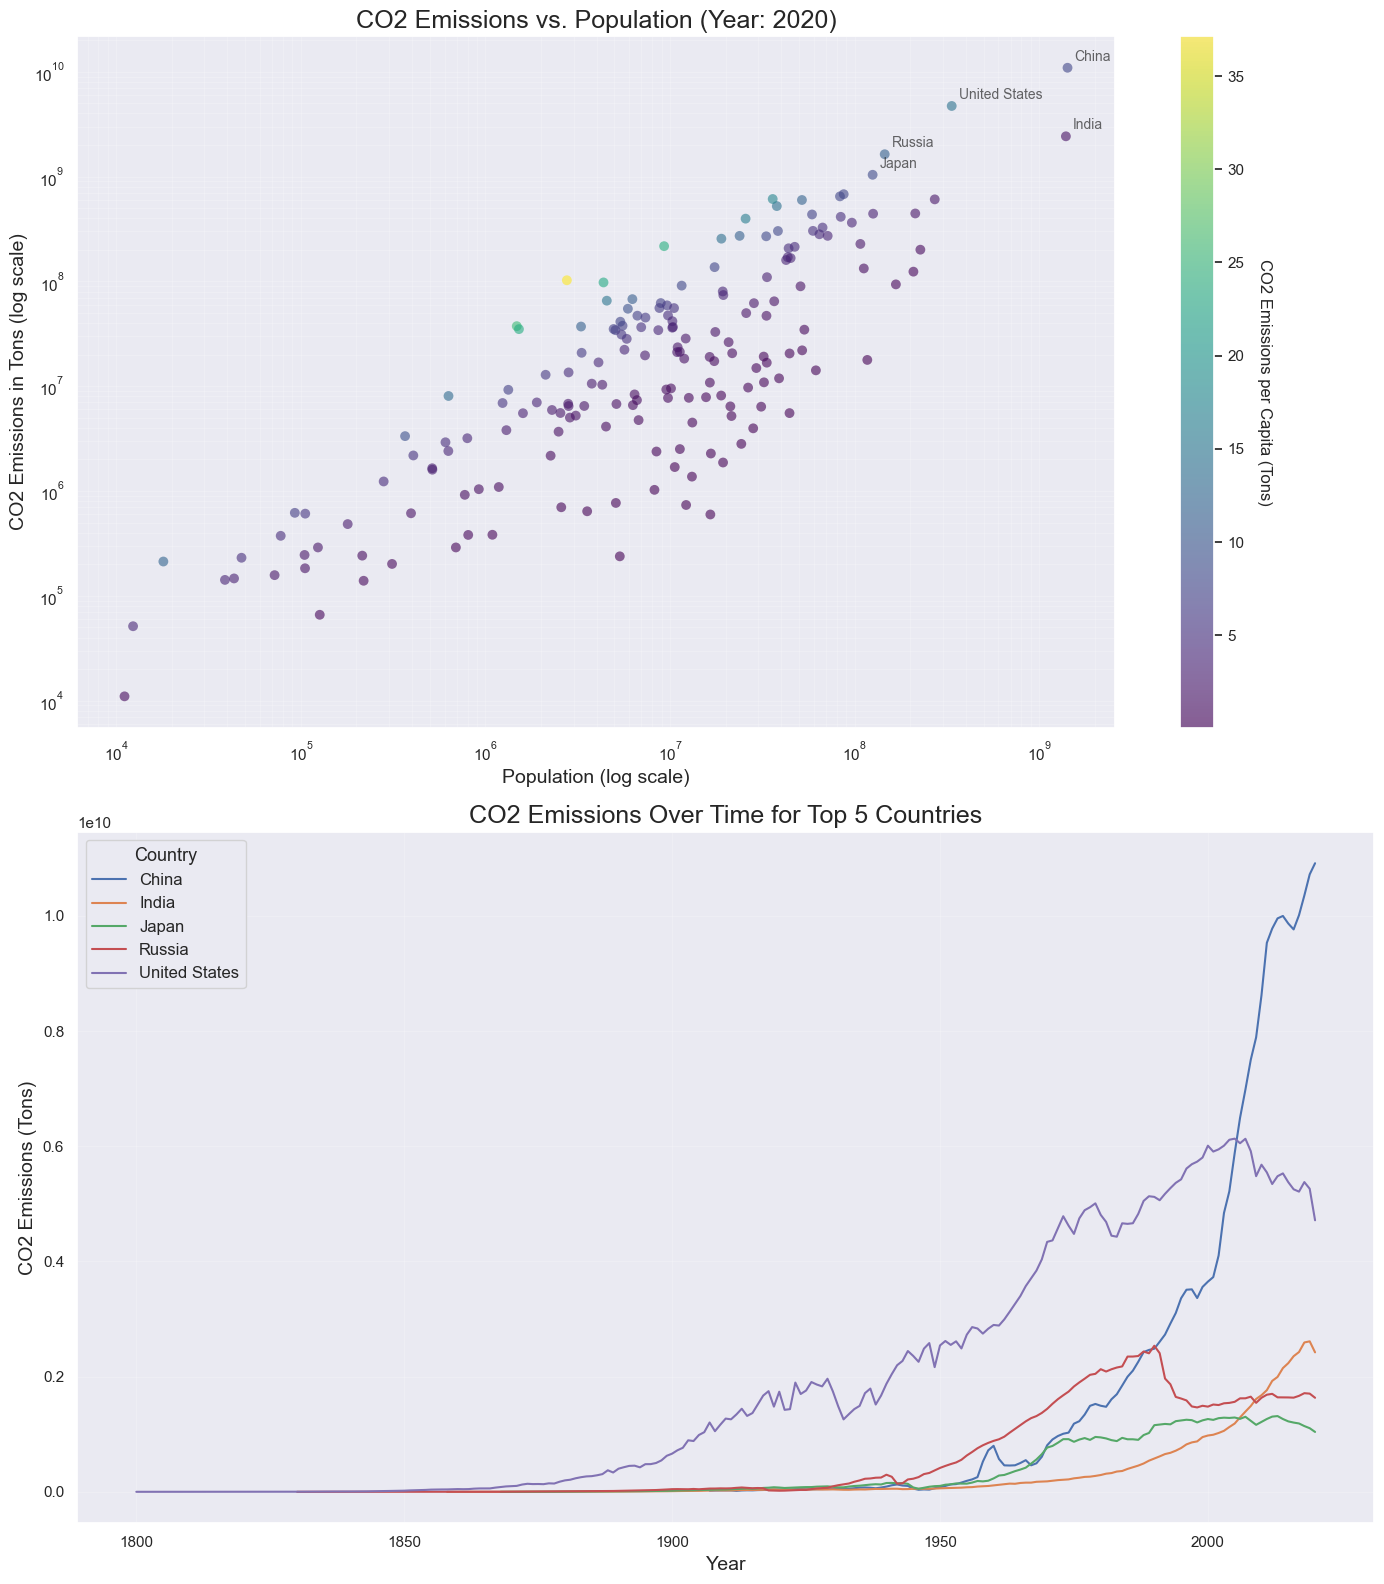

Statistics for the latest year (2020):

Top 5 countries by total CO2 emissions:
             Country  CO2 emission (Tons)  Developed
10839          China         1.091401e+10          0
57180  United States         4.714628e+09          1
24389          India         2.421552e+09          0
44443         Russia         1.632929e+09          0
26557          Japan         1.039796e+09          1

Top 5 countries by CO2 emissions per capita:
                    Country  Emissions_per_capita  Developed
43630                 Qatar             37.132947          0
4335                Bahrain             25.310819          0
56638  United Arab Emirates             23.340322          0
54470   Trinidad and Tobago             23.073961          0
28183                Kuwait             22.408821          0

Overall trends:
Year with highest total emissions: 2019 (35565346839.57 tons)
Year with lowest total emissions: 1803 (29538506.00 tons)


In [1541]:
# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 16))

# Scatter plot of the most recent year
latest_year = clean_data["Year"].max()
latest_data = clean_data[clean_data["Year"] == latest_year]

scatter = ax1.scatter(latest_data["Population"],
                      latest_data["CO2 emission (Tons)"],
                      c=latest_data["CO2 emission (Tons)"] / latest_data["Population"],
                      cmap="viridis",
                      alpha=0.6,
                      s=50,
                      edgecolors="none")

# Add colorbar to the scatter plot
cbar = fig.colorbar(scatter, ax=ax1)
cbar.set_label("CO2 Emissions per Capita (Tons)", rotation=270, labelpad=20, fontsize=12)

ax1.set_title(f"CO2 Emissions vs. Population (Year: {latest_year})", fontsize=18)
ax1.set_xlabel("Population (log scale)", fontsize=14)
ax1.set_ylabel("CO2 Emissions in Tons (log scale)", fontsize=14)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.grid(True, which="both", ls="-", alpha=0.2)

# Annotate some interesting points
top_countries = latest_data.nlargest(5, "CO2 emission (Tons)")["Country"].tolist()
for country in top_countries:
    row = latest_data[latest_data["Country"] == country].iloc[0]
    ax1.annotate(country,
                 (row['Population'], row['CO2 emission (Tons)']),
                 xytext=(5, 5),
                 textcoords="offset points",
                 fontsize=10,
                 alpha=0.7)

# Line plot for top 5 countries over time
top_5_countries = clean_data.groupby("Country")["CO2 emission (Tons)"].max().nlargest(5).index
sns.lineplot(
    data=clean_data[clean_data["Country"].isin(top_5_countries)],
    x="Year",
    y="CO2 emission (Tons)",
    hue="Country",
    ax=ax2,
)

ax2.set_title("CO2 Emissions Over Time for Top 5 Countries", fontsize=18)
ax2.set_xlabel("Year", fontsize=14)
ax2.set_ylabel("CO2 Emissions (Tons)", fontsize=14)
ax2.legend(title='Country', title_fontsize='13', fontsize='12')
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# Print some statistics
print(f"Statistics for the latest year ({latest_year}):")
print("\nTop 5 countries by total CO2 emissions:")
print(latest_data.nlargest(5, "CO2 emission (Tons)")[["Country", "CO2 emission (Tons)", "Developed"]])

print("\nTop 5 countries by CO2 emissions per capita:")
latest_data["Emissions_per_capita"] = latest_data["CO2 emission (Tons)"] / latest_data["Population"]
print(latest_data.nlargest(5, "Emissions_per_capita")[["Country", "Emissions_per_capita", "Developed"]])

# Overall trends
print("\nOverall trends:")
total_emissions = clean_data.groupby("Year")["CO2 emission (Tons)"].sum()
print(f"Year with highest total emissions: {total_emissions.idxmax()} ({total_emissions.max():.2f} tons)")
print(f"Year with lowest total emissions: {total_emissions.idxmin()} ({total_emissions.min():.2f} tons)")

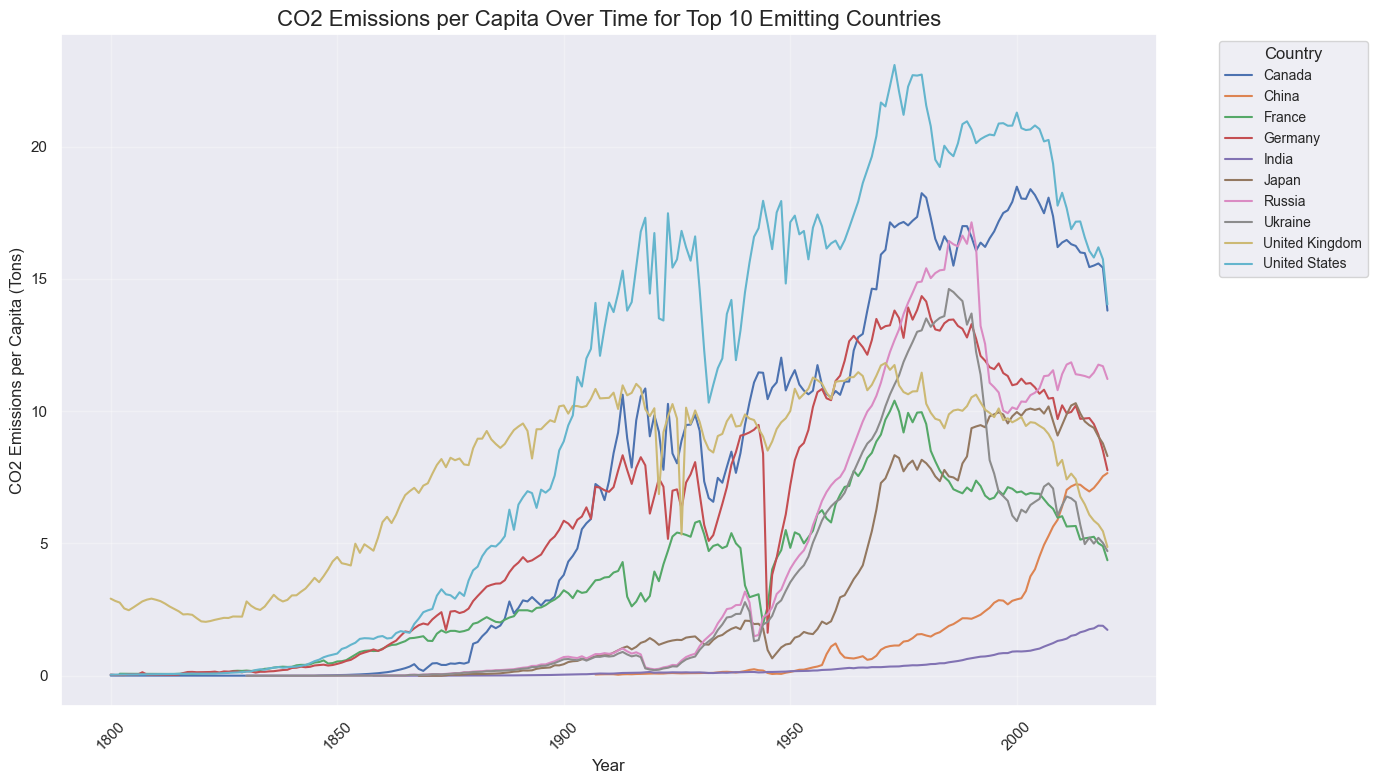

Emissions per Capita Statistics for Top 10 Emitting Countries:
                count       mean       std       min       25%        50%  \
Country                                                                     
Canada          221.0   7.112820  6.737201  0.001782  0.051966   7.115185   
China           114.0   1.705183  2.216200  0.039899  0.106566   0.715561   
France          213.0   3.737560  2.870517  0.067277  1.105736   3.164620   
Germany         221.0   5.858009  4.722743  0.028306  0.818397   5.858483   
India           152.0   0.369909  0.468399  0.001631  0.072915   0.143925   
Japan           153.0   3.771726  3.834579  0.000321  0.659503   1.574809   
Russia          169.0   5.121446  5.607246  0.000256  0.305399   1.978033   
Ukraine         169.0   3.923116  4.426522  0.000227  0.268462   1.728617   
United Kingdom  221.0   7.655918  3.126027  2.038749  4.725479   9.059344   
United States   221.0  10.232612  8.132429  0.042136  1.392543  11.993248   

            

In [1542]:
# Calculate emissions per capita
clean_data['Emissions_per_capita'] = clean_data['CO2 emission (Tons)'] / clean_data['Population']

# Get the top 10 countries by total emissions
top_10_countries = clean_data.groupby('Country')['CO2 emission (Tons)'].sum().nlargest(10).index

# Filter data for top 10 countries
top_10_data = clean_data[clean_data['Country'].isin(top_10_countries)]

# Create the line plot
plt.figure(figsize=(14, 8))
sns.lineplot(data=top_10_data, x='Year', y='Emissions_per_capita', hue='Country', ci=None)

plt.title('CO2 Emissions per Capita Over Time for Top 10 Emitting Countries', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('CO2 Emissions per Capita (Tons)', fontsize=12)
plt.grid(True, alpha=0.3)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Adjust legend
plt.legend(title='Country', title_fontsize='12', fontsize='10', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Print some statistics about the emissions per capita for top 10 countries
print("Emissions per Capita Statistics for Top 10 Emitting Countries:")
print(top_10_data.groupby('Country')['Emissions_per_capita'].describe())

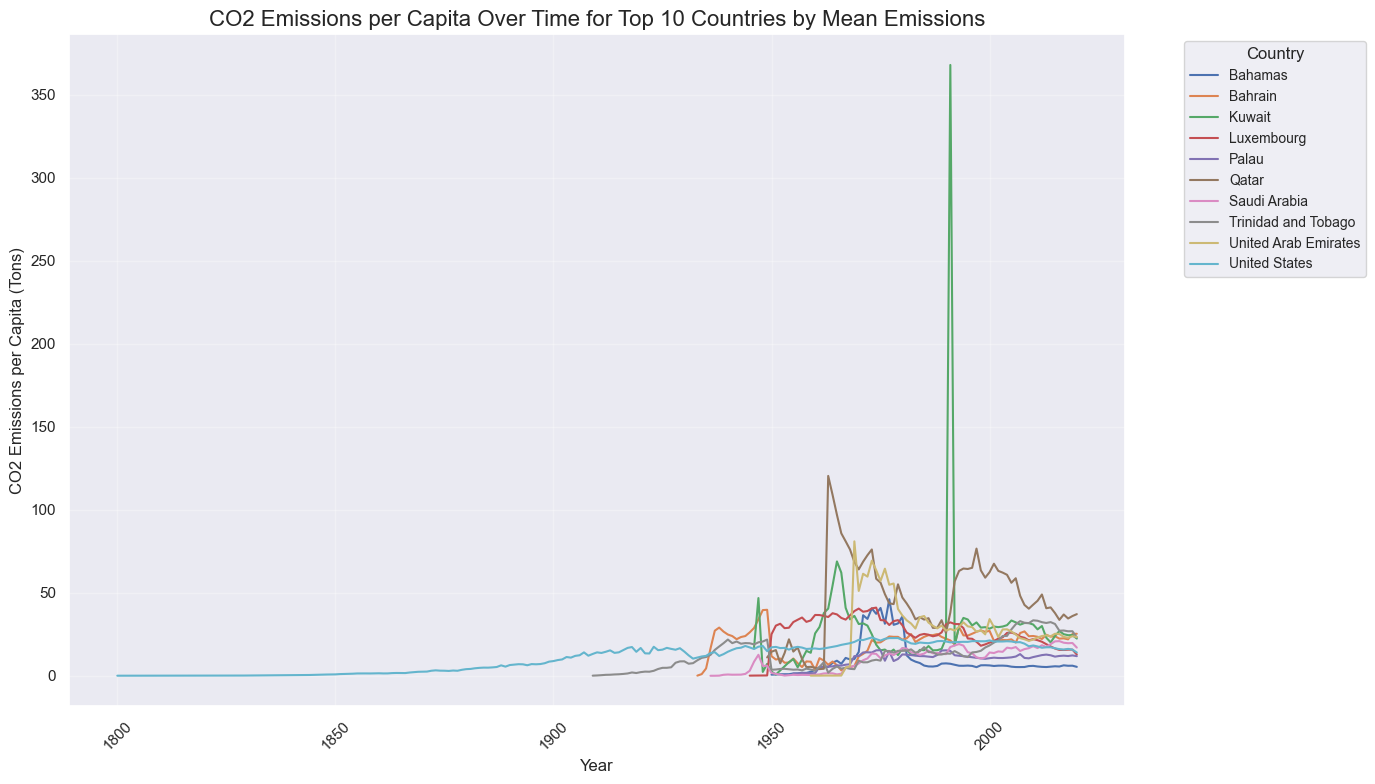

Emissions per Capita Statistics for Top 10 Countries by Mean Emissions:
                      count       mean        std       min        25%  \
Country                                                                  
Bahamas                71.0  10.117045  11.179918  0.673166   5.350927   
Bahrain                88.0  19.378769   8.579344  0.091749  11.379435   
Kuwait                 73.0  29.396695  42.084728  0.743186  15.592867   
Luxembourg             76.0  25.942287   9.879264  0.085404  21.229382   
Palau                  66.0  10.366118   3.723750  1.290747  10.148420   
Qatar                  72.0  45.939035  24.948096  4.019247  33.624143   
Saudi Arabia           83.0  10.085781   6.993824  0.002714   1.435110   
Trinidad and Tobago   112.0  12.914822   9.507510  0.077460   4.166462   
United Arab Emirates   62.0  28.953166  18.169747  0.077966  23.103998   
United States         221.0  10.232612   8.132429  0.042136   1.392543   

                            50%        

In [1543]:
# Get the top 10 countries by mean emissions per capita
top_10_countries = clean_data.groupby('Country')['Emissions_per_capita'].mean().nlargest(10).index

# Filter data for top 10 countries
top_10_data = clean_data[clean_data['Country'].isin(top_10_countries)]

# Create the line plot
plt.figure(figsize=(14, 8))
sns.lineplot(data=top_10_data, x='Year', y='Emissions_per_capita', hue='Country', ci=None)

plt.title('CO2 Emissions per Capita Over Time for Top 10 Countries by Mean Emissions', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('CO2 Emissions per Capita (Tons)', fontsize=12)
plt.grid(True, alpha=0.3)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Adjust legend
plt.legend(title='Country', title_fontsize='12', fontsize='10', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Print some statistics about the emissions per capita for top 10 countries
print("Emissions per Capita Statistics for Top 10 Countries by Mean Emissions:")
print(top_10_data.groupby('Country')['Emissions_per_capita'].describe())

### 1.4.3 Identifying Outliers


Summary statistics for Year:
count    18625
mean      1958
std         47
min       1800
25%       1932
50%       1969
75%       1995
max       2020
Name: Year, dtype: int64

Summary statistics for CO2 emission (Tons):
Count: 18625
Mean:  88.04M
Std:   449.41M
Min:   32.00 (Country: Armenia, Year: 1832)
25%:   542.27K (Country: Denmark, Year: 1860)
50%:   4.43M (Country: Georgia, Year: 1997)
75%:   31.78M (Country: Norway, Year: 1980)
Max:   10.91B (Country: China, Year: 2020)

Summary statistics for Population:
Count: 18625
Mean:  25.00M
Std:   93.56M
Min:   5.48K (Country: Nauru, Year: 1964)
25%:   1.91M (Country: Lesotho, Year: 1994)
50%:   5.22M (Country: Sweden, Year: 1903)
75%:   16.27M (Country: Spain, Year: 1871)
Max:   1.42B (Country: China, Year: 2020)

Summary statistics for Area:
Count: 18625
Mean:  980.03K
Std:   2.48M
Min:   21.00 (Country: Nauru, Year: 1964)
25%:   45.23K (Country: Estonia, Year: 1830)
50%:   199.95K (Country: Kyrgyzstan, Year: 1830)
75%:   603.50K (Cou

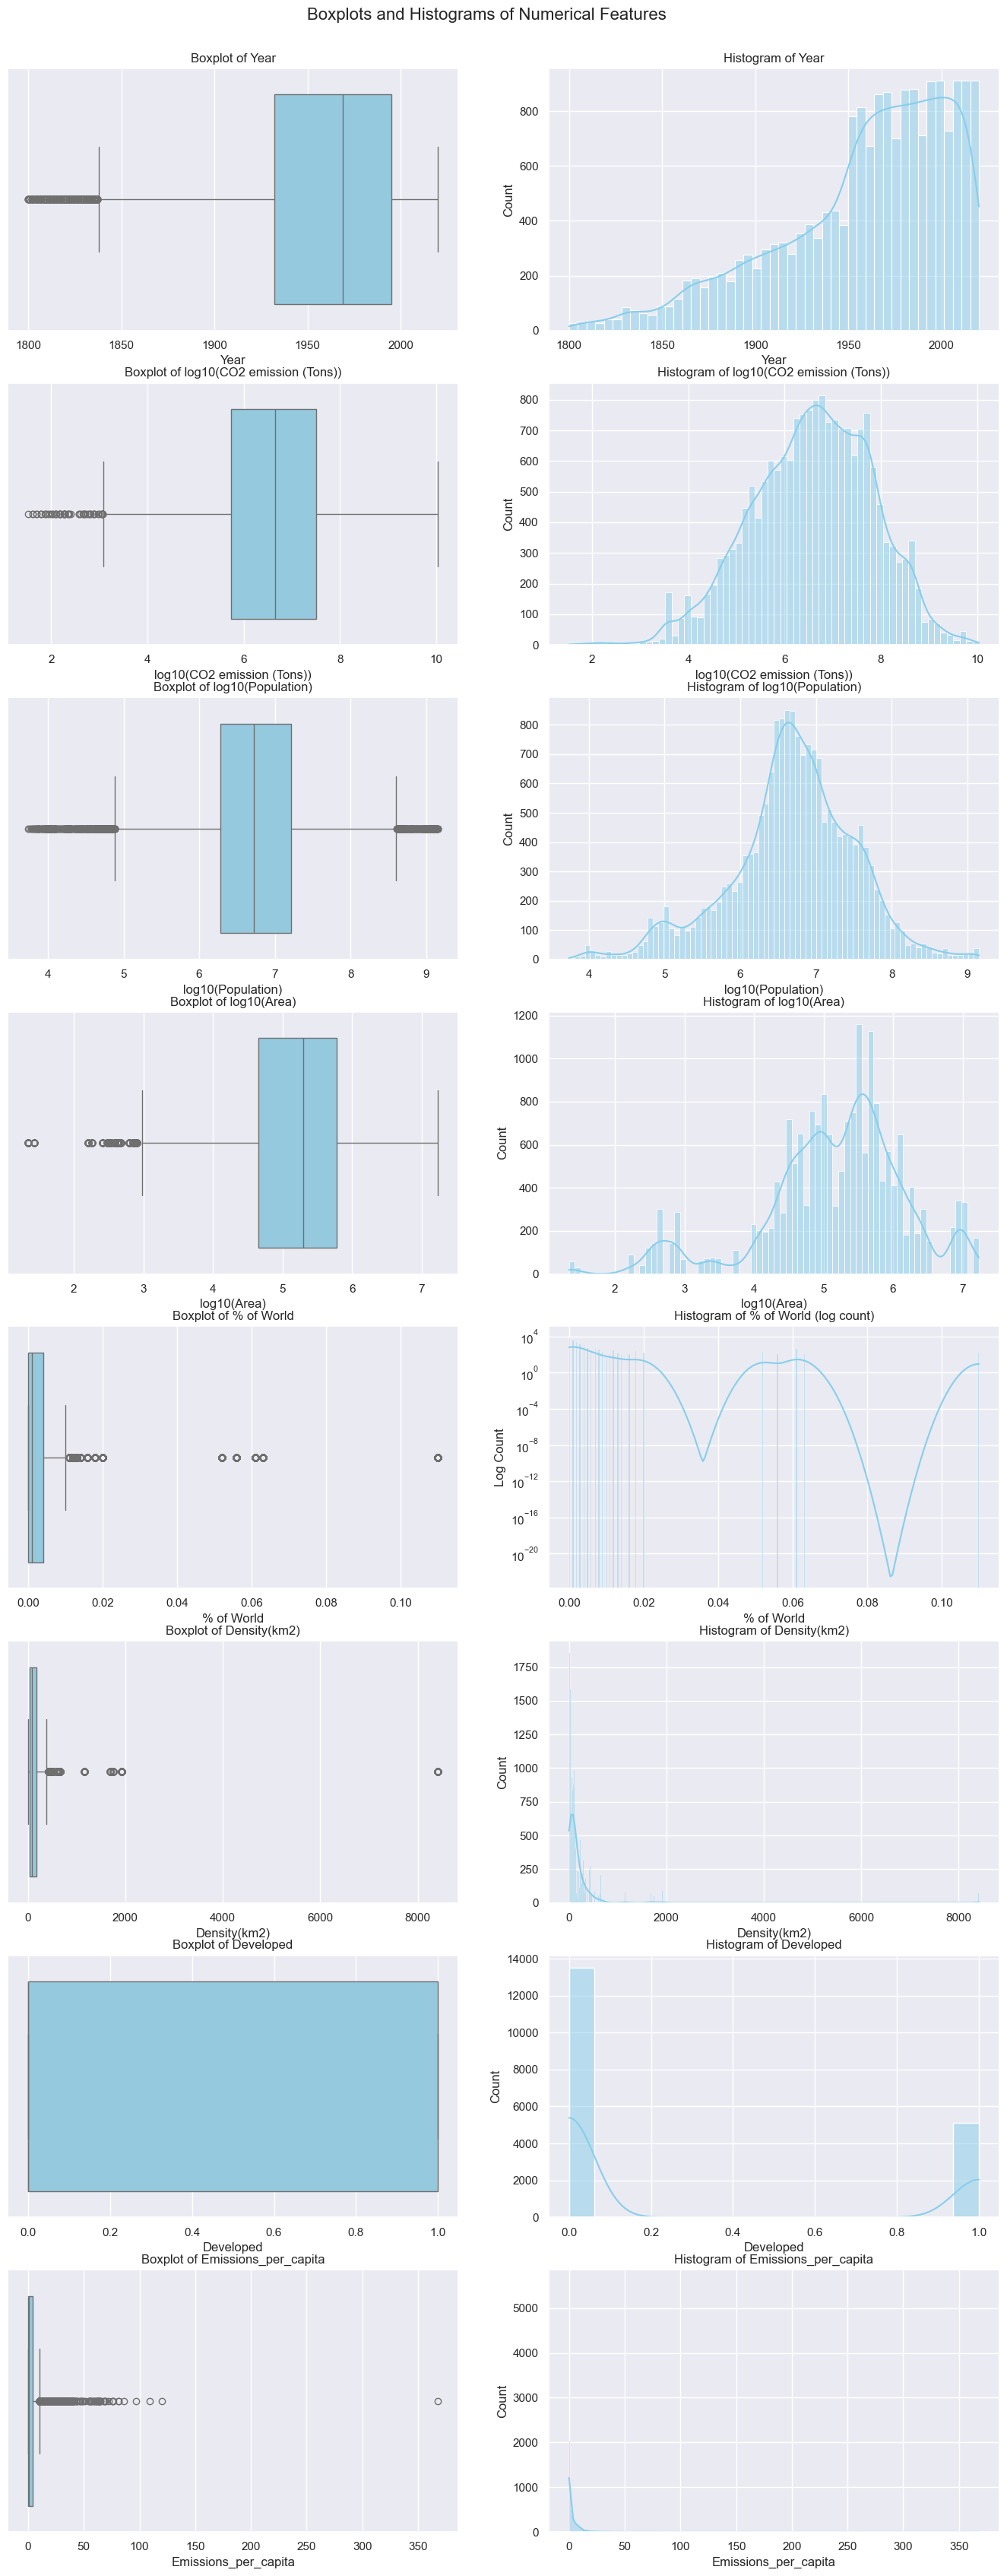

In [1544]:
def format_large_number(num) -> str:
    if num >= 1e9:
        return f"{num/1e9:.2f}B"
    elif num >= 1e6:
        return f"{num/1e6:.2f}M"
    elif num >= 1e3:
        return f"{num/1e3:.2f}K"
    else:
        return f"{num:.2f}"

def print_stats(column, data) -> None:
    stats = data[column].describe()

    def get_country_year(value):
        index = data[data[column] == value].index[0]
        return f"(Country: {data.loc[index, 'Country']}, Year: {data.loc[index, 'Year']})"

    print(f"\nSummary statistics for {column}:")
    print(f"Count: {stats['count']:.0f}")
    print(f"Mean:  {format_large_number(stats['mean'])}")
    print(f"Std:   {format_large_number(stats['std'])}")
    print(f"Min:   {format_large_number(stats['min'])} {get_country_year(stats['min'])}")
    print(f"25%:   {format_large_number(stats['25%'])} {get_country_year(stats['25%'])}")
    print(f"50%:   {format_large_number(stats['50%'])} {get_country_year(stats['50%'])}")
    print(f"75%:   {format_large_number(stats['75%'])} {get_country_year(stats['75%'])}")
    print(f"Max:   {format_large_number(stats['max'])} {get_country_year(stats['max'])}")

# Select numerical columns
numerical_columns = clean_data.select_dtypes(include=["int64", "float64"]).columns

# Calculate the number of rows and columns for the subplots
n_cols = 2
n_rows = len(numerical_columns)  # One row for each numerical column

# Set up the plot
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
fig.suptitle("Boxplots and Histograms of Numerical Features", fontsize=16, y=0.90)


# Create boxplots and histograms
for i, column in enumerate(numerical_columns):
    # Boxplot
    if column in ["CO2 emission (Tons)", "Population", "Area"]:
        sns.boxplot(x=np.log10(clean_data[column] + 1), ax=axes[i, 0], color="skyblue")
        axes[i, 0].set_title(f"Boxplot of log10({column})")
        axes[i, 0].set_xlabel(f"log10({column})")
    else:
        sns.boxplot(x=clean_data[column], ax=axes[i, 0], color="skyblue")
        axes[i, 0].set_title(f"Boxplot of {column}")
        axes[i, 0].set_xlabel(column)

    # Histogram
    if column in ["CO2 emission (Tons)", "Population", "Area"]:
        sns.histplot(data=clean_data, x=np.log10(clean_data[column] + 1), ax=axes[i, 1], kde=True, color="skyblue")
        axes[i, 1].set_title(f"Histogram of log10({column})")
        axes[i, 1].set_xlabel(f"log10({column})")
    elif column == "% of World":
        sns.histplot(data=clean_data, x=column, ax=axes[i, 1], kde=True, color="skyblue")
        axes[i, 1].set_yscale('log')  # Set y-axis to logarithmic scale
        axes[i, 1].set_title(f"Histogram of {column} (log count)")
        axes[i, 1].set_xlabel(column)
        axes[i, 1].set_ylabel("Log Count")
    else:
        sns.histplot(data=clean_data, x=column, ax=axes[i, 1], kde=True, color="skyblue")
        axes[i, 1].set_title(f"Histogram of {column}")
        axes[i, 1].set_xlabel(column)


# Print summary statistics
for column in numerical_columns:
    if column == "Year":
        print(f"\nSummary statistics for {column}:")
        print(clean_data[column].describe().round(0).astype(int))
    else:
        print_stats(column, clean_data)


# Print summary statistic for the emissions on the year 2020
year_2020_data = clean_data[clean_data["Year"] == 2020]
if not year_2020_data.empty:
    print("Emissions for 2020:")

    # Display overall statistics
    print(year_2020_data["CO2 emission (Tons)"].describe())

    # Display top 5 countries by emissions
    print("\nTop 5 countries by CO2 emissions in 2020:")
    top_5 = year_2020_data.nlargest(5, "CO2 emission (Tons)")
    print(top_5[["Country", "CO2 emission (Tons)"]])

    # Display bottom 5 countries by emissions
    print("\nBottom 5 countries by CO2 emissions in 2020:")
    bottom_5 = year_2020_data.nsmallest(5, "CO2 emission (Tons)")
    print(bottom_5[["Country", "CO2 emission (Tons)"]])
else:
    print("No data available for the year 2020")


### 1.4.4 Calculating Boxplots’ Min/Max-whisker limits

In [1545]:
def calculate_whisker_limits(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_whisker = Q1 - 1.5 * IQR
    upper_whisker = Q3 + 1.5 * IQR
    return lower_whisker, upper_whisker

# Select numerical columns
numerical_columns = clean_data.select_dtypes(include=["int64", "float64"]).columns

# Calculate and print whisker limits for each numerical column
for column in numerical_columns:
    if column in ["CO2 emission (Tons)", "Population", "Area"]:
        # For log-transformed data
        log_data = np.log10(clean_data[column] + 1)
        lower_whisker, upper_whisker = calculate_whisker_limits(log_data)
        print(f"\nWhisker limits for log10({column}):")
        print(f"Lower whisker: {10**lower_whisker:.2f}")
        print(f"Upper whisker: {10**upper_whisker:.2f}")
    else:
        # For non-transformed data
        lower_whisker, upper_whisker = calculate_whisker_limits(clean_data[column])
        print(f"\nWhisker limits for {column}:")
        print(f"Lower whisker: {lower_whisker:.2f}")
        print(f"Upper whisker: {upper_whisker:.2f}")

    # Calculate and print the number of outliers
    if column in ["CO2 emission (Tons)", "Population", "Area"]:
        log_data = np.log10(clean_data[column] + 1)
        outliers = log_data[(log_data < lower_whisker) | (log_data > upper_whisker)]
    else:
        outliers = clean_data[column][(clean_data[column] < lower_whisker) | (clean_data[column] > upper_whisker)]

    print(f"Number of outliers: {len(outliers)}")


Whisker limits for Year:
Lower whisker: 1837.50
Upper whisker: 2089.50
Number of outliers: 361

Whisker limits for log10(CO2 emission (Tons)):
Lower whisker: 1208.86
Upper whisker: 14254615333.83
Number of outliers: 64

Whisker limits for log10(Population):
Lower whisker: 76906.72
Upper whisker: 404146036.12
Number of outliers: 746

Whisker limits for log10(Area):
Lower whisker: 927.90
Upper whisker: 29416019.85
Number of outliers: 1214

Whisker limits for % of World:
Lower whisker: -0.01
Upper whisker: 0.01
Number of outliers: 2219

Whisker limits for Density(km2):
Lower whisker: -180.50
Upper whisker: 383.50
Number of outliers: 1615

Whisker limits for Developed:
Lower whisker: -1.50
Upper whisker: 2.50
Number of outliers: 0

Whisker limits for Emissions_per_capita:
Lower whisker: -5.75
Upper whisker: 10.12
Number of outliers: 1473


#### 1.4.4.1. Limiting Outliers

We will not be removing outliers from our data. This is due to the fact that there is a wide range of CO2 emissions per country, year and population. Removing outliers would mean that we are removing data that we believe is important.

### 1.4.5. Heatmaps to Visualize the Correlations between Features

###### 1.4.5.0.0.1 Adding world regions
We decided later on that including world regions would be a good way to see if there are any correlations between the regions. So we created a function that would assign a region to a country based on the country name. Looped it through several times and added the countries that where left in "Other" to the correct region. (Even if we are unable to do it when it comes to the heatmap)

In [1546]:
def assign_region(country):
    # North America (including Central America and Caribbean)
    if country in ['United States', 'Canada', 'Mexico', 'Antigua and Barbuda', 'Bahamas', 'Barbados', 'Belize', 'Costa Rica', 'Cuba', 'Dominica', 'Dominican Republic', 'El Salvador', 'Grenada', 'Guatemala', 'Haiti', 'Honduras', 'Jamaica', 'Nicaragua', 'Panama', 'Saint Kitts and Nevis', 'Saint Lucia', 'Saint Vincent and the Grenadines', 'Trinidad and Tobago']:
        return 'North America'

    # South America
    elif country in ['Brazil', 'Argentina', 'Colombia', 'Peru', 'Chile', 'Ecuador', 'Bolivia', 'Venezuela', 'Uruguay', 'Paraguay', 'Guyana', 'Suriname', 'French Guiana']:
        return 'South America'

    # Europe
    elif country in ['United Kingdom', 'France', 'Germany', 'Italy', 'Spain', 'Ukraine', 'Poland', 'Romania', 'Netherlands', 'Belgium', 'Greece', 'Czech Republic', 'Portugal', 'Sweden', 'Hungary', 'Belarus', 'Austria', 'Switzerland', 'Bulgaria', 'Denmark', 'Finland', 'Slovakia', 'Norway', 'Ireland', 'Croatia', 'Moldova', 'Bosnia and Herzegovina', 'Albania', 'Lithuania', 'North Macedonia', 'Slovenia', 'Latvia', 'Estonia', 'Montenegro', 'Luxembourg', 'Malta', 'Iceland', 'Andorra', 'Monaco', 'Liechtenstein', 'San Marino', 'Holy See', 'Serbia']:
        return 'Europe'

    # Asia
    elif country in ['China', 'India', 'Indonesia', 'Pakistan', 'Bangladesh', 'Japan', 'Philippines', 'Vietnam', 'Turkey', 'Iran', 'Thailand', 'Myanmar', 'South Korea', 'Iraq', 'Afghanistan', 'Saudi Arabia', 'Uzbekistan', 'Malaysia', 'Yemen', 'Nepal', 'North Korea', 'Sri Lanka', 'Kazakhstan', 'Syria', 'Cambodia', 'Jordan', 'Azerbaijan', 'United Arab Emirates', 'Tajikistan', 'Israel', 'Laos', 'Lebanon', 'Kyrgyzstan', 'Turkmenistan', 'Singapore', 'Oman', 'State of Palestine', 'Kuwait', 'Georgia', 'Mongolia', 'Armenia', 'Qatar', 'Bahrain', 'Timor-Leste', 'Cyprus', 'Bhutan', 'Maldives', 'Brunei', 'Taiwan']:
        return 'Asia'

    # Africa
    elif country in ['Nigeria', 'Ethiopia', 'Egypt', 'Democratic Republic of the Congo', 'Tanzania', 'South Africa', 'Kenya', 'Uganda', 'Algeria', 'Sudan', 'Morocco', 'Angola', 'Mozambique', 'Ghana', 'Madagascar', 'Cameroon', "Côte d'Ivoire", 'Niger', 'Burkina Faso', 'Mali', 'Malawi', 'Zambia', 'Senegal', 'Chad', 'Somalia', 'Zimbabwe', 'Guinea', 'Rwanda', 'Benin', 'Burundi', 'Tunisia', 'South Sudan', 'Togo', 'Sierra Leone', 'Libya', 'Congo', 'Liberia', 'Central African Republic', 'Mauritania', 'Eritrea', 'Namibia', 'Gambia', 'Botswana', 'Gabon', 'Lesotho', 'Guinea-Bissau', 'Equatorial Guinea', 'Mauritius', 'Eswatini', 'Djibouti', 'Comoros', 'Cabo Verde', 'Sao Tome and Principe', 'Seychelles']:
        return 'Africa'

    # Oceania
    elif country in ['Australia', 'Papua New Guinea', 'New Zealand', 'Fiji', 'Solomon Islands', 'Vanuatu', 'New Caledonia', 'French Polynesia', 'Samoa', 'Guam', 'Kiribati', 'Micronesia', 'Tonga', 'Marshall Islands', 'Palau', 'Tuvalu', 'Nauru']:
        return 'Oceania'

    # 75% of Russia belongs to Asia (https://www.worldometers.info/geography/7-continents/#:~:text=About%2075%25%20of%20the%20Russian,territory%20is%20located%20in%20Asia).
    elif country == 'Russia':
        return 'Asia'

    # 97% of Turkey belongs to Asia (https://en.wikipedia.org/wiki/Geography_of_Turkey).
    elif country == 'Turkey':
        return 'Asia'

    else:
        return 'Other'

# Create a copy of the clean_data DataFrame
data_with_regions = clean_data.copy()

# Apply the function to create a new 'Region' column
data_with_regions['Region'] = data_with_regions['Country'].apply(assign_region)

# Display the first few rows to verify
print(data_with_regions[['Country', 'Region']].head(10))

# Count the number of countries in each region
region_counts = data_with_regions['Region'].value_counts()
print("\nNumber of countries in each region:")
print(region_counts)

# Check for countries mapped as 'Other'
other_countries = data_with_regions[data_with_regions['Region'] == 'Other']['Country'].unique()
print("\nCountries mapped as 'Other':")
print(other_countries)

# Add the regions to the data
clean_data['Region'] = data_with_regions['Region']


         Country Region
199  Afghanistan   Asia
200  Afghanistan   Asia
201  Afghanistan   Asia
202  Afghanistan   Asia
203  Afghanistan   Asia
204  Afghanistan   Asia
205  Afghanistan   Asia
206  Afghanistan   Asia
207  Afghanistan   Asia
208  Afghanistan   Asia

Number of countries in each region:
Region
Europe           5775
Asia             4980
Africa           3595
North America    2035
South America    1226
Oceania          1014
Name: count, dtype: int64

Countries mapped as 'Other':
[]


##### 1.4.5.0.1 All data

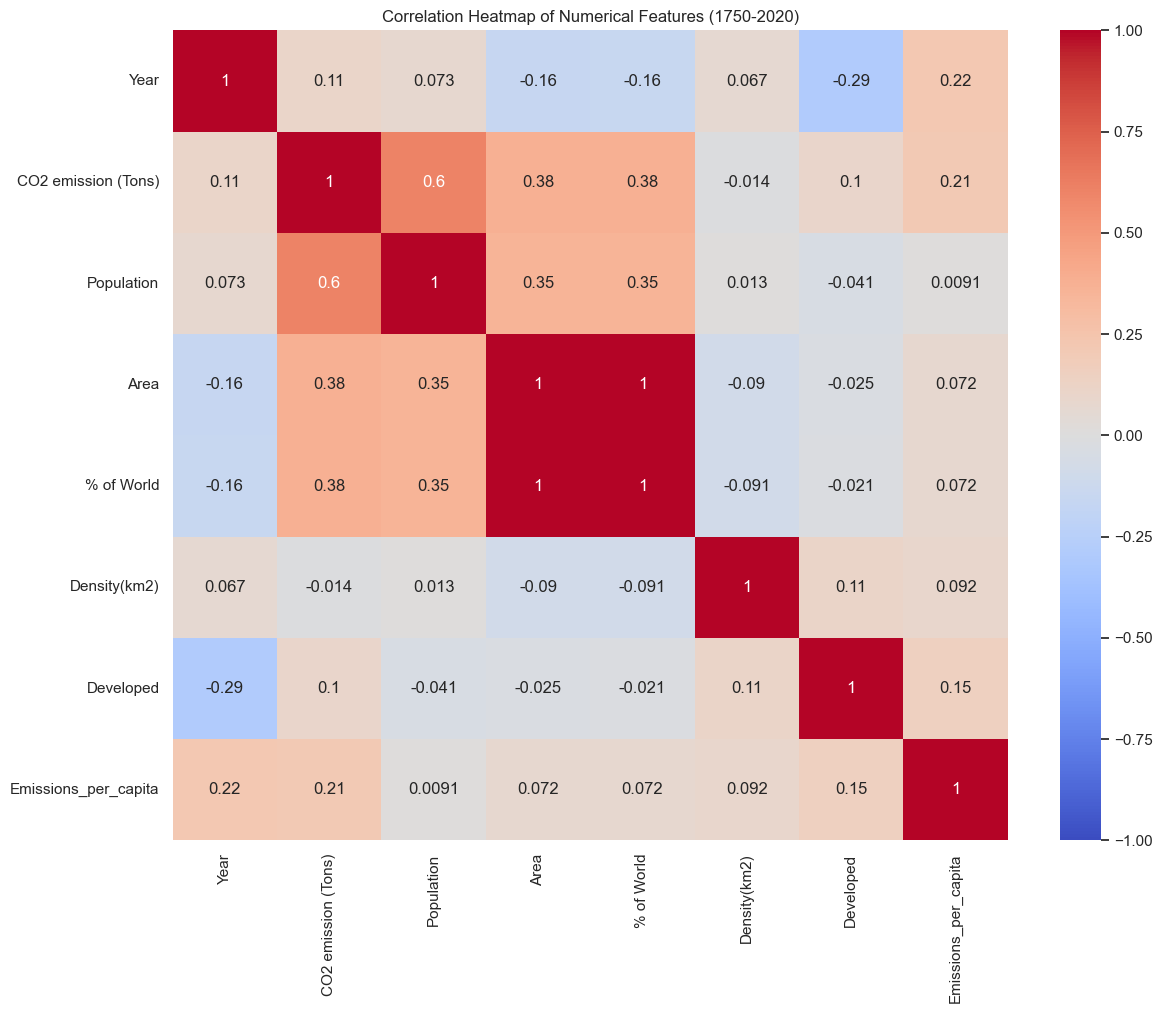

                          Year  CO2 emission (Tons)  Population      Area  \
Year                  1.000000             0.106785    0.072661 -0.156413   
CO2 emission (Tons)   0.106785             1.000000    0.602294  0.376889   
Population            0.072661             0.602294    1.000000  0.354390   
Area                 -0.156413             0.376889    0.354390  1.000000   
% of World           -0.155712             0.378902    0.353187  0.999405   
Density(km2)          0.067056            -0.014249    0.013206 -0.090024   
Developed            -0.294813             0.100877   -0.040952 -0.024604   
Emissions_per_capita  0.220732             0.214847    0.009121  0.071741   

                      % of World  Density(km2)  Developed  \
Year                   -0.155712      0.067056  -0.294813   
CO2 emission (Tons)     0.378902     -0.014249   0.100877   
Population              0.353187      0.013206  -0.040952   
Area                    0.999405     -0.090024  -0.024604   
%

In [1547]:
# Select numerical columns
numerical_columns = clean_data.select_dtypes(include=["int64", "float64"]).columns

# Calculate the correlation matrix
correlation_matrix = clean_data[numerical_columns].corr()

# Set up the matplotlib figure
plt.figure(figsize=(12, 10))

# Create a heatmap
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, center=0)

# Set the title
plt.title("Correlation Heatmap of Numerical Features (1750-2020)")

# Show the plot
plt.show()

# Print the correlation matrix
print(correlation_matrix)

##### 1.4.5.0.2 Trying to split Developed and Developing countries

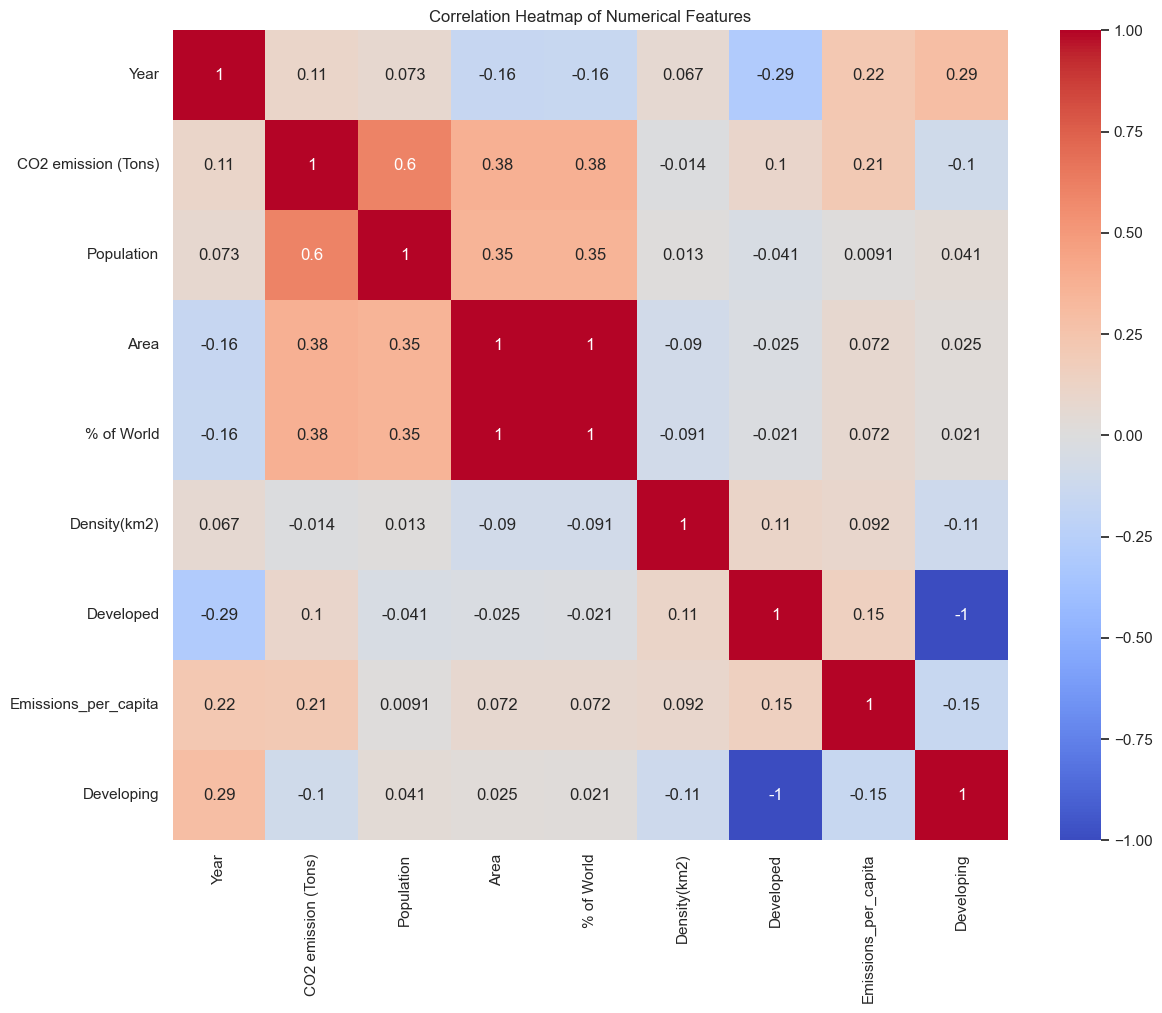

                          Year  CO2 emission (Tons)  Population      Area  \
Year                  1.000000             0.106785    0.072661 -0.156413   
CO2 emission (Tons)   0.106785             1.000000    0.602294  0.376889   
Population            0.072661             0.602294    1.000000  0.354390   
Area                 -0.156413             0.376889    0.354390  1.000000   
% of World           -0.155712             0.378902    0.353187  0.999405   
Density(km2)          0.067056            -0.014249    0.013206 -0.090024   
Developed            -0.294813             0.100877   -0.040952 -0.024604   
Emissions_per_capita  0.220732             0.214847    0.009121  0.071741   
Developing            0.294813            -0.100877    0.040952  0.024604   

                      % of World  Density(km2)  Developed  \
Year                   -0.155712      0.067056  -0.294813   
CO2 emission (Tons)     0.378902     -0.014249   0.100877   
Population              0.353187      0.013206

In [1548]:
# Create a copy of the dataset
heatmap_data = clean_data.copy()

# Create 'Developing' and 'Developed' columns based on the original 'Developed' column
heatmap_data['Developing'] = (heatmap_data['Developed'] == 0).astype(int)
heatmap_data['Developed'] = (heatmap_data['Developed'] == 1).astype(int)


# Select numerical columns
numerical_columns = heatmap_data.select_dtypes(include=["int64", "float64"]).columns

# Calculate the correlation matrix
correlation_matrix = heatmap_data[numerical_columns].corr()

# Set up the matplotlib figure
plt.figure(figsize=(12, 10))

# Create a heatmap
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, center=0)

# Set the title
plt.title("Correlation Heatmap of Numerical Features")

# Show the plot
plt.show()

# Print the correlation matrix
print(correlation_matrix)

##### 1.4.5.0.3 1970-2020

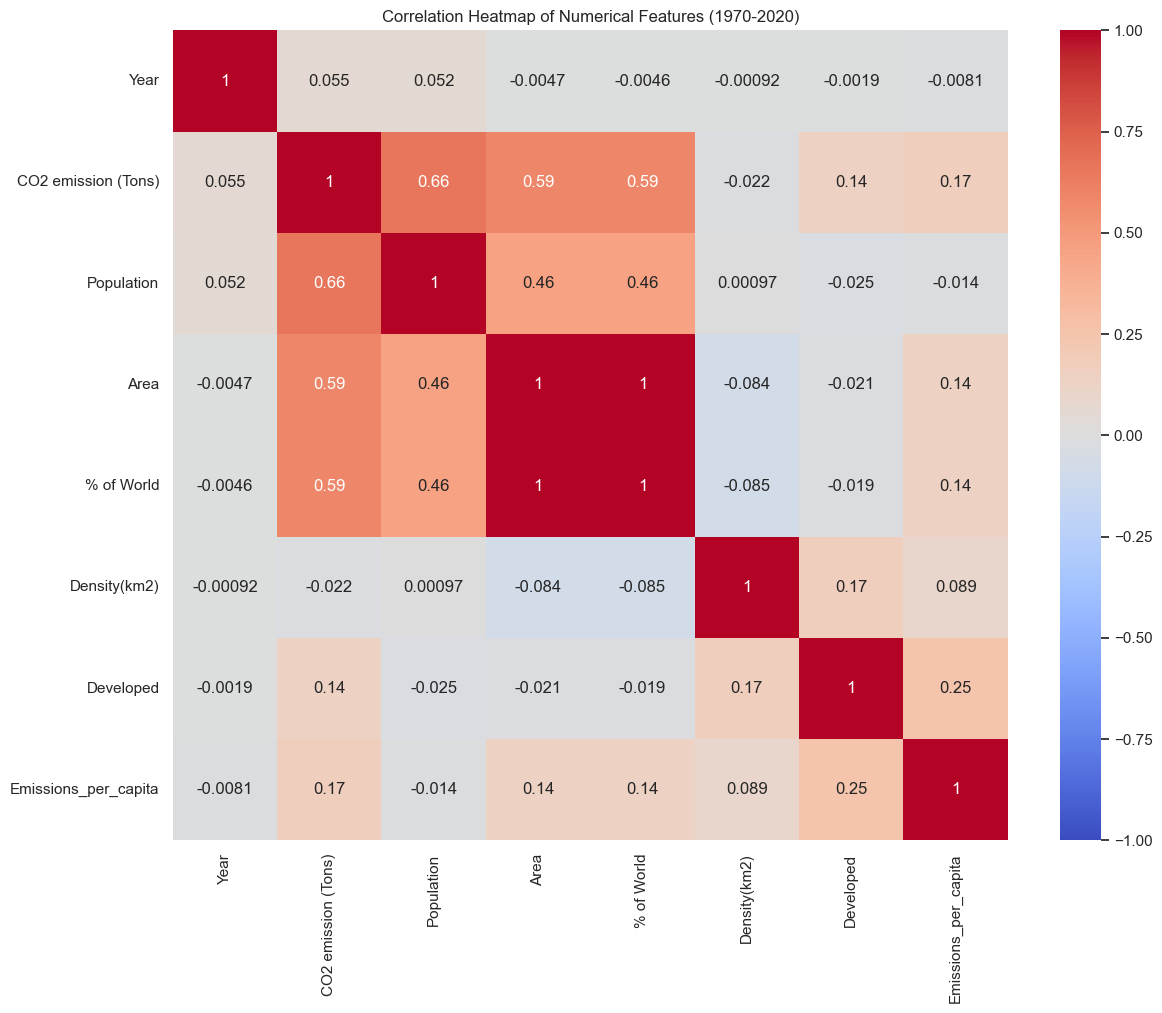

                          Year  CO2 emission (Tons)  Population      Area  \
Year                  1.000000             0.054755    0.052057 -0.004701   
CO2 emission (Tons)   0.054755             1.000000    0.658458  0.589908   
Population            0.052057             0.658458    1.000000  0.459272   
Area                 -0.004701             0.589908    0.459272  1.000000   
% of World           -0.004558             0.591261    0.456907  0.999419   
Density(km2)         -0.000924            -0.022012    0.000966 -0.083549   
Developed            -0.001892             0.137810   -0.025453 -0.020953   
Emissions_per_capita -0.008055             0.170536   -0.014273  0.136231   

                      % of World  Density(km2)  Developed  \
Year                   -0.004558     -0.000924  -0.001892   
CO2 emission (Tons)     0.591261     -0.022012   0.137810   
Population              0.456907      0.000966  -0.025453   
Area                    0.999419     -0.083549  -0.020953   
%

In [1549]:
# Filter the data for years 1970 to 2020
filtered_data = clean_data[(clean_data["Year"] >= 1970) & (clean_data["Year"] <= 2020)]

# Select numerical columns
numerical_columns = filtered_data.select_dtypes(include=["int64", "float64"]).columns

# Calculate the correlation matrix
correlation_matrix = filtered_data[numerical_columns].corr()

# Set up the matplotlib figure
plt.figure(figsize=(12, 10))

# Create a heatmap
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, center=0)

# Set the title
plt.title("Correlation Heatmap of Numerical Features (1970-2020)")

# Show the plot
plt.show()

# Print the correlation matrix
print(correlation_matrix)

##### 1.4.5.0.4 2000-2020

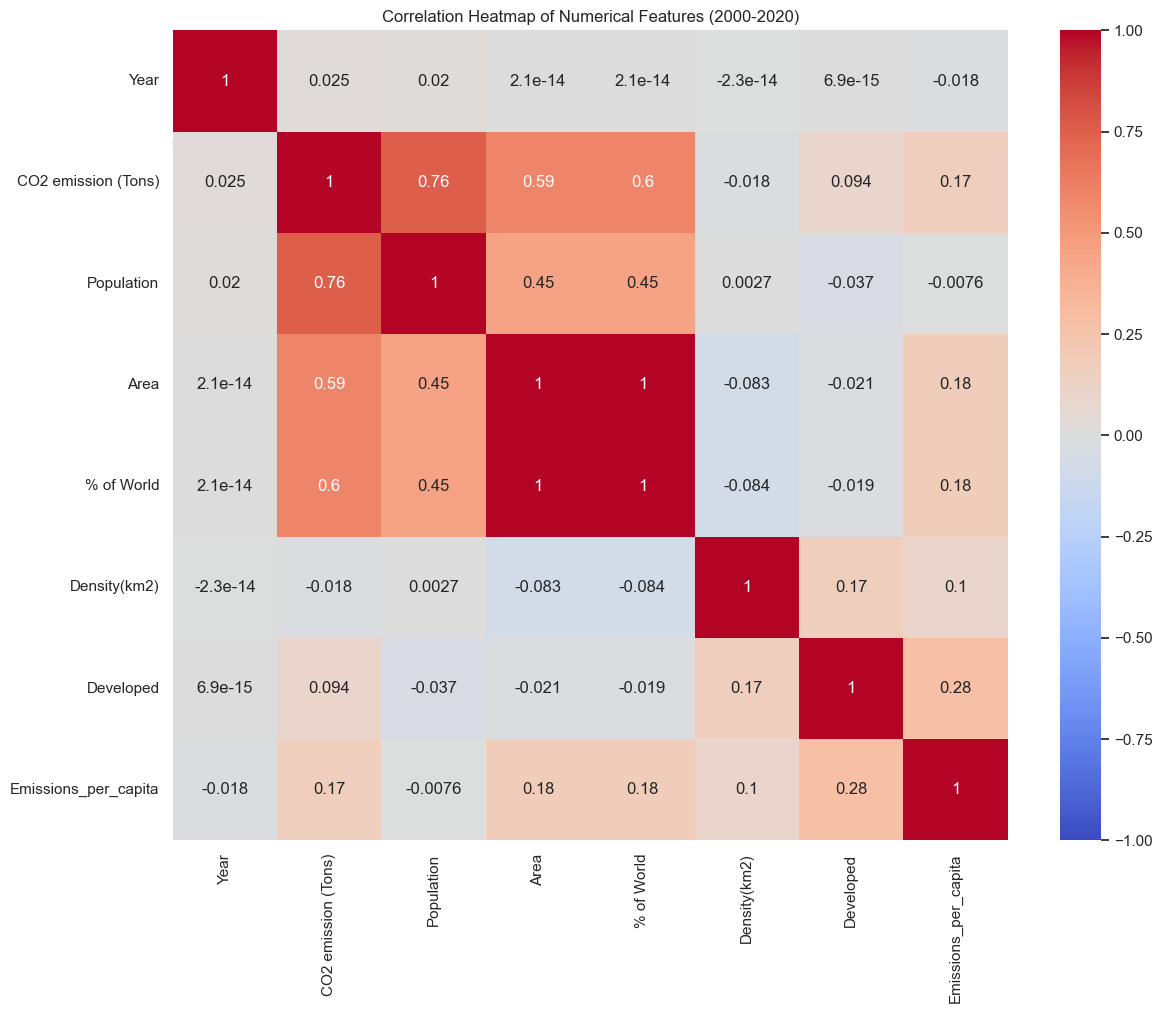

                              Year  CO2 emission (Tons)  Population  \
Year                  1.000000e+00             0.024529    0.019675   
CO2 emission (Tons)   2.452851e-02             1.000000    0.755601   
Population            1.967524e-02             0.755601    1.000000   
Area                  2.053330e-14             0.594218    0.452966   
% of World            2.069883e-14             0.595652    0.450196   
Density(km2)         -2.280338e-14            -0.018132    0.002691   
Developed             6.945155e-15             0.094061   -0.036903   
Emissions_per_capita -1.764706e-02             0.169585   -0.007623   

                              Area    % of World  Density(km2)     Developed  \
Year                  2.053330e-14  2.069883e-14 -2.280338e-14  6.945155e-15   
CO2 emission (Tons)   5.942185e-01  5.956518e-01 -1.813169e-02  9.406119e-02   
Population            4.529655e-01  4.501961e-01  2.691382e-03 -3.690293e-02   
Area                  1.000000e+00  9.99

In [1550]:
# Filter the data for years 2000 to 2020
filtered_data = clean_data[(clean_data["Year"] >= 2000) & (clean_data["Year"] <= 2020)]

# Select numerical columns
numerical_columns = filtered_data.select_dtypes(include=["int64", "float64"]).columns

# Calculate the correlation matrix
correlation_matrix = filtered_data[numerical_columns].corr()

# Set up the matplotlib figure
plt.figure(figsize=(12, 10))

# Create a heatmap
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, center=0)

# Set the title
plt.title("Correlation Heatmap of Numerical Features (2000-2020)")

# Show the plot
plt.show()

# Print the correlation matrix
print(correlation_matrix)

#### 1.4.5.1 Obvious correlations
- A country with a high population and high CO2 emissions has high correlation.
- An obvious thing is that the area and % of the world has a high correlation with each other.
- Larger countries when it comes to **population**, tend to have more CO2 emissions.
  
#### 1.4.5.2 Less obvious correlations that gives a new insight
- We earlier observed that 4 out of the top 5 polluters in 2020 where from Asia. Among these where China, India, Japan and Russia.
- We came to the realization that Developed vs Developing countries does not play a big role in the amount of CO2 emissions. At least on the data as a whole and on the data we have.
- Larger countries when it comes to **land area**, tend to have more CO2 emissions.
- Emissions per capita has a weak correlation with Developed countries.

#### 1.4.5.3 Important correlation with the target value
- Our target value is CO2 emissions per capita.

### 1.4.6. Scatterplots of Selected Features

#### 1.4.6.1 2020

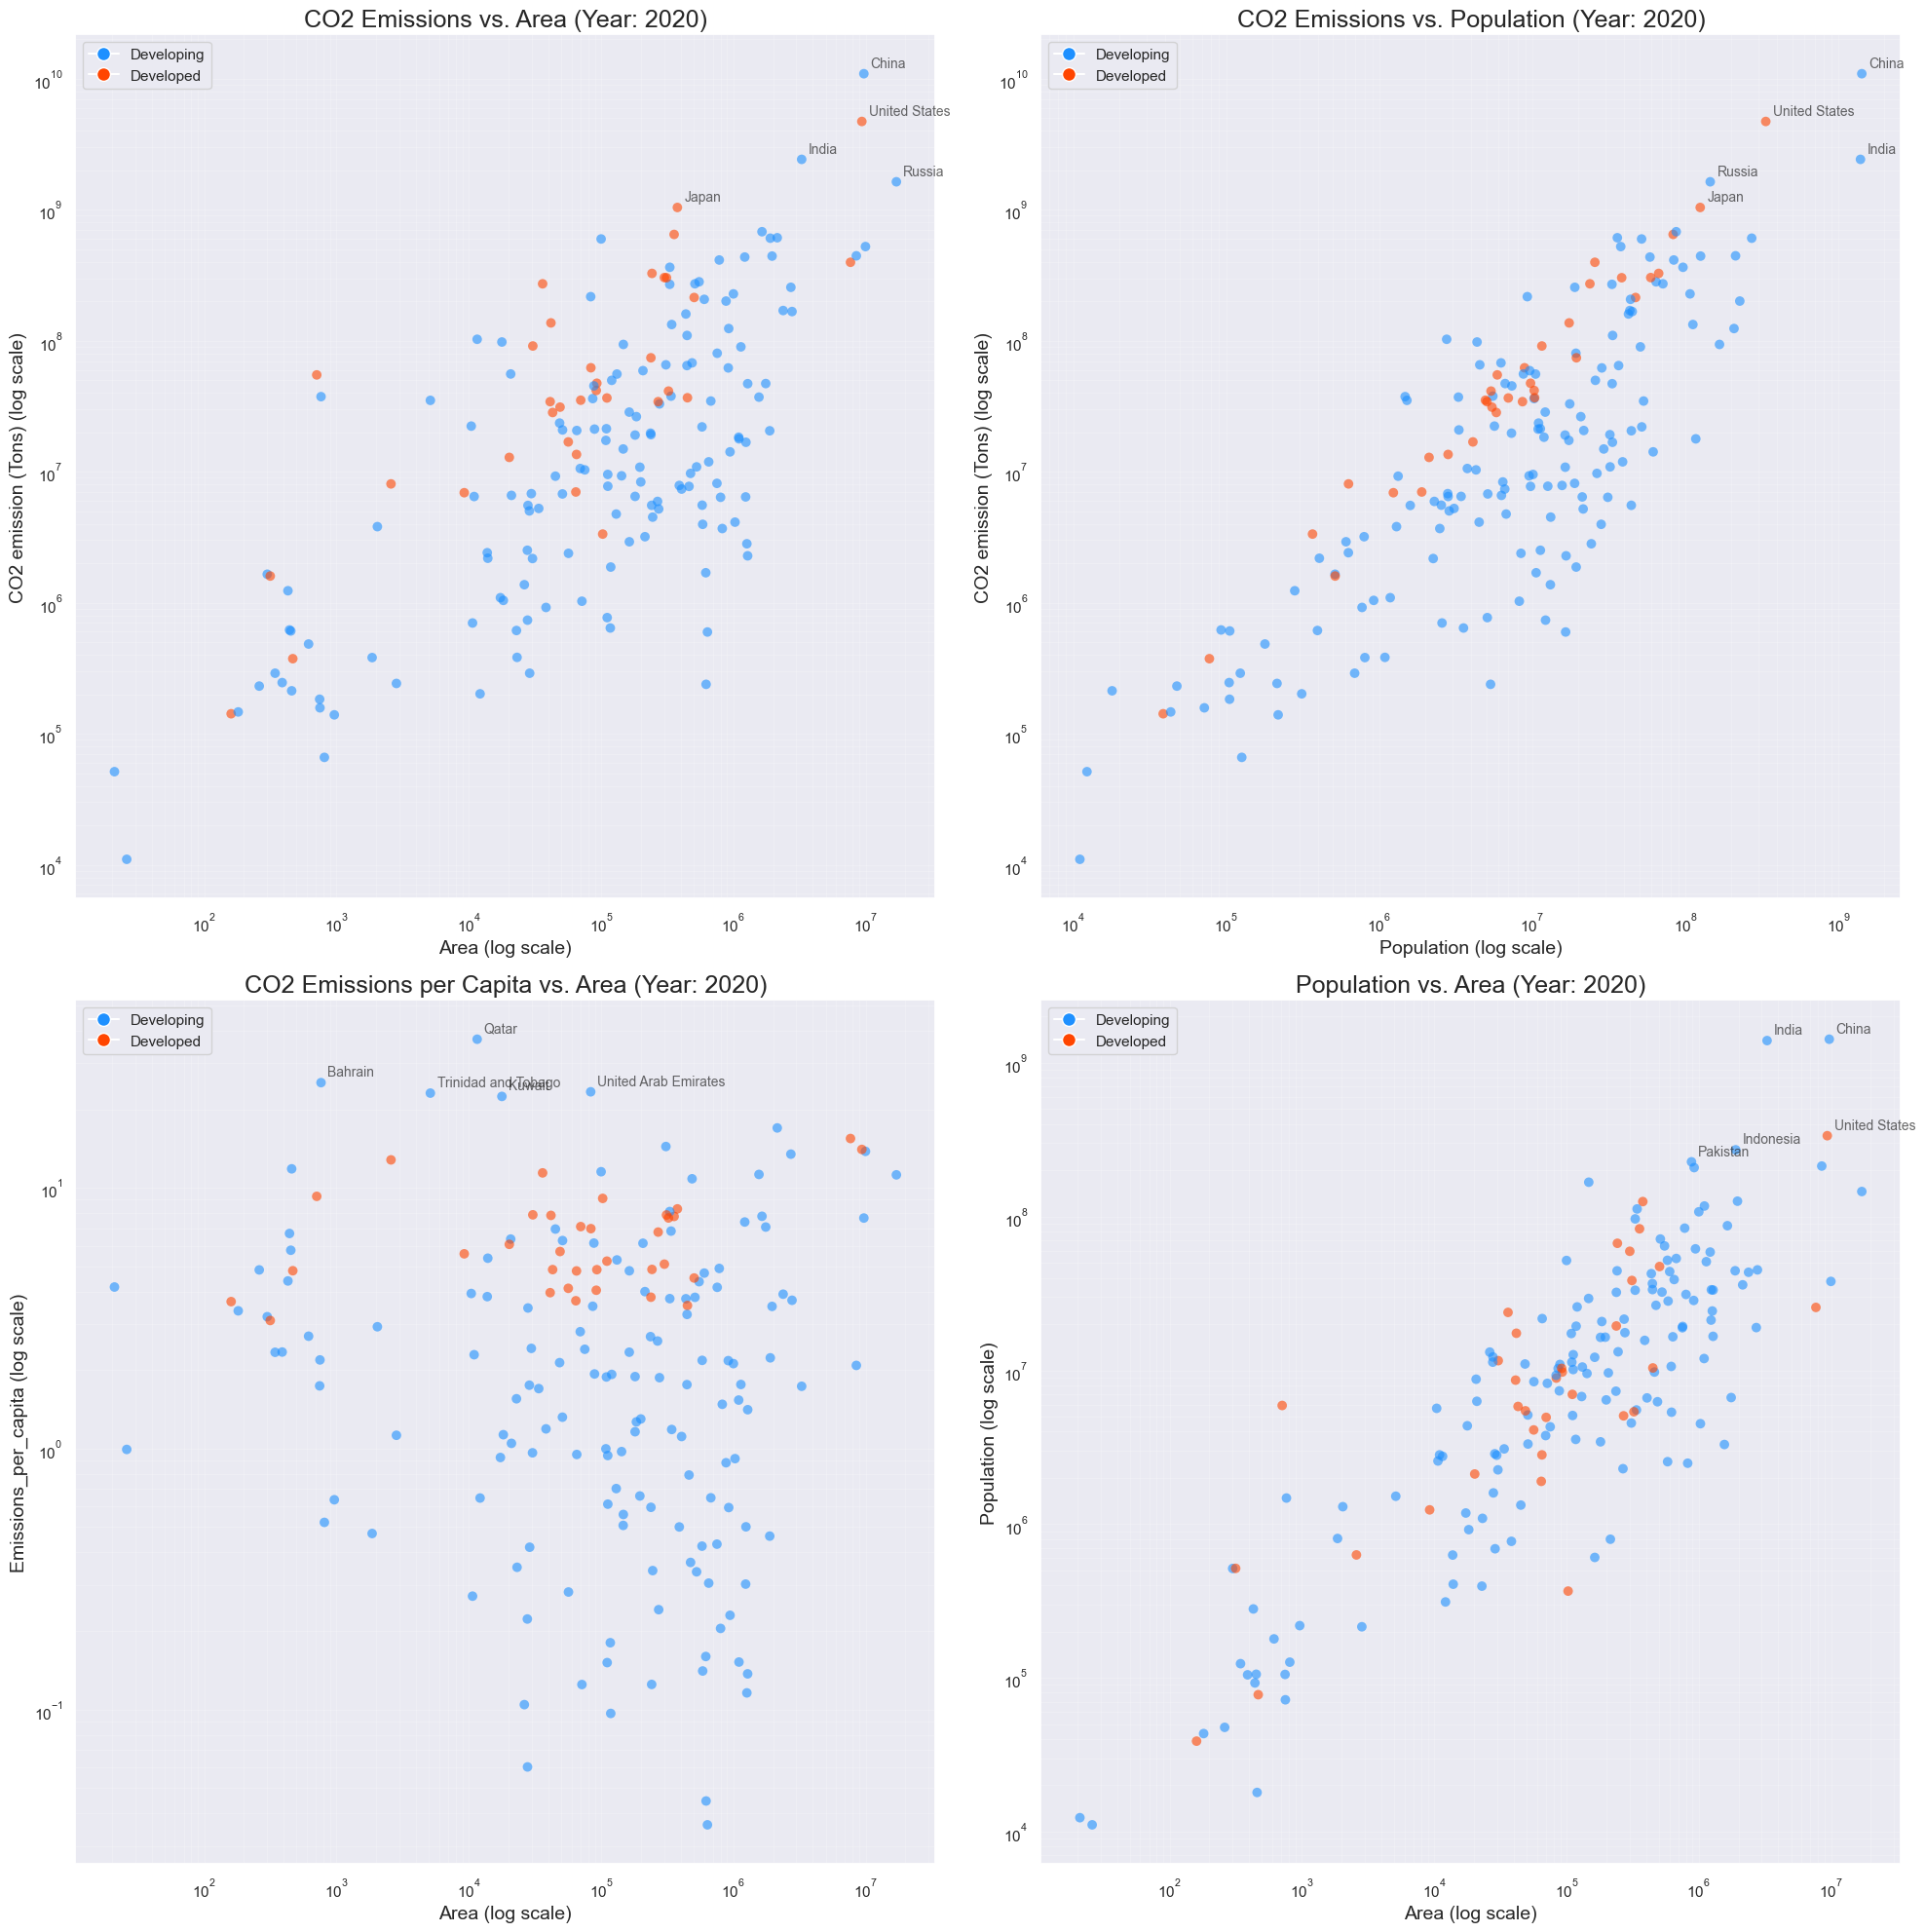

In [1551]:
# Create a figure with four subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 20))

# Get the most recent year
latest_year = clean_data["Year"].max()
latest_data = clean_data[clean_data["Year"] == latest_year]

# Create a color map based on the 'Developed' column
colors = ['#1E90FF' if dev == 0 else '#FF4500' for dev in latest_data["Developed"]]

# Function to create scatter plot
def create_scatter(ax, x, y, title):
    scatter = ax.scatter(latest_data[x],
                         latest_data[y],
                         c=colors,
                         alpha=0.6,
                         s=50,
                         edgecolors="none")
    ax.set_title(title, fontsize=18)
    ax.set_xlabel(f"{x} (log scale)", fontsize=14)
    ax.set_ylabel(f"{y} (log scale)", fontsize=14)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True, which="both", ls="-", alpha=0.2)

    # Add a legend
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w', label='Developing', # type: ignore
                                  markerfacecolor='#1E90FF', markersize=10),
                       plt.Line2D([0], [0], marker='o', color='w', label='Developed', # type: ignore
                                  markerfacecolor='#FF4500', markersize=10)]
    ax.legend(handles=legend_elements, loc='upper left')

    # Annotate top 5 countries
    top_countries = latest_data.nlargest(5, y)["Country"].tolist()
    for country in top_countries:
        row = latest_data[latest_data["Country"] == country].iloc[0]
        ax.annotate(country,
                    (row[x], row[y]),
                    xytext=(5, 5),
                    textcoords="offset points",
                    fontsize=10,
                    alpha=0.7)

# Calculate emissions per capita
latest_data["Emissions_per_capita"] = latest_data["CO2 emission (Tons)"] / latest_data["Population"]

# Create the four scatter plots
create_scatter(ax1, "Area", "CO2 emission (Tons)", f"CO2 Emissions vs. Area (Year: {latest_year})")
create_scatter(ax2, "Population", "CO2 emission (Tons)", f"CO2 Emissions vs. Population (Year: {latest_year})")
create_scatter(ax3, "Area", "Emissions_per_capita", f"CO2 Emissions per Capita vs. Area (Year: {latest_year})")
create_scatter(ax4, "Area", "Population", f"Population vs. Area (Year: {latest_year})")

plt.tight_layout()
plt.show()


##### 1.4.6.1.1 Emission by region 2020

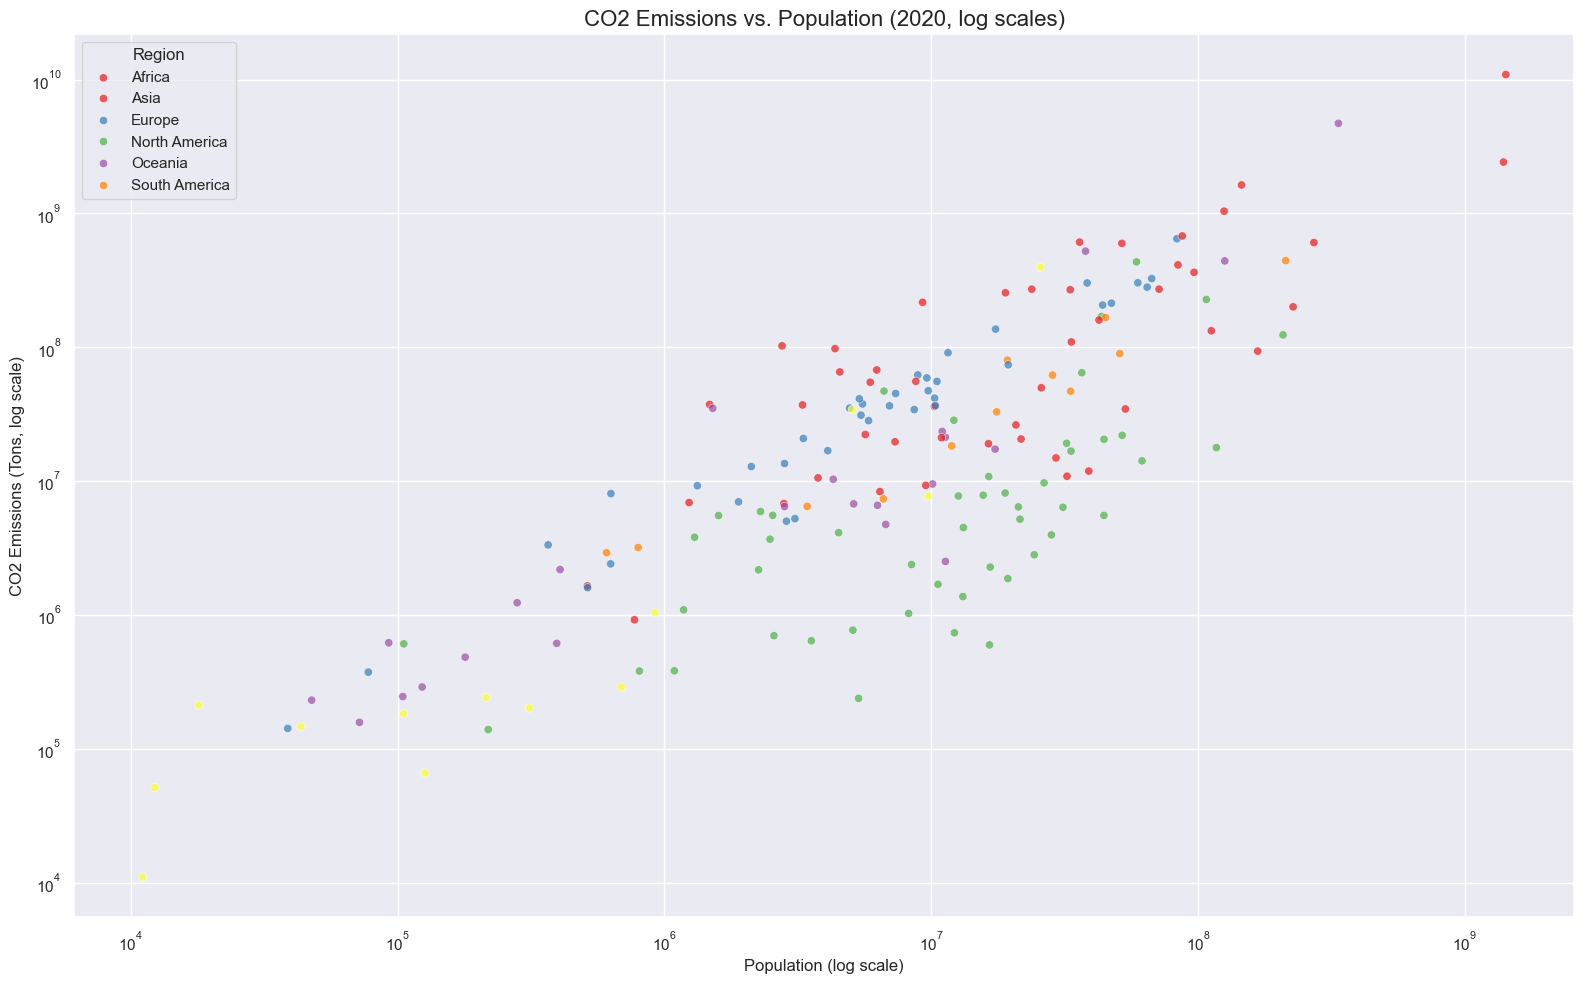

In [1552]:
# Filter the data for year 1970
filtered_data = clean_data[clean_data["Year"] == 2020].copy()

# Create a figure
plt.figure(figsize=(16, 10))

# Create the scatter plot using seaborn
sns.scatterplot(
    data=filtered_data,
    x="Population",
    y="CO2 emission (Tons)",
    hue="Region",
    alpha=0.7,
    palette="Set1"
)

# Set scales to logarithmic
plt.xscale("log")
plt.yscale("log")

# Set labels and title
plt.xlabel("Population (log scale)", fontsize=12)
plt.ylabel("CO2 Emissions (Tons, log scale)", fontsize=12)
plt.title("CO2 Emissions vs. Population (2020, log scales)", fontsize=16)

# Adjust legend - move to upper left corner
plt.legend(title="Region", labels=["Africa", "Asia", "Europe", "North America", "Oceania", "South America"], loc="upper left")

plt.tight_layout()
plt.show()


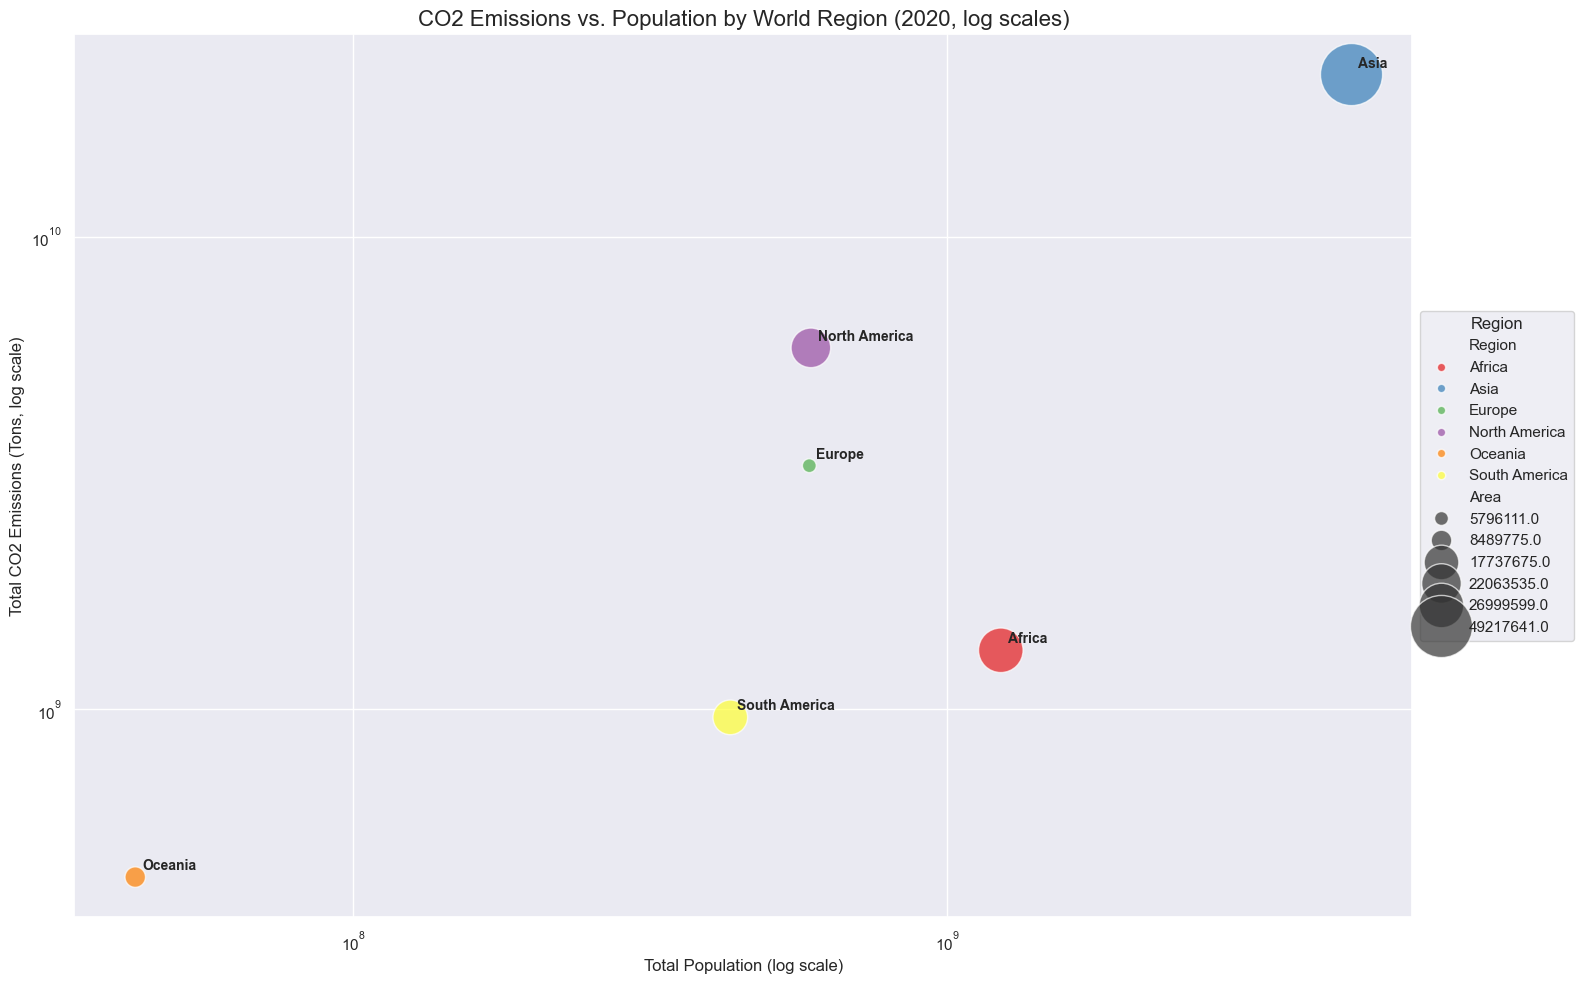

In [1553]:
# Filter the data for year 2020
filtered_data = clean_data[clean_data["Year"] == 2020].copy()

# Group the data by region
grouped_data = filtered_data.groupby("Region").agg({
    "Population": "sum",
    "CO2 emission (Tons)": "sum",
    "Area": "sum"
}).reset_index()

# Create a figure
plt.figure(figsize=(16, 10))

# Create the scatter plot using seaborn
sns.scatterplot(
    data=grouped_data,
    x="Population",
    y="CO2 emission (Tons)",
    size="Area",
    sizes=(100, 2000),
    hue="Region",
    alpha=0.7,
    palette="Set1"
)

# Set scales to logarithmic
plt.xscale("log")
plt.yscale("log")

# Set labels and title
plt.xlabel("Total Population (log scale)", fontsize=12)
plt.ylabel("Total CO2 Emissions (Tons, log scale)", fontsize=12)
plt.title("CO2 Emissions vs. Population by World Region (2020, log scales)", fontsize=16)

# Adjust legend
plt.legend(title="Region", loc="center left", bbox_to_anchor=(1, 0.5))

# Add labels for each region
for _, row in grouped_data.iterrows():
    plt.annotate(row["Region"], (row["Population"], row["CO2 emission (Tons)"]),
                 xytext=(5, 5), textcoords="offset points", fontsize=10,
                 fontweight="bold")

plt.tight_layout()
plt.show()

#### 1.4.6.2 1970

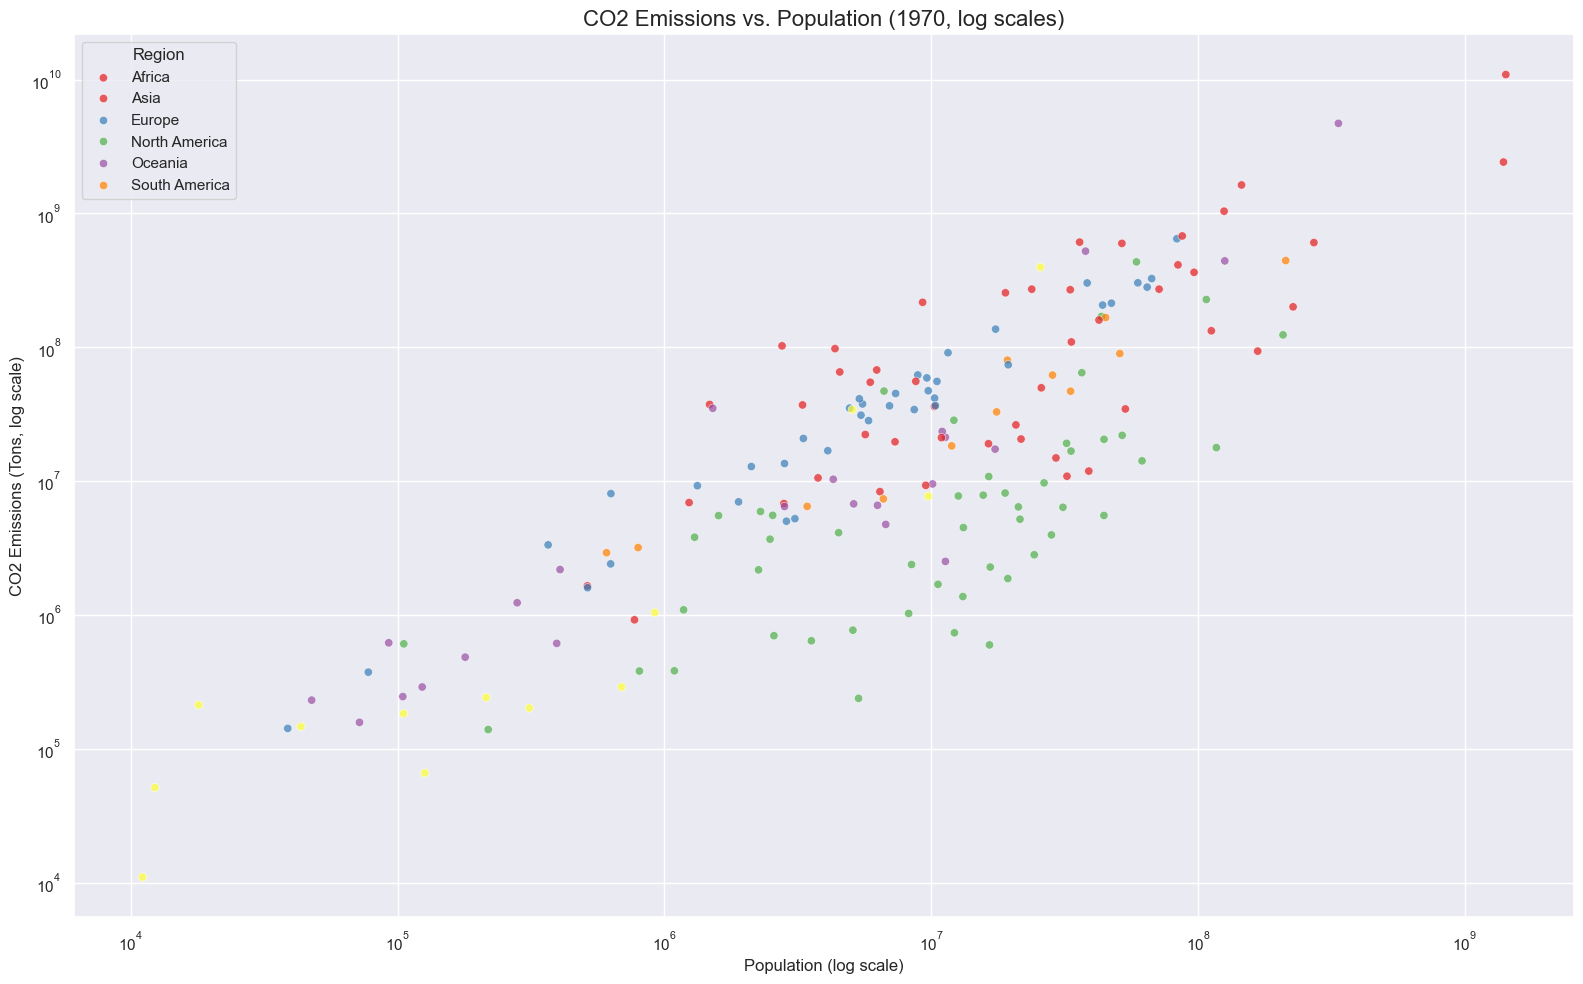

In [1554]:
# Filter the data for year 1970
filtered_data = clean_data[clean_data["Year"] == 2020].copy()

# Create a figure
plt.figure(figsize=(16, 10))

# Create the scatter plot using seaborn
sns.scatterplot(
    data=filtered_data,
    x="Population",
    y="CO2 emission (Tons)",
    hue="Region",
    alpha=0.7,
    palette="Set1"
)

# Set scales to logarithmic
plt.xscale("log")
plt.yscale("log")

# Set labels and title
plt.xlabel("Population (log scale)", fontsize=12)
plt.ylabel("CO2 Emissions (Tons, log scale)", fontsize=12)
plt.title("CO2 Emissions vs. Population (1970, log scales)", fontsize=16)

# Adjust legend - move to upper left corner
plt.legend(title="Region", labels=["Africa", "Asia", "Europe", "North America", "Oceania", "South America"], loc="upper left")

plt.tight_layout()
plt.show()


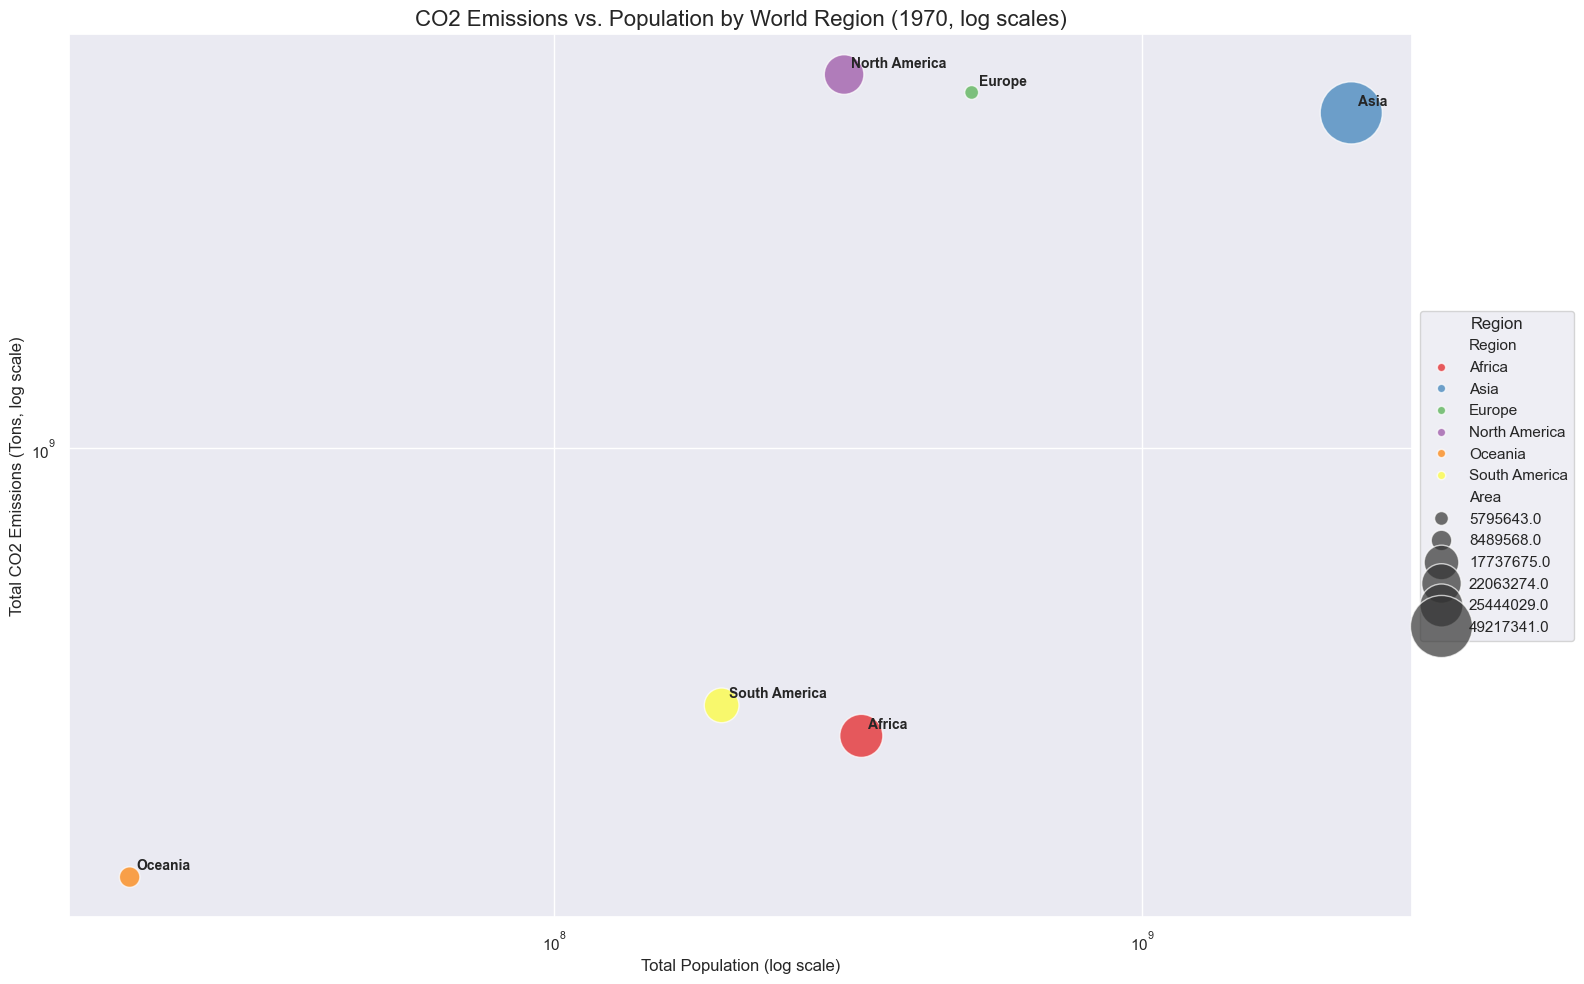

In [1555]:
# Filter the data for year 1970
filtered_data = clean_data[clean_data["Year"] == 1970].copy()

# Group the data by region
grouped_data = filtered_data.groupby("Region").agg({
    "Population": "sum",
    "CO2 emission (Tons)": "sum",
    "Area": "sum"
}).reset_index()

# Create a figure
plt.figure(figsize=(16, 10))

# Create the scatter plot using seaborn
sns.scatterplot(
    data=grouped_data,
    x="Population",
    y="CO2 emission (Tons)",
    size="Area",
    sizes=(100, 2000),
    hue="Region",
    alpha=0.7,
    palette="Set1"
)

# Set scales to logarithmic
plt.xscale("log")
plt.yscale("log")

# Set labels and title
plt.xlabel("Total Population (log scale)", fontsize=12)
plt.ylabel("Total CO2 Emissions (Tons, log scale)", fontsize=12)
plt.title("CO2 Emissions vs. Population by World Region (1970, log scales)", fontsize=16)

# Adjust legend
plt.legend(title="Region", loc="center left", bbox_to_anchor=(1, 0.5))

# Add labels for each region
for _, row in grouped_data.iterrows():
    plt.annotate(row["Region"], (row["Population"], row["CO2 emission (Tons)"]),
                 xytext=(5, 5), textcoords="offset points", fontsize=10,
                 fontweight="bold")

plt.tight_layout()
plt.show()

### 1.4.7 Statistically relevant difference tests

In [1556]:
def run_ttest(group1, group2, group1_name, group2_name, variable_name):
    """
    Perform t-test and interpret results including effect size.

    Parameters:
    group1, group2: pandas Series or numpy arrays of the data to compare
    group1_name, group2_name: strings, names of the groups being compared
    variable_name: string, name of the variable being compared
    """
    t_statistic, p_value = stats.ttest_ind(group1, group2, equal_var=False)

    print(f"T-test results for {variable_name}:")
    print(f"T-statistic: {t_statistic}")
    print(f"P-value: {p_value}")

    alpha = 0.05  # Significance level

    if p_value < alpha: # type: ignore
        print(f"There is a statistically significant difference in {variable_name} between {group1_name} and {group2_name}.")

        # Calculate Cohen's d for effect size
        pooled_std = np.sqrt((group1.var() + group2.var()) / 2)
        cohen_d = abs(group1.mean() - group2.mean()) / pooled_std

        if cohen_d < 0.2:
            strength = "negligible"
        elif cohen_d < 0.5:
            strength = "small"
        elif cohen_d < 0.8:
            strength = "medium"
        else:
            strength = "large"

        print(f"The effect size (Cohen's d) is {cohen_d:.2f}, which indicates a {strength} practical significance.")
    else:
        print(f"There is no statistically significant difference in {variable_name} between {group1_name} and {group2_name}.")

#### 1.4.7.1 T-tests on all data

In [1557]:
#Running the t-test on emissions per capita with the developed and developing countries
developed_le = clean_data.loc[clean_data.Developed==1,'Emissions_per_capita']
developing_le = clean_data.loc[clean_data.Developed==0,'Emissions_per_capita']
#stats.ttest_ind(developed_le, developing_le, equal_var=False)
run_ttest(developed_le, developing_le, "Developed", "Developing", "CO2 emissions per capita")

T-test results for CO2 emissions per capita:
T-statistic: 23.35309071013398
P-value: 4.9030369777268345e-118
There is a statistically significant difference in CO2 emissions per capita between Developed and Developing.
The effect size (Cohen's d) is 0.36, which indicates a small practical significance.


In [1558]:
# Running the t-test on CO2 emissions with high and low population countries
high_pop = clean_data.loc[clean_data.Population > clean_data.Population.median(), 'CO2 emission (Tons)']
low_pop = clean_data.loc[clean_data.Population <= clean_data.Population.median(), 'CO2 emission (Tons)']
run_ttest(high_pop, low_pop, "high population countries", "low population countries", "CO2 emissions")

T-test results for CO2 emissions:
T-statistic: 25.428996238241936
P-value: 5.664904783285835e-138
There is a statistically significant difference in CO2 emissions between high population countries and low population countries.
The effect size (Cohen's d) is 0.37, which indicates a small practical significance.


In [1559]:
# Running the t-test on CO2 emissions with large and small area countries
large_area = clean_data.loc[clean_data.Area > clean_data.Area.median(), 'CO2 emission (Tons)']
small_area = clean_data.loc[clean_data.Area <= clean_data.Area.median(), 'CO2 emission (Tons)']
run_ttest(large_area, small_area, "large area countries", "small area countries", "CO2 emissions")

T-test results for CO2 emissions:
T-statistic: 22.497975161368558
P-value: 3.283310615536898e-109
There is a statistically significant difference in CO2 emissions between large area countries and small area countries.
The effect size (Cohen's d) is 0.33, which indicates a small practical significance.


In [1560]:
# Running the t-test on Asia vs Rest of the World for CO2 emissions
asia_emissions = clean_data.loc[clean_data.Region == 'Asia', 'CO2 emission (Tons)']
non_asia_emissions = clean_data.loc[clean_data.Region != 'Asia', 'CO2 emission (Tons)']
run_ttest(asia_emissions, non_asia_emissions, "Asian countries", "non-Asian countries", "CO2 emissions")

T-test results for CO2 emissions:
T-statistic: 6.238426583708141
P-value: 4.704816162664927e-10
There is a statistically significant difference in CO2 emissions between Asian countries and non-Asian countries.
The effect size (Cohen's d) is 0.11, which indicates a negligible practical significance.


#### 1.4.7.2 T-tests on 2020 data


In [1561]:
#Running the t-test on emissions per capita with the developed and developing countries
developed_le = clean_data.loc[(clean_data.Developed==1) & (clean_data.Year==2020),'Emissions_per_capita']
developing_le = clean_data.loc[(clean_data.Developed==0) & (clean_data.Year==2020),'Emissions_per_capita']
run_ttest(developed_le, developing_le, "Developed", "Developing", "CO2 emissions per capita")

T-test results for CO2 emissions per capita:
T-statistic: 4.374062113290097
P-value: 3.3531947198247694e-05
There is a statistically significant difference in CO2 emissions per capita between Developed and Developing.
The effect size (Cohen's d) is 0.68, which indicates a medium practical significance.


In [1562]:
# Running the t-test on CO2 emissions with high and low population countries
high_pop = clean_data.loc[(clean_data.Population > clean_data.Population.median()) & (clean_data.Year==2020), 'CO2 emission (Tons)']
low_pop = clean_data.loc[(clean_data.Population <= clean_data.Population.median()) & (clean_data.Year==2020), 'CO2 emission (Tons)']
run_ttest(high_pop, low_pop, "high population countries", "low population countries", "CO2 emissions")

T-test results for CO2 emissions:
T-statistic: 2.6524903869467376
P-value: 0.009127794587191929
There is a statistically significant difference in CO2 emissions between high population countries and low population countries.
The effect size (Cohen's d) is 0.35, which indicates a small practical significance.


In [1563]:
# Running the t-test on CO2 emissions with large and small area countries
large_area = clean_data.loc[(clean_data.Area > clean_data.Area.median()) & (clean_data.Year==2020), 'CO2 emission (Tons)']
small_area = clean_data.loc[(clean_data.Area <= clean_data.Area.median()) & (clean_data.Year==2020), 'CO2 emission (Tons)']
run_ttest(large_area, small_area, "large area countries", "small area countries", "CO2 emissions")

T-test results for CO2 emissions:
T-statistic: 2.406483182026537
P-value: 0.018401553450783047
There is a statistically significant difference in CO2 emissions between large area countries and small area countries.
The effect size (Cohen's d) is 0.38, which indicates a small practical significance.


In [1564]:
# Running the t-test on Asia vs Rest of the World for CO2 emissions
asia_emissions = clean_data.loc[(clean_data.Region == 'Asia') & (clean_data.Year==2020), 'CO2 emission (Tons)']
non_asia_emissions = clean_data.loc[(clean_data.Region != 'Asia') & (clean_data.Year==2020), 'CO2 emission (Tons)']
run_ttest(asia_emissions, non_asia_emissions, "Asian countries", "non-Asian countries", "CO2 emissions")

T-test results for CO2 emissions:
T-statistic: 1.601361580575974
P-value: 0.1158396847672518
There is no statistically significant difference in CO2 emissions between Asian countries and non-Asian countries.


### 1.4.8 Feature Engineering

During the lab assignment we have developed and built a dataset containing the different features that we find interesting and want to continue analyzing.

Here is an example of the data that we will continue to use:

In [1565]:
clean_data.head(3)

,Country,Year,CO2 emission (Tons),Population,Area,% of World,Density(km2),Developed,Emissions_per_capita,Region
199,Afghanistan,1949,14656.0,7356890.0,652230.0,0.004,63.0,0,0.001992,Asia
200,Afghanistan,1950,84272.0,7480461.0,652230.0,0.004,63.0,0,0.011266,Asia
201,Afghanistan,1951,91600.0,7571537.0,652230.0,0.004,63.0,0,0.012098,Asia


#### 1.4.8.1 Google Drive / Google Colab

In [1566]:
# We decided to use a better function that automatically closes the file.
#with open(outputFilePath + "clean_data.pickle", "wb") as d_out:
#    pickle.dump([clean_data], d_out)


#### 1.4.8.2 Using own computer

In [1567]:
# We decided to use a better function that automatically closes the file.
#with open("clean_data.pickle", "wb") as d_out:
#    pickle.dump([clean_data], d_out)


## 1.5 Data Clustering

### 1.5.1 Identifying the optimal number of clusters

#### 1.5.1.1 Casting country and region to numbers
We cast the country and region to numbers. This is necessary for the clustering algorithm to work.

##### 1.5.1.1.1 Country
Adding a new column to the dataframe called "Country_num"

In [1568]:
for i, country in enumerate(clean_data.Country.unique()):
    clean_data.loc[clean_data.Country == country, "Country_num"] = i

clean_data.head(3)


,Country,Year,CO2 emission (Tons),Population,Area,% of World,Density(km2),Developed,Emissions_per_capita,Region,Country_num
199,Afghanistan,1949,14656.0,7356890.0,652230.0,0.004,63.0,0,0.001992,Asia,0.0
200,Afghanistan,1950,84272.0,7480461.0,652230.0,0.004,63.0,0,0.011266,Asia,0.0
201,Afghanistan,1951,91600.0,7571537.0,652230.0,0.004,63.0,0,0.012098,Asia,0.0


In [1569]:
clean_data.Country_num.unique()

array([  0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,
        11.,  12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,
        22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,
        33.,  34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,
        44.,  45.,  46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,  54.,
        55.,  56.,  57.,  58.,  59.,  60.,  61.,  62.,  63.,  64.,  65.,
        66.,  67.,  68.,  69.,  70.,  71.,  72.,  73.,  74.,  75.,  76.,
        77.,  78.,  79.,  80.,  81.,  82.,  83.,  84.,  85.,  86.,  87.,
        88.,  89.,  90.,  91.,  92.,  93.,  94.,  95.,  96.,  97.,  98.,
        99., 100., 101., 102., 103., 104., 105., 106., 107., 108., 109.,
       110., 111., 112., 113., 114., 115., 116., 117., 118., 119., 120.,
       121., 122., 123., 124., 125., 126., 127., 128., 129., 130., 131.,
       132., 133., 134., 135., 136., 137., 138., 139., 140., 141., 142.,
       143., 144., 145., 146., 147., 148., 149., 15

##### 1.5.1.1.2 Region
Adding a new column to the dataframe called "Region_num"

In [1570]:
for i, region in enumerate(clean_data.Region.unique()):
    clean_data.loc[clean_data.Region == region, "Region_num"] = i

clean_data.head(3)

,Country,Year,CO2 emission (Tons),Population,Area,% of World,Density(km2),Developed,Emissions_per_capita,Region,Country_num,Region_num
199,Afghanistan,1949,14656.0,7356890.0,652230.0,0.004,63.0,0,0.001992,Asia,0.0,0.0
200,Afghanistan,1950,84272.0,7480461.0,652230.0,0.004,63.0,0,0.011266,Asia,0.0,0.0
201,Afghanistan,1951,91600.0,7571537.0,652230.0,0.004,63.0,0,0.012098,Asia,0.0,0.0


In [1571]:
clean_data.head(3)
clean_data.Region_num.unique()

array([0., 1., 2., 3., 4., 5.])

In [1572]:
clean_data.shape[0]

18625

In [1573]:
grouped_data = clean_data.groupby(["Country"])
grouped_data = grouped_data.agg({
    "CO2 emission (Tons)": "mean",
    "Population": "mean",
    "Area": "mean",
    "% of World": "mean",
    "Density(km2)": "mean",
    "Developed": "mean",
    "Emissions_per_capita": "mean",
    "Region": "first",
    "Country_num": "first",
    "Region_num": "first"
})

grouped_data.shape

(182, 10)

In [1574]:
grouped_data.head(3)

,CO2 emission (Tons),Population,Area,% of World,Density(km2),Developed,Emissions_per_capita,Region,Country_num,Region_num
Country,,,,,,,,,,
Afghanistan,2.865627e+06,1.618591e+07,652230.0,0.004,63.0,0.0,0.147467,Asia,0.0,0.0
Albania,3.284426e+06,2.337672e+06,28748.0,0.000,99.0,0.0,1.227787,Europe,1.0,1.0
Algeria,4.495500e+07,1.792814e+07,2381741.0,0.016,19.0,0.0,1.600975,Africa,2.0,2.0


#### 1.5.1.2 Using 2 clusters

##### 1.5.1.2.1 Creating 2 clusters

In [1575]:
grouped_data_cluster_2 = grouped_data.copy() # type: ignore
grouped_data_cluster_2.drop(columns=["Region"], inplace=True)

grouped_data_cluster_2.head(3)


,CO2 emission (Tons),Population,Area,% of World,Density(km2),Developed,Emissions_per_capita,Country_num,Region_num
Country,,,,,,,,,
Afghanistan,2.865627e+06,1.618591e+07,652230.0,0.004,63.0,0.0,0.147467,0.0,0.0
Albania,3.284426e+06,2.337672e+06,28748.0,0.000,99.0,0.0,1.227787,1.0,1.0
Algeria,4.495500e+07,1.792814e+07,2381741.0,0.016,19.0,0.0,1.600975,2.0,2.0


In [1576]:
# Standard-scaling, which turns dataframes into numpy ndarrays were they need to be transformed back into dataframes
sc=StandardScaler()
grouped_data_cluster_2_scaled = sc.fit_transform(grouped_data_cluster_2)
grouped_data_cluster_2_scaled


array([[-0.24841725, -0.05334186, -0.03252816, ..., -0.55358852,
        -1.72256005, -1.175105  ],
       [-0.24651217, -0.23926492, -0.35076752, ..., -0.35208678,
        -1.70352623, -0.50256063],
       [-0.05695573, -0.02995107,  0.85025351, ..., -0.28247977,
        -1.68449242,  0.16998374],
       ...,
       [-0.21887042, -0.08506608, -0.09595431, ..., -0.46675785,
         1.68449242, -1.175105  ],
       [-0.24537942, -0.16522597,  0.01870909, ..., -0.4616516 ,
         1.70352623,  0.16998374],
       [-0.231328  , -0.19170411, -0.16598991, ..., -0.36976979,
         1.72256005,  0.16998374]])

In [1577]:
# Transforming the numpy ndarray back into a dataframe
grouped_data_cluster_2 = pd.DataFrame(grouped_data_cluster_2_scaled, index=grouped_data_cluster_2.index, columns=grouped_data_cluster_2.columns)
grouped_data_cluster_2.head(3)

,CO2 emission (Tons),Population,Area,% of World,Density(km2),Developed,Emissions_per_capita,Country_num,Region_num
Country,,,,,,,,,
Afghanistan,-0.248417,-0.053342,-0.032528,-0.049099,-0.223399,-0.479301,-0.553589,-1.722560,-1.175105
Albania,-0.246512,-0.239265,-0.350768,-0.365420,-0.169228,-0.479301,-0.352087,-1.703526,-0.502561
Algeria,-0.056956,-0.029951,0.850254,0.899864,-0.289609,-0.479301,-0.282480,-1.684492,0.169984


1.5.2.2.1 K-means method

In [1578]:
# Create a k-means model with 2 clusters
kmeans_2f = KMeans(n_clusters=2)
# Fit the model to the data
kmeans_2f.fit(grouped_data_cluster_2)
# Add the cluster labels to the dataframe
grouped_data_cluster_2["cluster"] = kmeans_2f.labels_
grouped_data_cluster_2.head(3)

,CO2 emission (Tons),Population,Area,% of World,Density(km2),Developed,Emissions_per_capita,Country_num,Region_num,cluster
Country,,,,,,,,,,
Afghanistan,-0.248417,-0.053342,-0.032528,-0.049099,-0.223399,-0.479301,-0.553589,-1.722560,-1.175105,1
Albania,-0.246512,-0.239265,-0.350768,-0.365420,-0.169228,-0.479301,-0.352087,-1.703526,-0.502561,1
Algeria,-0.056956,-0.029951,0.850254,0.899864,-0.289609,-0.479301,-0.282480,-1.684492,0.169984,1


In [1579]:
# Get the center of the clusters
center_2f = kmeans_2f.cluster_centers_
center_2f


array([[ 5.53392377e-01,  3.68121078e-01,  4.73479993e-01,
         4.70314151e-01,  3.01420520e-01,  1.50326315e+00,
         8.03682985e-01,  4.32586652e-03, -4.56705329e-01],
       [-1.76443946e-01, -1.17371938e-01, -1.50964635e-01,
        -1.49955237e-01, -9.61050933e-02, -4.79301293e-01,
        -2.56246749e-01, -1.37926179e-03,  1.45616192e-01]])

In [1580]:
y_2f = pd.DataFrame(kmeans_2f.labels_, index=grouped_data_cluster_2.index)
y_2f.head(2)

,0
Country,
Afghanistan,1
Albania,1


#### 1.5.1.3 Calculating the optimal number of clusters

In [1581]:
# Resetting the variable
grouped_data = clean_data.groupby(["Country"])
grouped_data = grouped_data.agg({
    "CO2 emission (Tons)": "mean",
    "Population": "mean",
    "Area": "mean",
    "% of World": "mean",
    "Density(km2)": "mean",
    "Developed": "mean",
    "Emissions_per_capita": "mean",
    "Region": "first",
    "Country_num": "first",
    "Region_num": "first"
})

grouped_data.shape

(182, 10)

In [1582]:
group_data_cluster_N=grouped_data.copy() # type: ignore
group_data_cluster_N=group_data_cluster_N.drop(columns=['Population', 'Region'])
group_data_cluster_N.head(3)

,CO2 emission (Tons),Area,% of World,Density(km2),Developed,Emissions_per_capita,Country_num,Region_num
Country,,,,,,,,
Afghanistan,2.865627e+06,652230.0,0.004,63.0,0.0,0.147467,0.0,0.0
Albania,3.284426e+06,28748.0,0.000,99.0,0.0,1.227787,1.0,1.0
Algeria,4.495500e+07,2381741.0,0.016,19.0,0.0,1.600975,2.0,2.0


In [1583]:
# Standard-scaling, just like before
sc=StandardScaler()
group_data_cluster_Nsc=sc.fit_transform(group_data_cluster_N)
group_data_cluster_N=pd.DataFrame(group_data_cluster_Nsc, index=group_data_cluster_N.index, columns=group_data_cluster_N.columns)
group_data_cluster_N.head(3)

,CO2 emission (Tons),Area,% of World,Density(km2),Developed,Emissions_per_capita,Country_num,Region_num
Country,,,,,,,,
Afghanistan,-0.248417,-0.032528,-0.049099,-0.223399,-0.479301,-0.553589,-1.722560,-1.175105
Albania,-0.246512,-0.350768,-0.365420,-0.169228,-0.479301,-0.352087,-1.703526,-0.502561
Algeria,-0.056956,0.850254,0.899864,-0.289609,-0.479301,-0.282480,-1.684492,0.169984


In [1584]:
# The following code defines first some parameters and then iterates in a for loop where the data is
# clustered from 1 to 15 clusters. The inertia value is added to the SSE-array, one for each clustering
# SSE stands for 'Sum of Squared Errors', see: https://hlab.stanford.edu/brian/error_sum_of_squares.html

kmeans_kwargs = {
    "init": "random",
    "n_init": 10,
    "max_iter": 300,
    "random_state": 42,
    }

# A list holds the SSE values for each k
sse = []
for k in range(1, 15):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(group_data_cluster_N)
    sse.append(kmeans.inertia_)

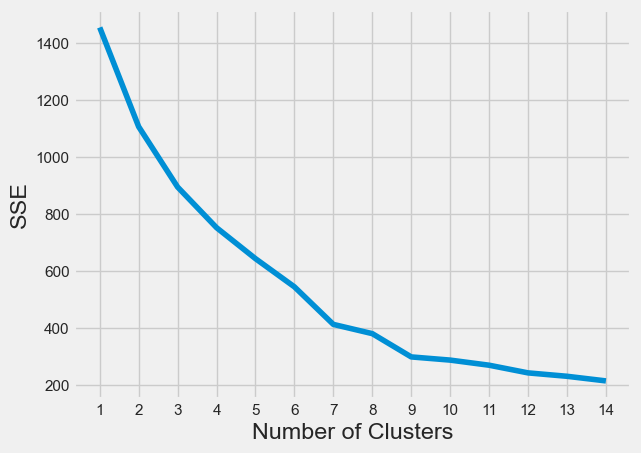

In [1585]:
# Plots the value for SSE found
plt.style.use("fivethirtyeight")
plt.plot(range(1, 15), sse)
plt.xticks(range(1, 15))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()

##### 1.5.1.3.1 Calculating the percentage change
Here we calculate the percentage change in SSE (Sum of Squared Errors) between each number of clusters.

We plot two lines on the same graph:
   - Blue line: Shows how SSE decreases as we increase the number of clusters.
   - Orange line: Shows the percentage change in SSE for each additional cluster.

This point can be identified where:
   - The blue line (SSE) starts to level off.
   - The orange line (percentage change) becomes consistently small.

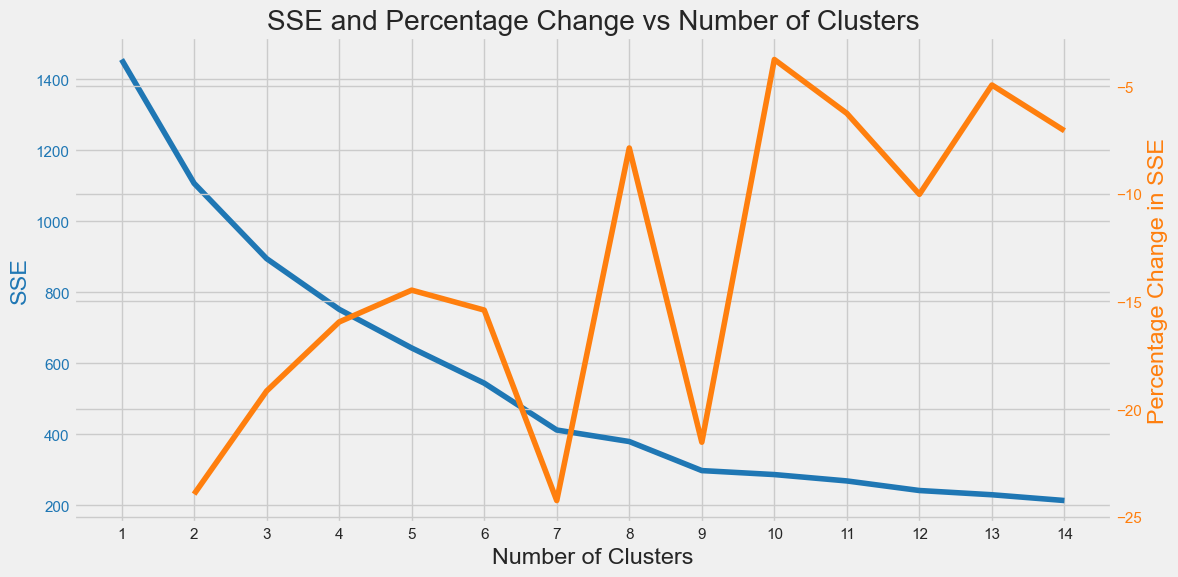

Clusters: 1, SSE: 1456.00
Clusters: 2, SSE: 1107.30, Change: -23.95%
Clusters: 3, SSE: 895.15, Change: -19.16%
Clusters: 4, SSE: 752.36, Change: -15.95%
Clusters: 5, SSE: 643.46, Change: -14.47%
Clusters: 6, SSE: 544.38, Change: -15.40%
Clusters: 7, SSE: 412.38, Change: -24.25%
Clusters: 8, SSE: 379.93, Change: -7.87%
Clusters: 9, SSE: 298.10, Change: -21.54%
Clusters: 10, SSE: 286.90, Change: -3.76%
Clusters: 11, SSE: 268.94, Change: -6.26%
Clusters: 12, SSE: 241.99, Change: -10.02%
Clusters: 13, SSE: 230.02, Change: -4.94%
Clusters: 14, SSE: 213.76, Change: -7.07%


In [1586]:
# Calculate percentage change
# The percentage change is calculated by taking the difference between the current SSE and the previous SSE,
# dividing it by the previous SSE, and multiplying by 100 to get a percentage.
pct_change = np.diff(sse) / sse[:-1] * 100

# Create the plot
plt.style.use("fivethirtyeight")
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot SSE
color = 'tab:blue'
ax1.set_xlabel('Number of Clusters')
ax1.set_ylabel('SSE', color=color)
ax1.plot(range(1, 15), sse, color=color)
ax1.tick_params(axis='y', labelcolor=color)

# Create a second y-axis
ax2 = ax1.twinx()

# Plot percentage change
color = 'tab:orange'
ax2.set_ylabel('Percentage Change in SSE', color=color)
ax2.plot(range(2, 15), pct_change, color=color)
ax2.tick_params(axis='y', labelcolor=color)

# Set x-ticks
plt.xticks(range(1, 15))

plt.title('SSE and Percentage Change vs Number of Clusters')
plt.tight_layout()
plt.show()

# Print SSE and percentage change for each number of clusters
for i in range(len(sse)):
    if i == 0:
        print(f"Clusters: {i+1}, SSE: {sse[i]:.2f}")
    else:
        print(f"Clusters: {i+1}, SSE: {sse[i]:.2f}, Change: {pct_change[i-1]:.2f}%")

##### 1.5.1.3.2 Our elbow
We decided that our elbow is at **9-10**, since this is where the the last large percentage change in SSE goes below and it does not return to above **20%** in change.

### 1.5.2 Clustering
We will now cluster the data into 9 clusters.

In [1587]:
# create kmeans object with 9 clusters
kmeans_9f = KMeans(init='random', n_clusters=9, n_init=10, max_iter=300, random_state=42)

# fit kmeans object to data
kmeans_9f.fit(group_data_cluster_N)

# save the location of the centers of the clusters learned by kmeans object
center_9f=kmeans_9f.cluster_centers_

# save Labels of each point
y_9f = pd.DataFrame(kmeans_9f.labels_, index=group_data_cluster_N.index)

# Adding the labels to the overview table
grouped_data['Cluster9']=y_9f # type: ignore
y_9f.value_counts()


0
0    47
6    44
7    31
5    29
3    19
8     5
1     3
2     3
4     1
Name: count, dtype: int64

In [1588]:
for cluster in sorted(grouped_data['Cluster9'].unique()):
    countries = grouped_data[grouped_data['Cluster9'] == cluster].index.tolist()
    print(f"\nCluster {cluster}:")
    print(", ".join(countries))


Cluster 0:
Albania, Algeria, Angola, Antigua and Barbuda, Argentina, Bahamas, Barbados, Belarus, Belize, Benin, Bolivia, Bosnia and Herzegovina, Botswana, Burkina Faso, Burundi, Cameroon, Central African Republic, Chad, Chile, Colombia, Comoros, Costa Rica, Cuba, Djibouti, Dominica, Dominican Republic, Ecuador, Egypt, El Salvador, Equatorial Guinea, Eritrea, Eswatini, Ethiopia, Gabon, Gambia, Ghana, Grenada, Guatemala, Guinea, Guyana, Haiti, Honduras, Jamaica, Kenya, Lesotho, Liberia, Libya

Cluster 1:
Australia, Brazil, Canada

Cluster 2:
China, Russia, United States

Cluster 3:
Fiji, Kiribati, Marshall Islands, Nauru, New Zealand, Palau, Papua New Guinea, Paraguay, Peru, Saint Kitts and Nevis, Samoa, Solomon Islands, Suriname, Tonga, Trinidad and Tobago, Tuvalu, Uruguay, Vanuatu, Venezuela

Cluster 4:
Singapore

Cluster 5:
Andorra, Austria, Belgium, Bulgaria, Croatia, Cyprus, Denmark, Germany, Hungary, Iceland, Ireland, Italy, Japan, Latvia, Liechtenstein, Lithuania, Malta, Netherla

#### 1.5.2.1 Looking at the clusters

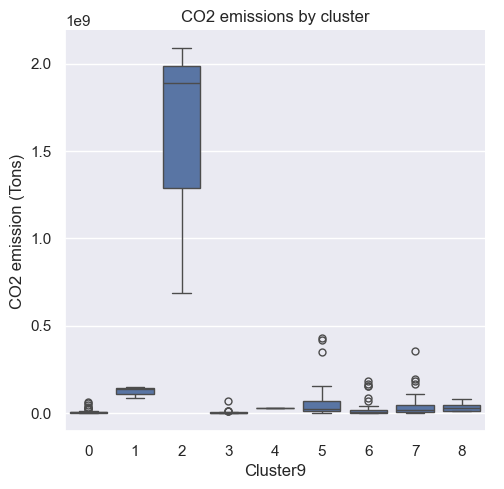

In [1589]:
#Example: Comparing the distributions for CO2 emissions based on clustering
sns.set_theme() #reset to default
sns.catplot(data=grouped_data, x="Cluster9", y="CO2 emission (Tons)", kind="box") # type: ignore
plt.title('CO2 emissions by cluster')
plt.show()


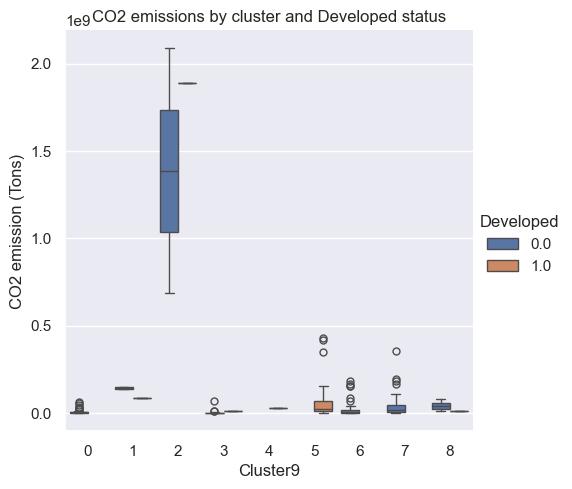

In [1590]:
#Example: Comparing the distributions for life expectancy based on clustering, coloring with Developed-value
sns.catplot(data=grouped_data, x="Cluster9", y="CO2 emission (Tons)", kind="box", hue='Developed') # type: ignore
plt.title('CO2 emissions by cluster and Developed status')
plt.show()


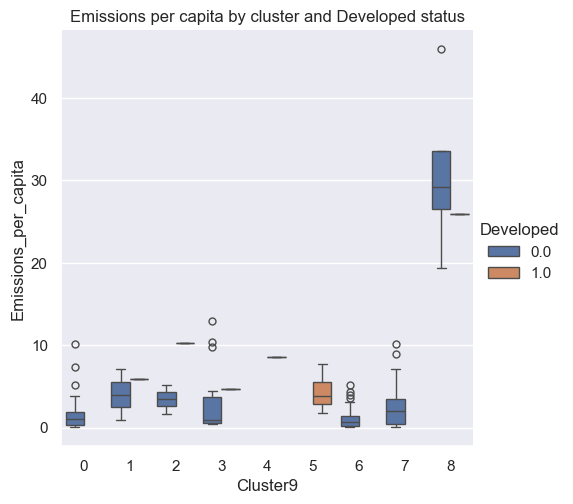

In [1591]:
#Example: Comparing the distributions for emissions per capita based on clustering, coloring with Developed-value
sns.catplot(data=grouped_data, x="Cluster9", y="Emissions_per_capita", kind="box", hue='Developed') # type: ignore
plt.title('Emissions per capita by cluster and Developed status')
plt.show()


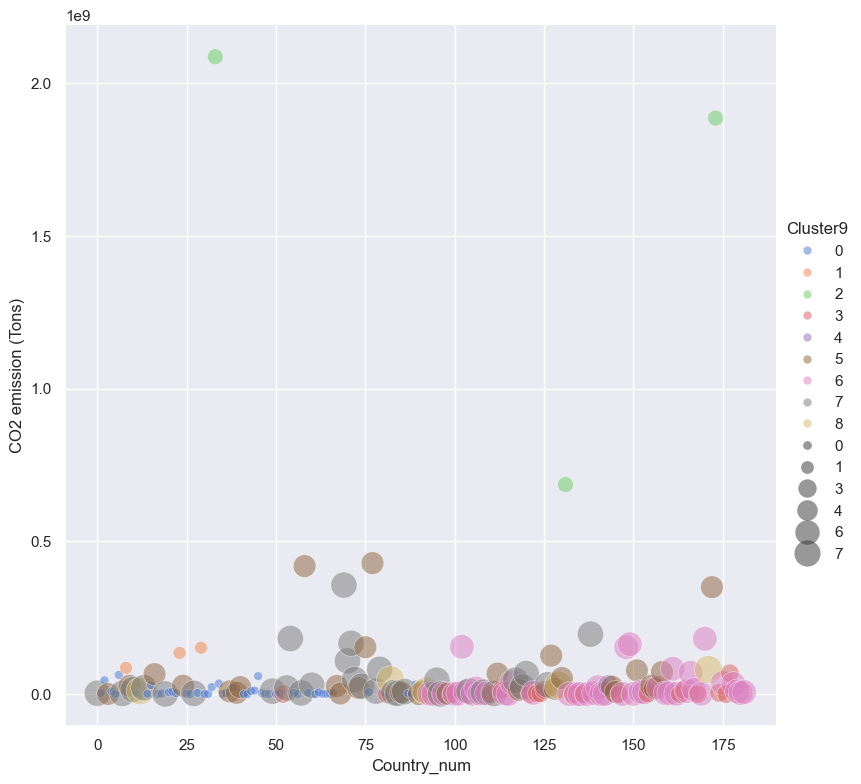

In [1592]:
# Plotting the values of CO2 emissions of all the countries, coloring the clusters
sns.relplot(x="Country_num", y="CO2 emission (Tons)", hue="Cluster9", size="Cluster9",
            sizes=(40, 400), alpha=.5, palette="muted",
            height=8, data=grouped_data) # type: ignore

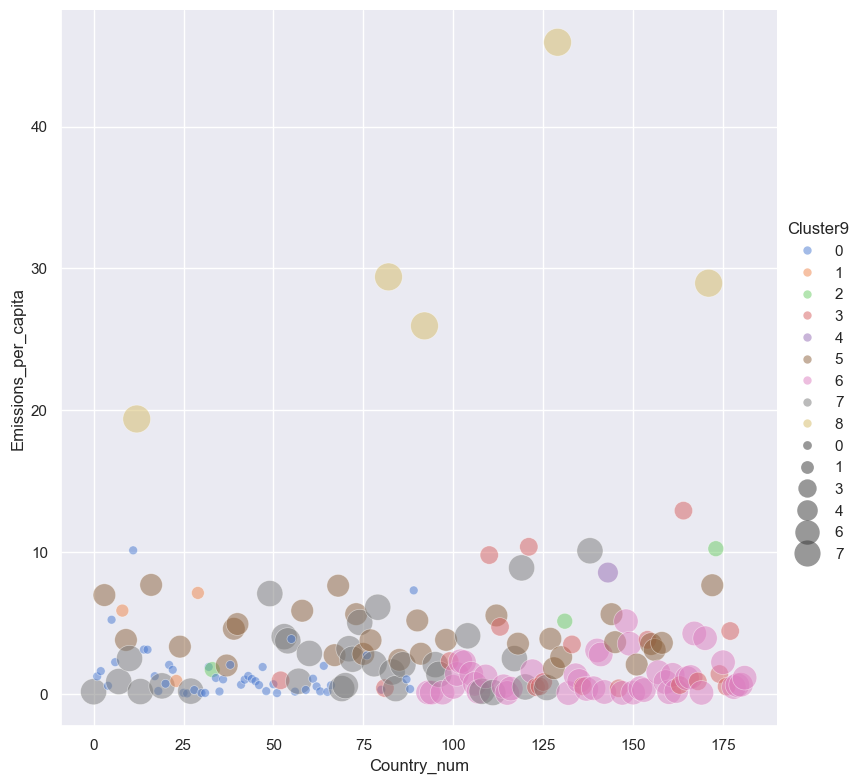

In [1593]:
# Plotting the values of emissions per capita of all the countries, coloring the clusters
sns.relplot(x="Country_num", y="Emissions_per_capita", hue="Cluster9", size="Cluster9",
            sizes=(40, 400), alpha=.5, palette="muted",
            height=8, data=grouped_data) # type: ignore

##### 1.5.2.1.1 Plotting without cluster 2

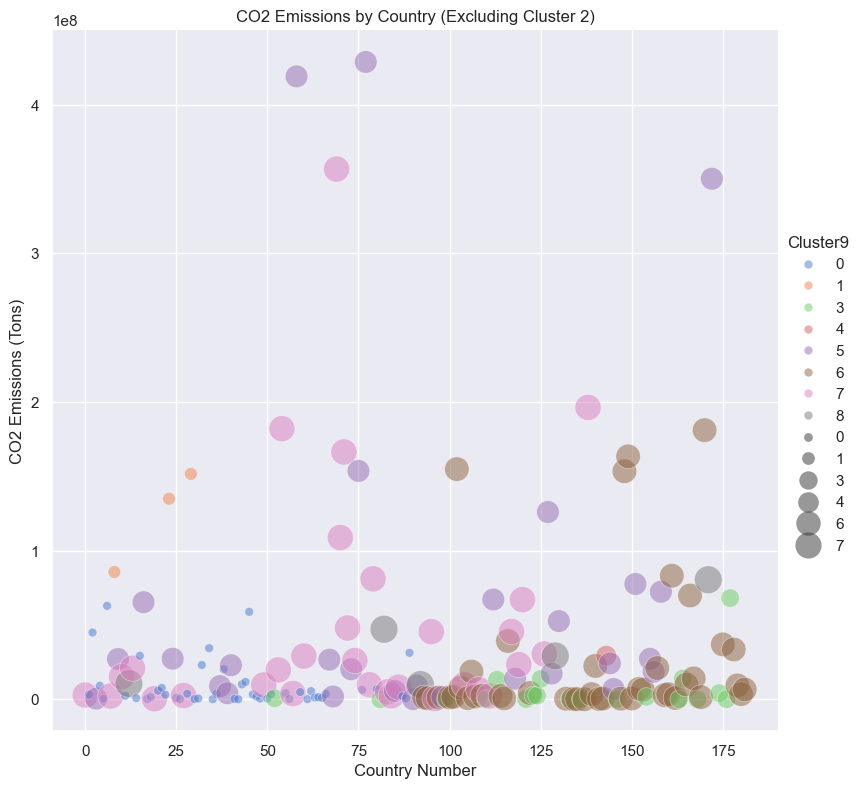

In [1594]:
# Plotting the values of CO2 emissions of all the countries, coloring the clusters, but ignores cluster 2
sns.relplot(x="Country_num", y="CO2 emission (Tons)", hue="Cluster9", size="Cluster9",
            sizes=(40, 400), alpha=.5, palette="muted",
            height=8, data=grouped_data[grouped_data['Cluster9'] != 2])  # type: ignore

plt.title("CO2 Emissions by Country (Excluding Cluster 2)")
plt.xlabel("Country Number")
plt.ylabel("CO2 Emissions (Tons)")
plt.show()

#### 1.5.2.2 Discussing the results (focusing on cluster 2, 5 and 7):
We quickly realized that it was hard to come to conclusions about the different clusters, so we decided to focus on cluster 2, 5 and 7, and recursively excluding more and more clusters.

- Cluster 2: There is a large distance between the 3 dots visible in the plot. They are by far the most contributing countries to the total CO2 emissions. They also seem to have a high spread in emissions per capita, ranging from around 2 to 10.5 (estimated). This cluster seems to contain a large amount of undeveloped countries, and just a few developed countries.
- Cluster 5: Seems to be the second highest cluster when it comes to CO2 emissions, they seem to have a bit larger emissions than cluster 7. Cluster 5 also seems to contain only contain developed countries. The emissions per capita seems to range from around 0 to 10.
- Cluster 7: The cluster 7 seems the be the third highest cluster when it comes to CO2 emissions. They seem to be only containing undeveloped countries. The emissions per capita seems to range from around 0 to 10.

#### 1.5.2.3 Looking at the clusters (0, 1, 3, 4, 6, 8)

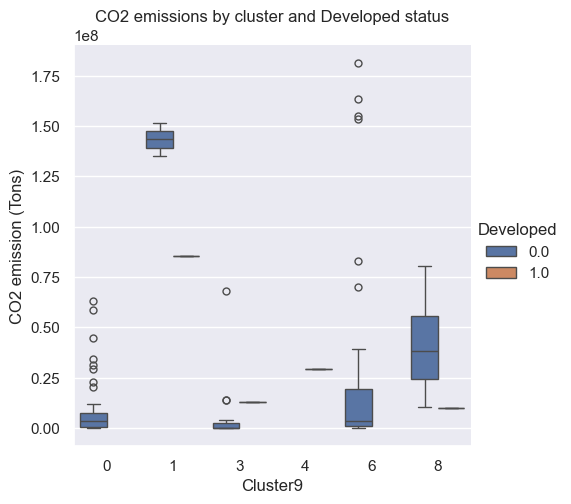

In [1595]:
#Example: Comparing the distributions for CO2 emissions based on clustering, coloring with Developed-value
sns.catplot(data=grouped_data[grouped_data['Cluster9'].isin([0, 1, 3, 4, 6, 8])], x="Cluster9", y="CO2 emission (Tons)", kind="box", hue='Developed') # type: ignore
plt.title('CO2 emissions by cluster and Developed status')
plt.show()


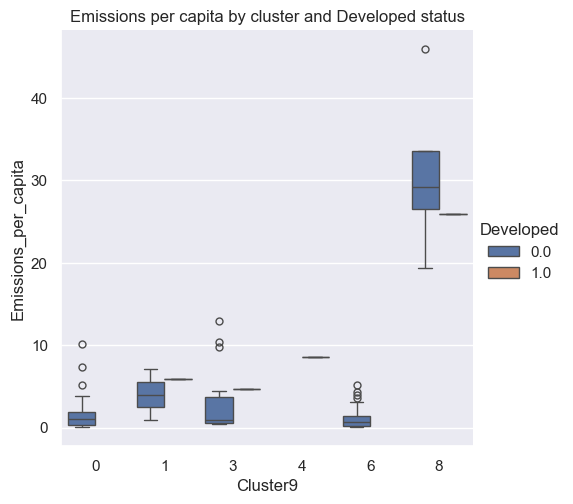

In [1596]:
#Example: Comparing the distributions for emissions per capita based on clustering, coloring with Developed-value
sns.catplot(data=grouped_data[grouped_data['Cluster9'].isin([0, 1, 3, 4, 6, 8])], x="Cluster9", y="Emissions_per_capita", kind="box", hue='Developed') # type: ignore
plt.title('Emissions per capita by cluster and Developed status')
plt.show()


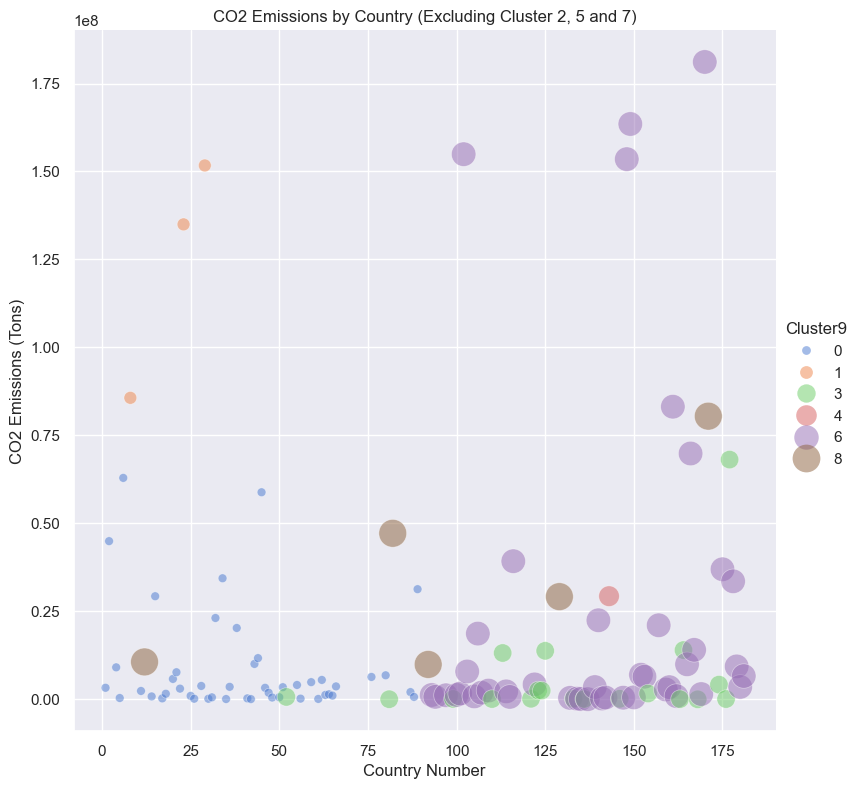

In [1597]:
# Plotting the values of CO2 emissions of all the countries, coloring the clusters, but ignores cluster 2, 5 and 7
sns.relplot(x="Country_num", y="CO2 emission (Tons)", hue="Cluster9", size="Cluster9",
            sizes=(40, 400), alpha=.5, palette="muted",
            height=8, data=grouped_data[grouped_data['Cluster9'].isin([0, 1, 3, 4, 6, 8])])  # type: ignore

plt.title("CO2 Emissions by Country (Excluding Cluster 2, 5 and 7)")
plt.xlabel("Country Number")
plt.ylabel("CO2 Emissions (Tons)")
plt.show()

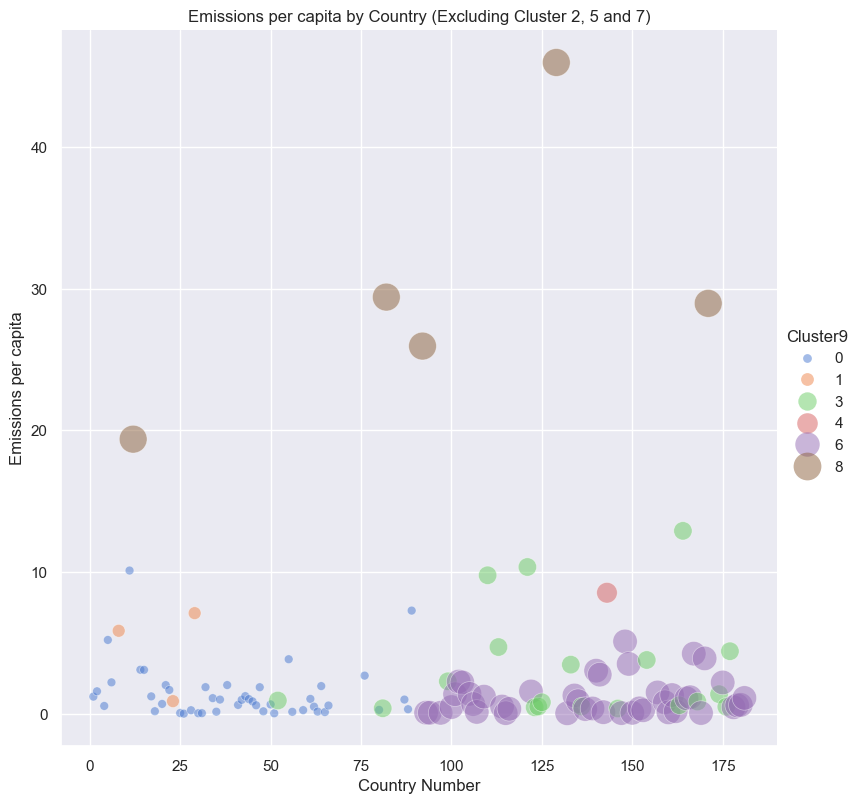

In [1598]:
# Plotting the values of emissions per capita of all the countries, coloring the clusters, but ignores cluster 2, 5 and 7
sns.relplot(x="Country_num", y="Emissions_per_capita", hue="Cluster9", size="Cluster9",
            sizes=(40, 400), alpha=.5, palette="muted",
            height=8, data=grouped_data[grouped_data['Cluster9'].isin([0, 1, 3, 4, 6, 8])])  # type: ignore

plt.title("Emissions per capita by Country (Excluding Cluster 2, 5 and 7)")
plt.xlabel("Country Number")
plt.ylabel("Emissions per capita")
plt.show()

#### 1.5.2.4 Discussing the results (focusing on cluster, 1, 6 and 8):
- Cluster 1: This cluster seems to be the fourth largest CO2 emitter. Cluster 6 has some dots that are higher, but they also seem to have a lot more that are lower. Cluster 1 also seems to only contain undeveloped countries.
- Cluster 6: This cluster seems to be the fifth largest CO2 emitter. They seem to have a smaller spread in emissions per capita, ranging from around 0 to 5 (approximately). It looks like this cluster only contains undeveloped countries.
- Cluster 8: Seems to be one of the largest contributors when it comes to emissions per capita, ranging from around 14 to 47 (approximately). In terms of total CO2 emissions their highest contributing country is at the same level as the lowest point of cluster 1. This one seems to be the sixth largest CO2 emitter. It looks like the majority of the countries are undeveloped, with a few developed countries.


#### 1.5.2.5 Looking at the clusters (0, 3, 4)

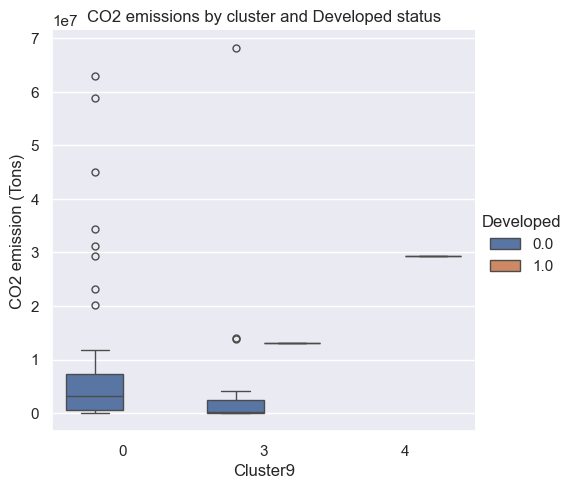

In [1599]:
#Example: Comparing the distributions for CO2 emissions based on clustering, coloring with Developed-value
sns.catplot(data=grouped_data[grouped_data['Cluster9'].isin([0, 3, 4])], x="Cluster9", y="CO2 emission (Tons)", kind="box", hue='Developed') # type: ignore
plt.title('CO2 emissions by cluster and Developed status')
plt.show()

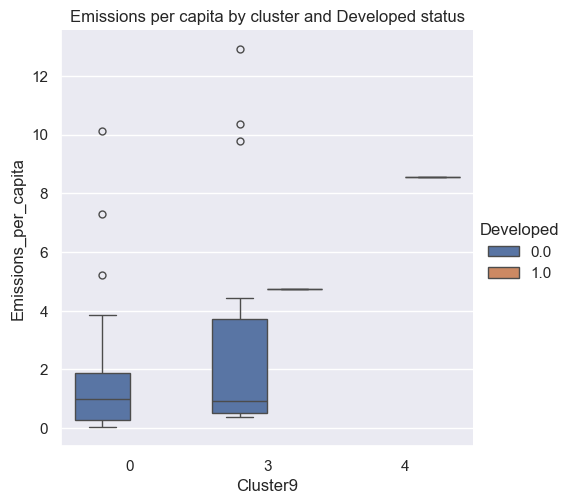

In [1600]:
#Example: Comparing the distributions for emissions per capita based on clustering, coloring with Developed-value
sns.catplot(data=grouped_data[grouped_data['Cluster9'].isin([0, 3, 4])], x="Cluster9", y="Emissions_per_capita", kind="box", hue='Developed') # type: ignore
plt.title('Emissions per capita by cluster and Developed status')
plt.show()

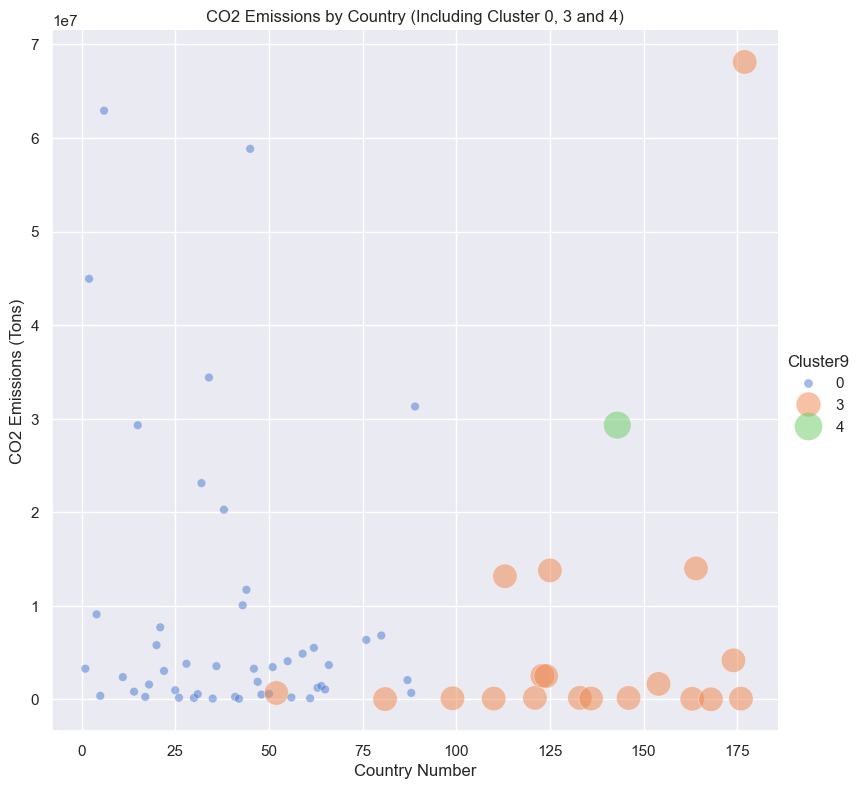

In [1601]:
# Plotting the values of CO2 emissions of all the countries, coloring the clusters, but ignores cluster 2, 5 and 7
sns.relplot(x="Country_num", y="CO2 emission (Tons)", hue="Cluster9", size="Cluster9",
            sizes=(40, 400), alpha=.5, palette="muted",
            height=8, data=grouped_data[grouped_data['Cluster9'].isin([0, 3, 4])])  # type: ignore

plt.title("CO2 Emissions by Country (Including Cluster 0, 3 and 4)")
plt.xlabel("Country Number")
plt.ylabel("CO2 Emissions (Tons)")
plt.show()

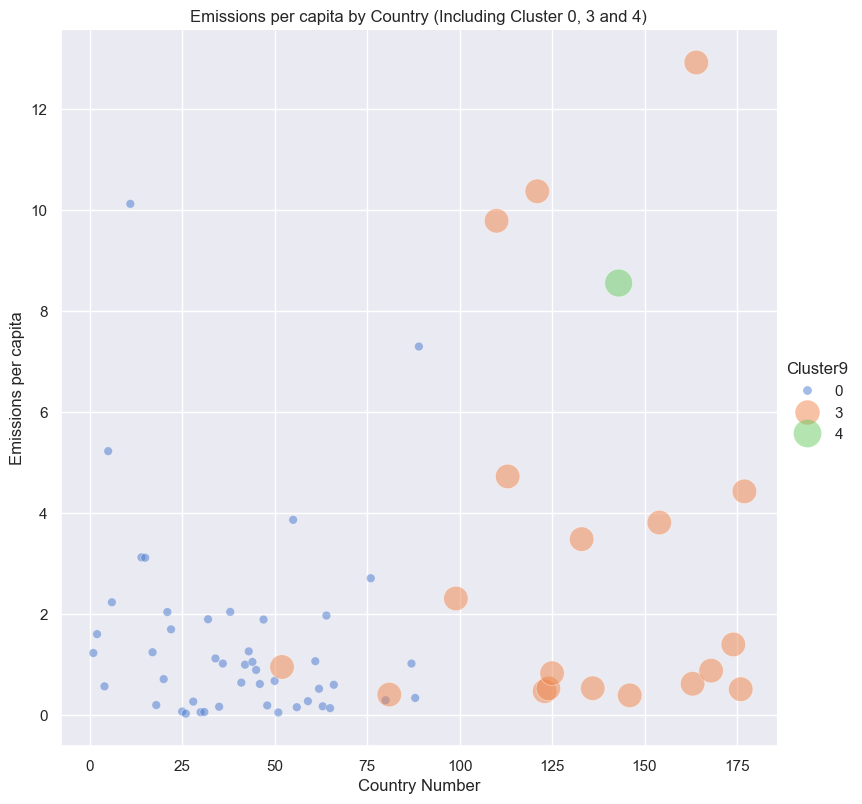

In [1602]:
# Plotting the values of emissions per capita of all the countries, coloring the clusters, but ignores cluster 2, 5 and 7
sns.relplot(x="Country_num", y="Emissions_per_capita", hue="Cluster9", size="Cluster9",
            sizes=(40, 400), alpha=.5, palette="muted",
            height=8, data=grouped_data[grouped_data['Cluster9'].isin([0, 3, 4])])  # type: ignore

plt.title("Emissions per capita by Country (Including Cluster 0, 3 and 4)")
plt.xlabel("Country Number")
plt.ylabel("Emissions per capita")
plt.show()

#### 1.5.2.6 Discussing the results (focusing on cluster 0, 3 and 4):
- Cluster 0: This cluster seems to only contain undeveloped countries, with a low country number. They have a few countries with a high emissions per capita, but most of them have a low emissions per capita, ranging from around 0 to 2.
- Cluster 3: This cluster seems to consist of a majority of undeveloped countries, but with a few developed countries. This cluster seems to have a spread of emissions per capita, ranging from around 0.5 to 13.
- Cluster 4: This cluster seems to consist of a single country. It is a developed country with a quite large emissions per capita compared to cluster 0 and 3. This cluster seems to be the seventh largest CO2 emitter. Their emissions per capita seems to be around 8.5.

#### 1.5.3 Discussing the results (combined):
Throughout this evaluation when we mention high CO2 emissions we base it on the average of a country, and what we see. Not extra calculations were made.

- Cluster 0: This cluster seems to only contain undeveloped countries, with a low country number. They have a few countries with a high emissions per capita, but most of them have a low emissions per capita, ranging from around 0 to 2.
- Cluster 1: This cluster seems to be the fourth largest CO2 emitter. Cluster 6 has some dots that are higher, but they also seem to have a lot more that are lower. Cluster 1 also seems to only contain undeveloped countries.
- Cluster 2: There is a large distance between the 3 dots visible in the plot. They are by far the most contributing countries to the total CO2 emissions. They also seem to have a high spread in emissions per capita, ranging from around 2 to 10.5 (estimated). This cluster seems to contain a large amount of undeveloped countries, and just a few developed countries.
- Cluster 3: This cluster seems to consist of a majority of undeveloped countries, but with a few developed countries. This cluster seems to have a spread of emissions per capita, ranging from around 0.5 to 13.
- Cluster 4: This cluster seems to consist of a single country. It is a developed country with a quite large emissions per capita compared to cluster 0 and 3. This cluster seems to be the seventh largest CO2 emitter. Their emissions per capita seems to be around 8.5.
- Cluster 5: Seems to be the second highest cluster when it comes to CO2 emissions, they seem to have a bit larger emissions than cluster 7. Cluster 5 also seems to contain only contain developed countries. The emissions per capita seems to range from around 0 to 10.
- Cluster 6: This cluster seems to be the fifth largest CO2 emitter. They seem to have a smaller spread in emissions per capita, ranging from around 0 to 5 (approximately). It looks like this cluster only contains undeveloped countries.
- Cluster 7: The cluster 7 seems the be the third highest cluster when it comes to CO2 emissions. They seem to be only containing undeveloped countries. The emissions per capita seems to range from around 0 to 10.
- Cluster 8: Seems to be one of the largest contributors when it comes to emissions per capita, ranging from around 14 to 47 (approximately). In terms of total CO2 emissions their highest contributing country is at the same level as the lowest point of cluster 1. This one seems to be the sixth largest CO2 emitter. It looks like the majority of the countries are undeveloped, with a few developed countries.

### 1.5.4 Plotting the scatterplots of all the significant single attributes

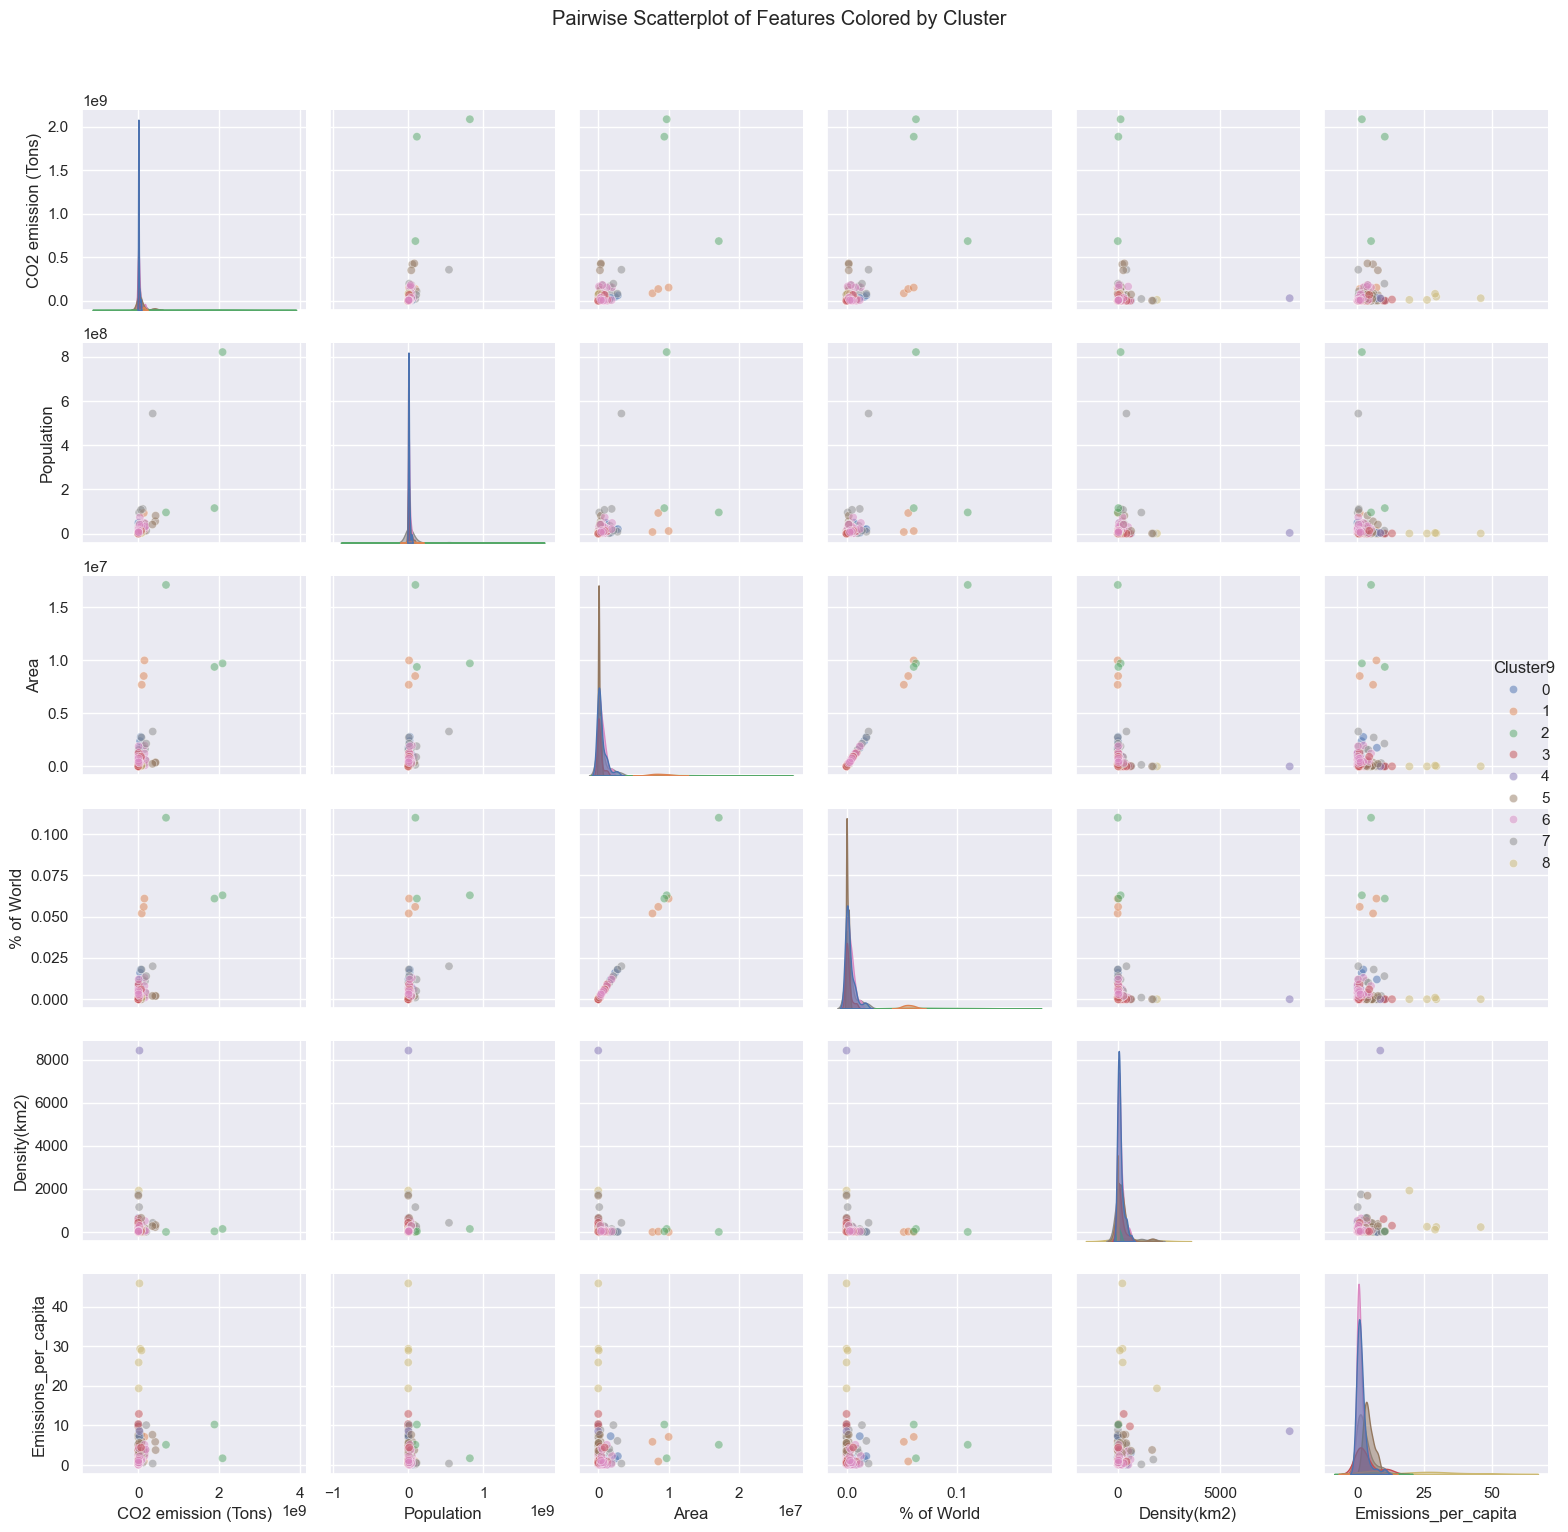

In [1603]:
# Select the relevant features for the scatter plot
features = ["CO2 emission (Tons)", "Population", "Area", "% of World", "Density(km2)", "Emissions_per_capita"]

# Create a copy of the grouped data with only the selected features and the cluster labels
plot_data = grouped_data[features + ["Cluster9"]].copy() # type: ignore

# Create the pairwise scatter plot
sns.set_theme()
sns.pairplot(plot_data, hue="Cluster9", plot_kws={"alpha": 0.5}, diag_kws={"alpha": 0.5}, palette="deep")
plt.suptitle("Pairwise Scatterplot of Features Colored by Cluster", y=1.02)
plt.tight_layout()
plt.show()

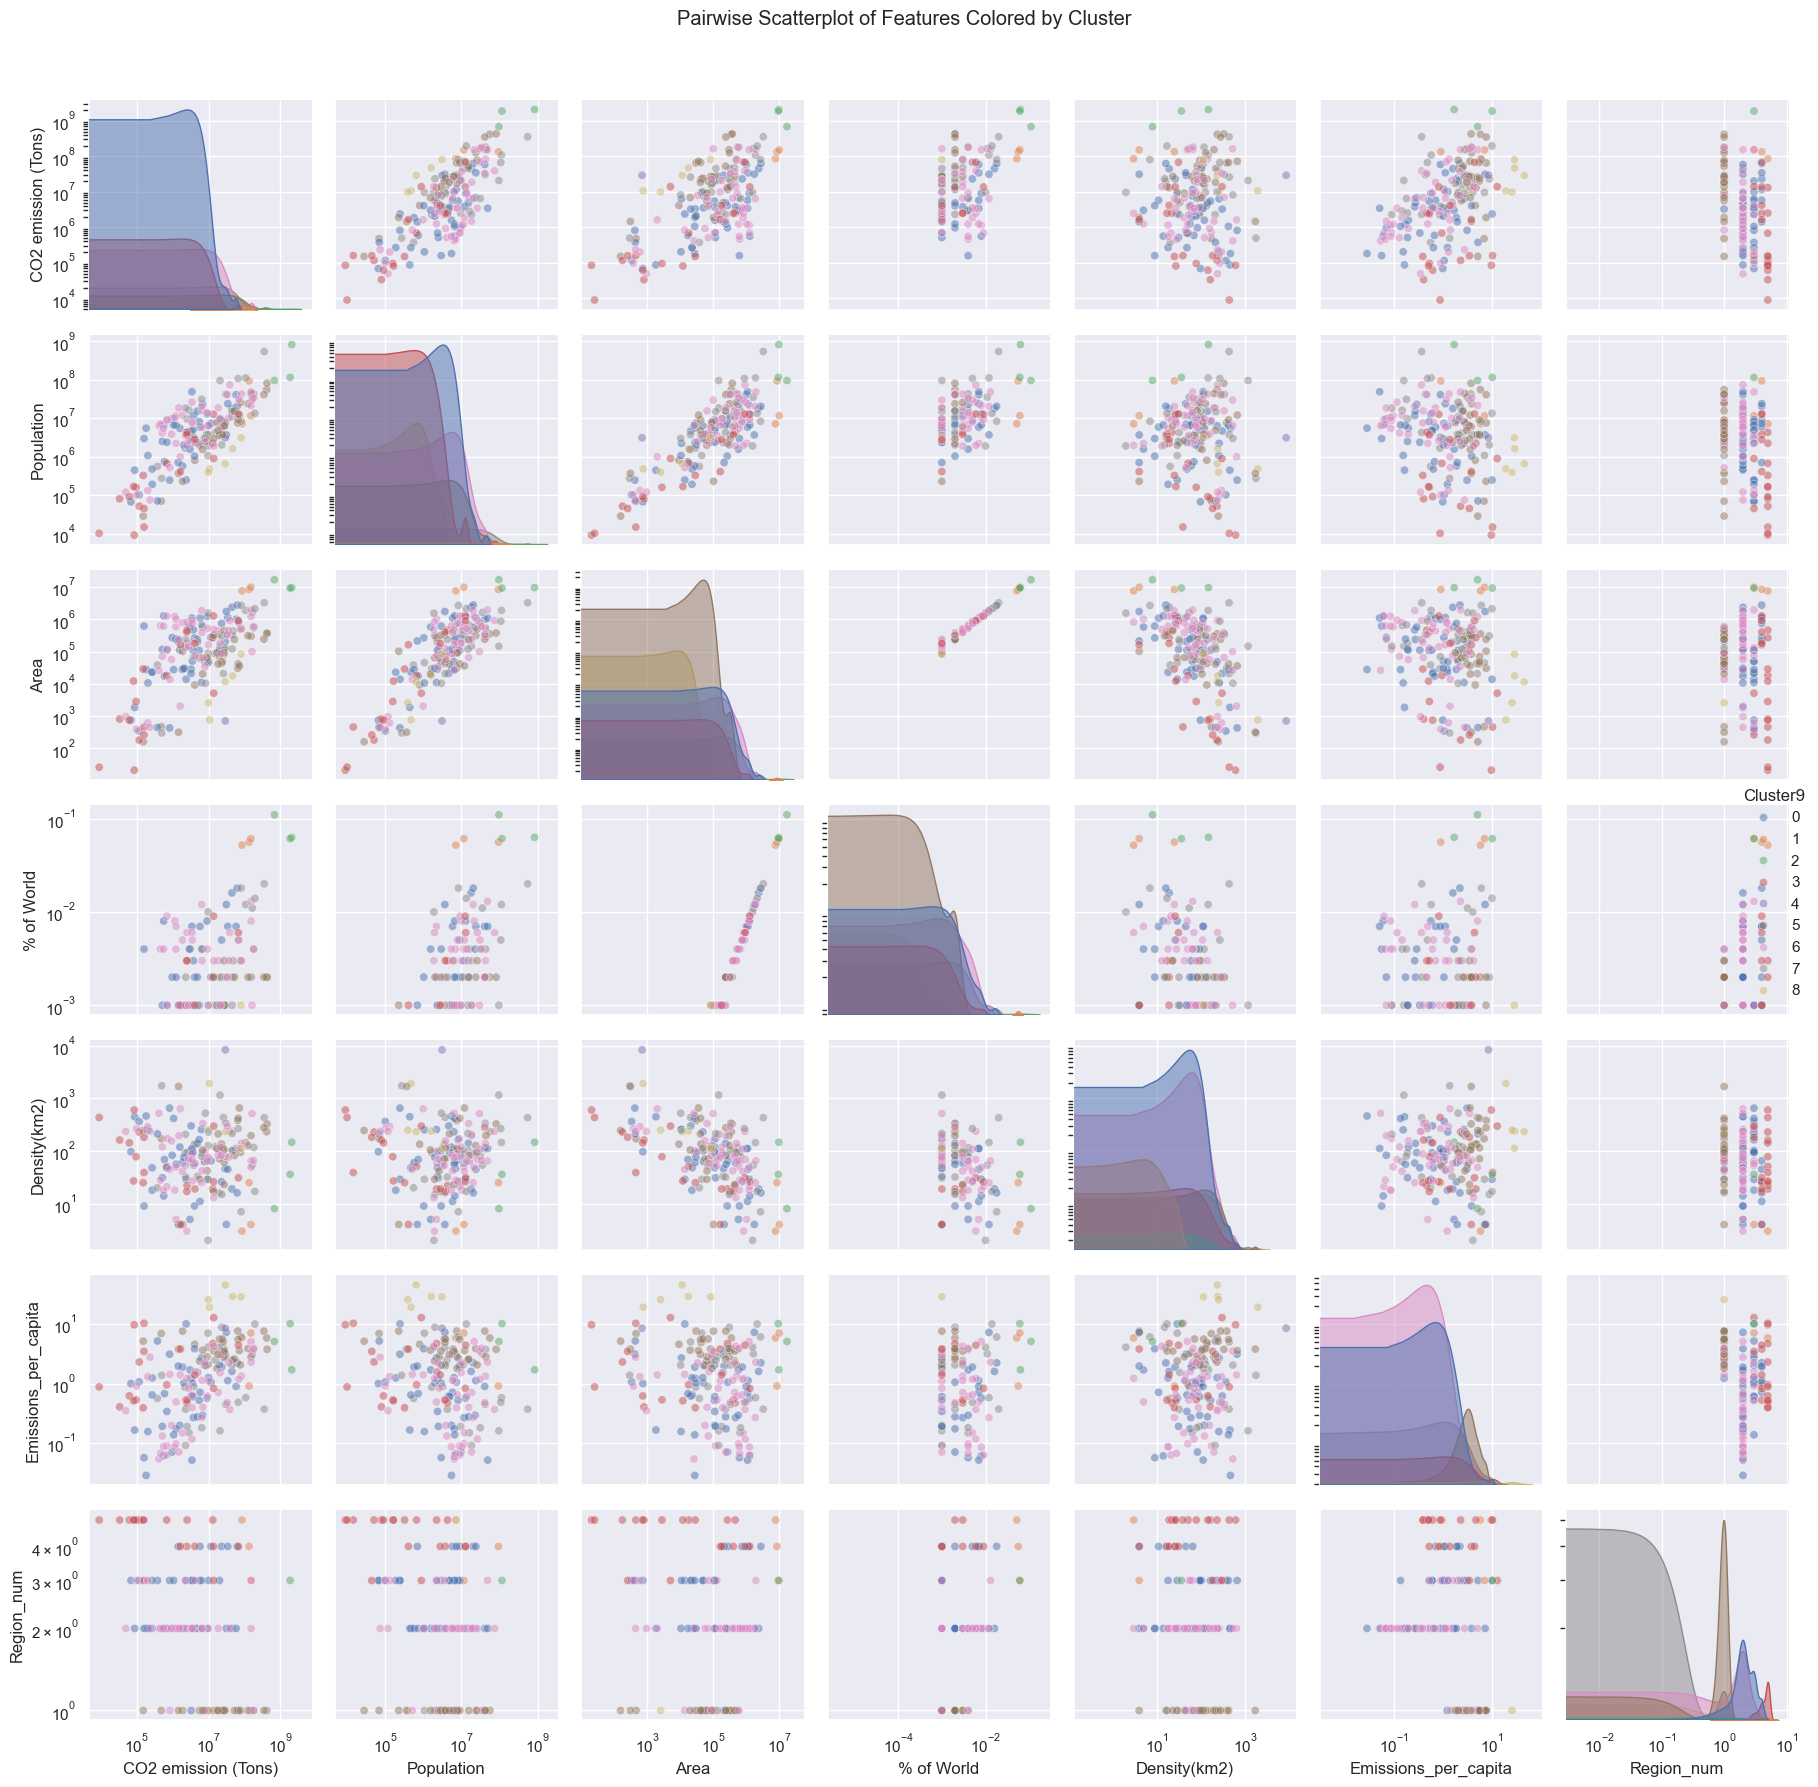

In [1604]:
# Select the relevant features for the scatter plot
features = ["CO2 emission (Tons)", "Population", "Area", "% of World", "Density(km2)", "Emissions_per_capita", "Region_num"]

# Create a copy of the grouped data with only the selected features and the cluster labels
plot_data = grouped_data[features + ["Cluster9"]].copy() # type: ignore

# Create the pairwise scatter plot
sns.set_theme()
g = sns.pairplot(plot_data, hue="Cluster9", plot_kws={"alpha": 0.5}, diag_kws={"alpha": 0.5}, palette="deep")

# Apply log scale to all axes
for ax in g.axes.flat:
    ax.set_xscale("log")
    ax.set_yscale("log")

plt.suptitle("Pairwise Scatterplot of Features Colored by Cluster", y=1.02)
plt.tight_layout()
plt.show()

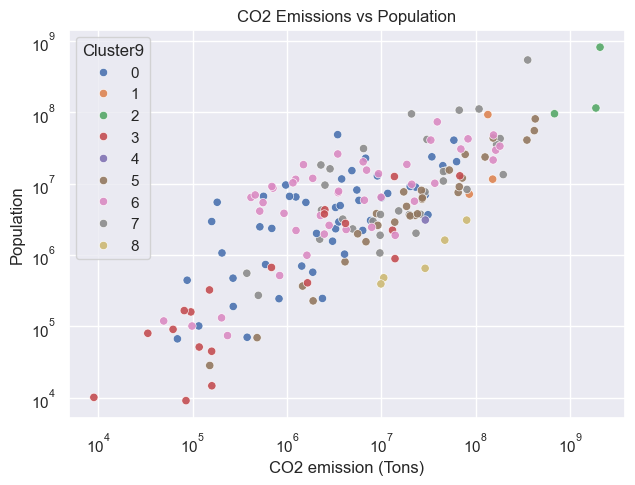

In [1605]:
# Example of creating an individual scatter plot for two specific attributes
sns.scatterplot(data=plot_data, x="CO2 emission (Tons)", y="Population", hue="Cluster9", alpha=0.9, palette="deep")
plt.title("CO2 Emissions vs Population")
plt.xscale("log")  # Use log scale if the range of values is very large
plt.yscale("log")
plt.show()

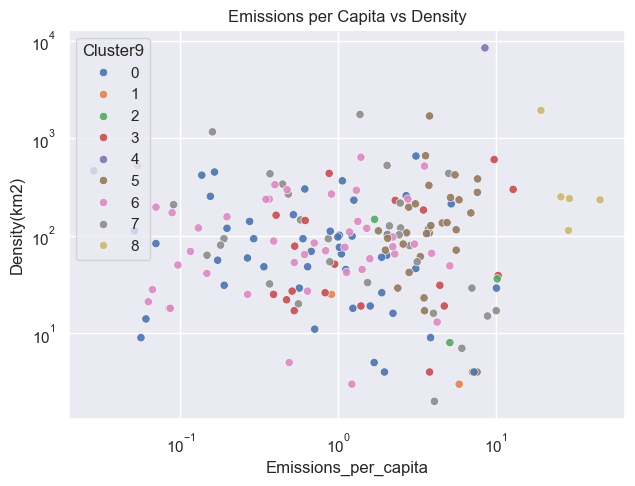

In [1606]:
# Example of creating an individual scatter plot for two specific attributes
sns.scatterplot(data=plot_data, x="Emissions_per_capita", y="Density(km2)", hue="Cluster9", alpha=0.9, palette="deep")
plt.title("Emissions per Capita vs Density")
plt.xscale("log")  # Use log scale if the range of values is very large
plt.yscale("log")
plt.show()

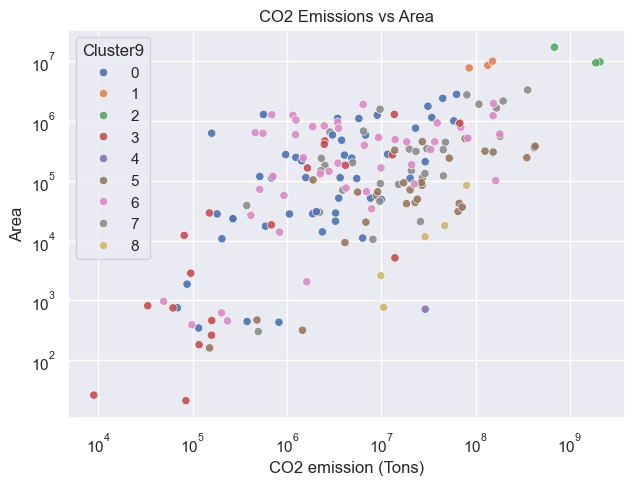

In [1607]:
sns.scatterplot(data=plot_data, x="CO2 emission (Tons)", y="Area", hue="Cluster9", alpha=0.9, palette="deep")
plt.title("CO2 Emissions vs Area")
plt.xscale("log")
plt.yscale("log")
plt.show()


## 1.6 Feature Engineering

### 1.6.1 Targets
- **Emissions_per_capita**: This is the main target, as it is the one we want to predict.
- **CO2 emissions (tons)**: This is the second target, as it is also important.
- **CO2 emissions per area**: This is the third target.

### 1.6.2 Attributes

- **CO2 emissions (tons)** vs **Population**: This is important.

### 1.6.2.1 Irrelevant correlations for our targets
- **Area** vs **Population**: This is not that relevant, according to our group, but it seems to be important according to the clustering.
- **Area** vs **% of world**: This is seems to be important according to the clustering. We should probably had removed one of them before clustering.

#### 1.6.2.2 Next iteration could have given us more information
If we would have removed one of the attributes regarding landmass (either **Area** or **% of world**), we could have gotten more information about the relationship between the remaining attribute and the target. Therefore, we iterated and tried again without **% of world**.

In [1608]:
# Resetting the variable
grouped_data = clean_data.groupby(["Country"])
grouped_data = grouped_data.agg({
    "CO2 emission (Tons)": "mean",
    "Population": "mean",
    "Area": "mean",
    "Density(km2)": "mean",
    "Developed": "mean",
    "Emissions_per_capita": "mean",
    "Region": "first",
    "Country_num": "first",
    "Region_num": "first"
})

grouped_data.shape

(182, 9)

In [1609]:
group_data_cluster_N = grouped_data.copy() # type: ignore
group_data_cluster_N = group_data_cluster_N.drop(columns=['Region'])
group_data_cluster_N.head(3)

,CO2 emission (Tons),Population,Area,Density(km2),Developed,Emissions_per_capita,Country_num,Region_num
Country,,,,,,,,
Afghanistan,2.865627e+06,1.618591e+07,652230.0,63.0,0.0,0.147467,0.0,0.0
Albania,3.284426e+06,2.337672e+06,28748.0,99.0,0.0,1.227787,1.0,1.0
Algeria,4.495500e+07,1.792814e+07,2381741.0,19.0,0.0,1.600975,2.0,2.0


In [1610]:
# Standard-scaling, just like before
sc=StandardScaler()
group_data_cluster_Nsc=sc.fit_transform(group_data_cluster_N)
group_data_cluster_N=pd.DataFrame(group_data_cluster_Nsc, index=group_data_cluster_N.index, columns=group_data_cluster_N.columns)
group_data_cluster_N.head(3)

,CO2 emission (Tons),Population,Area,Density(km2),Developed,Emissions_per_capita,Country_num,Region_num
Country,,,,,,,,
Afghanistan,-0.248417,-0.053342,-0.032528,-0.223399,-0.479301,-0.553589,-1.722560,-1.175105
Albania,-0.246512,-0.239265,-0.350768,-0.169228,-0.479301,-0.352087,-1.703526,-0.502561
Algeria,-0.056956,-0.029951,0.850254,-0.289609,-0.479301,-0.282480,-1.684492,0.169984


In [1611]:
# The following code defines first some parameters and then iterates in a for loop where the data is
# clustered from 1 to 15 clusters. The inertia value is added to the SSE-array, one for each clustering
# SSE stands for 'Sum of Squared Errors', see: https://hlab.stanford.edu/brian/error_sum_of_squares.html

kmeans_kwargs = {
    "init": "random",
    "n_init": 10,
    "max_iter": 300,
    "random_state": 42,
    }

# A list holds the SSE values for each k
sse = []
for k in range(1, 15):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(group_data_cluster_N)
    sse.append(kmeans.inertia_)

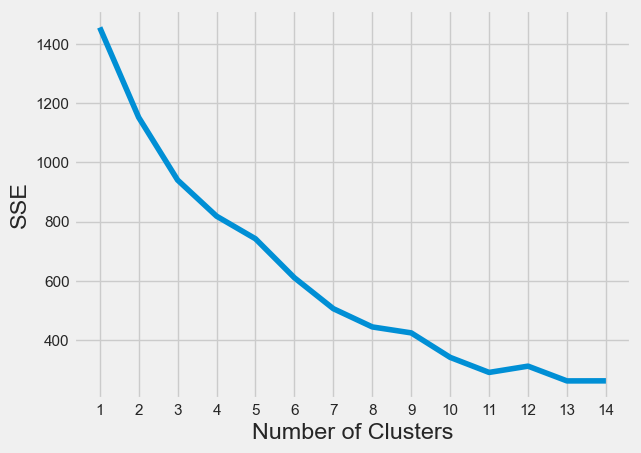

In [1612]:
# Plots the value for SSE found
plt.style.use("fivethirtyeight")
plt.plot(range(1, 15), sse)
plt.xticks(range(1, 15))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()

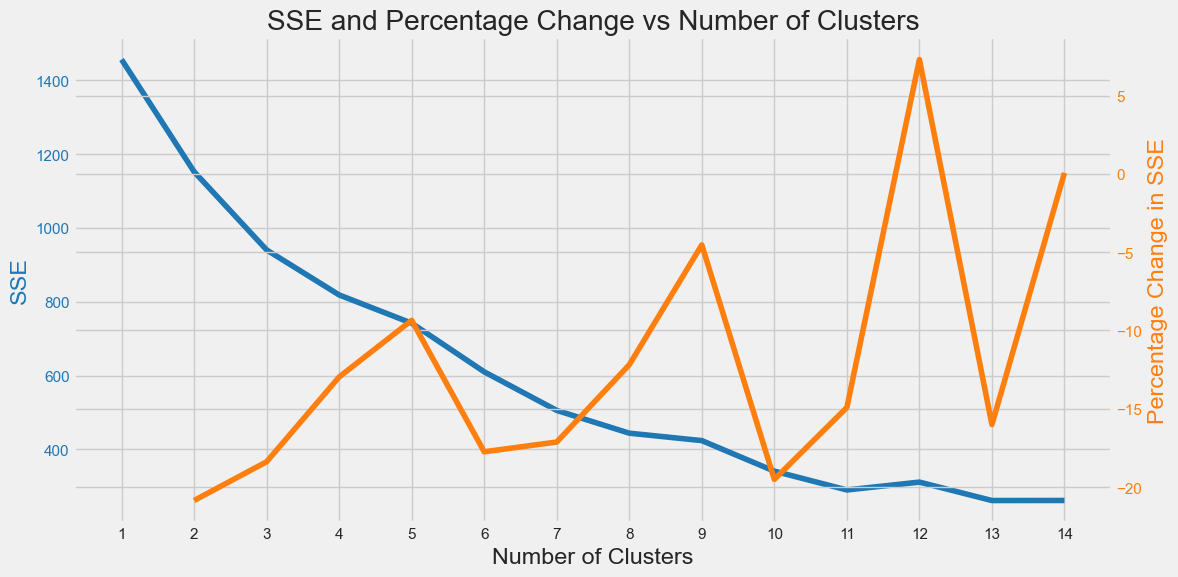

Clusters: 1, SSE: 1456.00
Clusters: 2, SSE: 1152.23, Change: -20.86%
Clusters: 3, SSE: 940.39, Change: -18.39%
Clusters: 4, SSE: 818.43, Change: -12.97%
Clusters: 5, SSE: 741.92, Change: -9.35%
Clusters: 6, SSE: 610.25, Change: -17.75%
Clusters: 7, SSE: 505.75, Change: -17.12%
Clusters: 8, SSE: 444.10, Change: -12.19%
Clusters: 9, SSE: 423.98, Change: -4.53%
Clusters: 10, SSE: 341.25, Change: -19.51%
Clusters: 11, SSE: 290.35, Change: -14.91%
Clusters: 12, SSE: 311.59, Change: 7.31%
Clusters: 13, SSE: 261.70, Change: -16.01%
Clusters: 14, SSE: 261.89, Change: 0.07%


In [1613]:
# Calculate percentage change
# The percentage change is calculated by taking the difference between the current SSE and the previous SSE,
# dividing it by the previous SSE, and multiplying by 100 to get a percentage.
pct_change = np.diff(sse) / sse[:-1] * 100

# Create the plot
plt.style.use("fivethirtyeight")
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot SSE
color = 'tab:blue'
ax1.set_xlabel('Number of Clusters')
ax1.set_ylabel('SSE', color=color)
ax1.plot(range(1, 15), sse, color=color)
ax1.tick_params(axis='y', labelcolor=color)

# Create a second y-axis
ax2 = ax1.twinx()

# Plot percentage change
color = 'tab:orange'
ax2.set_ylabel('Percentage Change in SSE', color=color)
ax2.plot(range(2, 15), pct_change, color=color)
ax2.tick_params(axis='y', labelcolor=color)

# Set x-ticks
plt.xticks(range(1, 15))

plt.title('SSE and Percentage Change vs Number of Clusters')
plt.tight_layout()
plt.show()

# Print SSE and percentage change for each number of clusters
for i in range(len(sse)):
    if i == 0:
        print(f"Clusters: {i+1}, SSE: {sse[i]:.2f}")
    else:
        print(f"Clusters: {i+1}, SSE: {sse[i]:.2f}, Change: {pct_change[i-1]:.2f}%")

In [1614]:
# create kmeans object with 9 clusters
kmeans_9f = KMeans(init='random', n_clusters=9, n_init=10, max_iter=300, random_state=42)

# fit kmeans object to data
kmeans_9f.fit(group_data_cluster_N)

# save the location of the centers of the clusters learned by kmeans object
center_9f=kmeans_9f.cluster_centers_

# save Labels of each point
y_9f = pd.DataFrame(kmeans_9f.labels_, index=group_data_cluster_N.index)

# Adding the labels to the overview table
grouped_data['Cluster9']=y_9f # type: ignore
y_9f.value_counts()


0
1    41
5    36
2    29
7    25
6    21
4    20
8     5
3     4
0     1
Name: count, dtype: int64

In [1615]:
for cluster in sorted(grouped_data['Cluster9'].unique()):
    countries = grouped_data[grouped_data['Cluster9'] == cluster].index.tolist()
    print(f"\nCluster {cluster}:")
    print(", ".join(countries))


Cluster 0:
Singapore

Cluster 1:
Algeria, Angola, Antigua and Barbuda, Argentina, Bahamas, Barbados, Belize, Benin, Bolivia, Botswana, Burkina Faso, Burundi, Cameroon, Central African Republic, Chad, Chile, Colombia, Comoros, Costa Rica, Cuba, Djibouti, Dominica, Dominican Republic, Ecuador, Egypt, El Salvador, Equatorial Guinea, Eritrea, Eswatini, Ethiopia, Gabon, Gambia, Ghana, Grenada, Guatemala, Guinea, Guyana, Haiti, Honduras, Jamaica, Kenya

Cluster 2:
Andorra, Austria, Belgium, Bulgaria, Croatia, Cyprus, Denmark, Germany, Hungary, Iceland, Ireland, Italy, Japan, Latvia, Liechtenstein, Lithuania, Malta, Netherlands, Norway, Poland, Portugal, Romania, Slovakia, Slovenia, Spain, Sweden, Switzerland, Taiwan, United Kingdom

Cluster 3:
China, India, Russia, United States

Cluster 4:
Mongolia, Myanmar, Nepal, North Korea, Oman, Pakistan, Philippines, Saudi Arabia, Serbia, South Korea, Sri Lanka, Syria, Tajikistan, Thailand, Turkey, Turkmenistan, Ukraine, Uzbekistan, Vietnam, Yemen

C

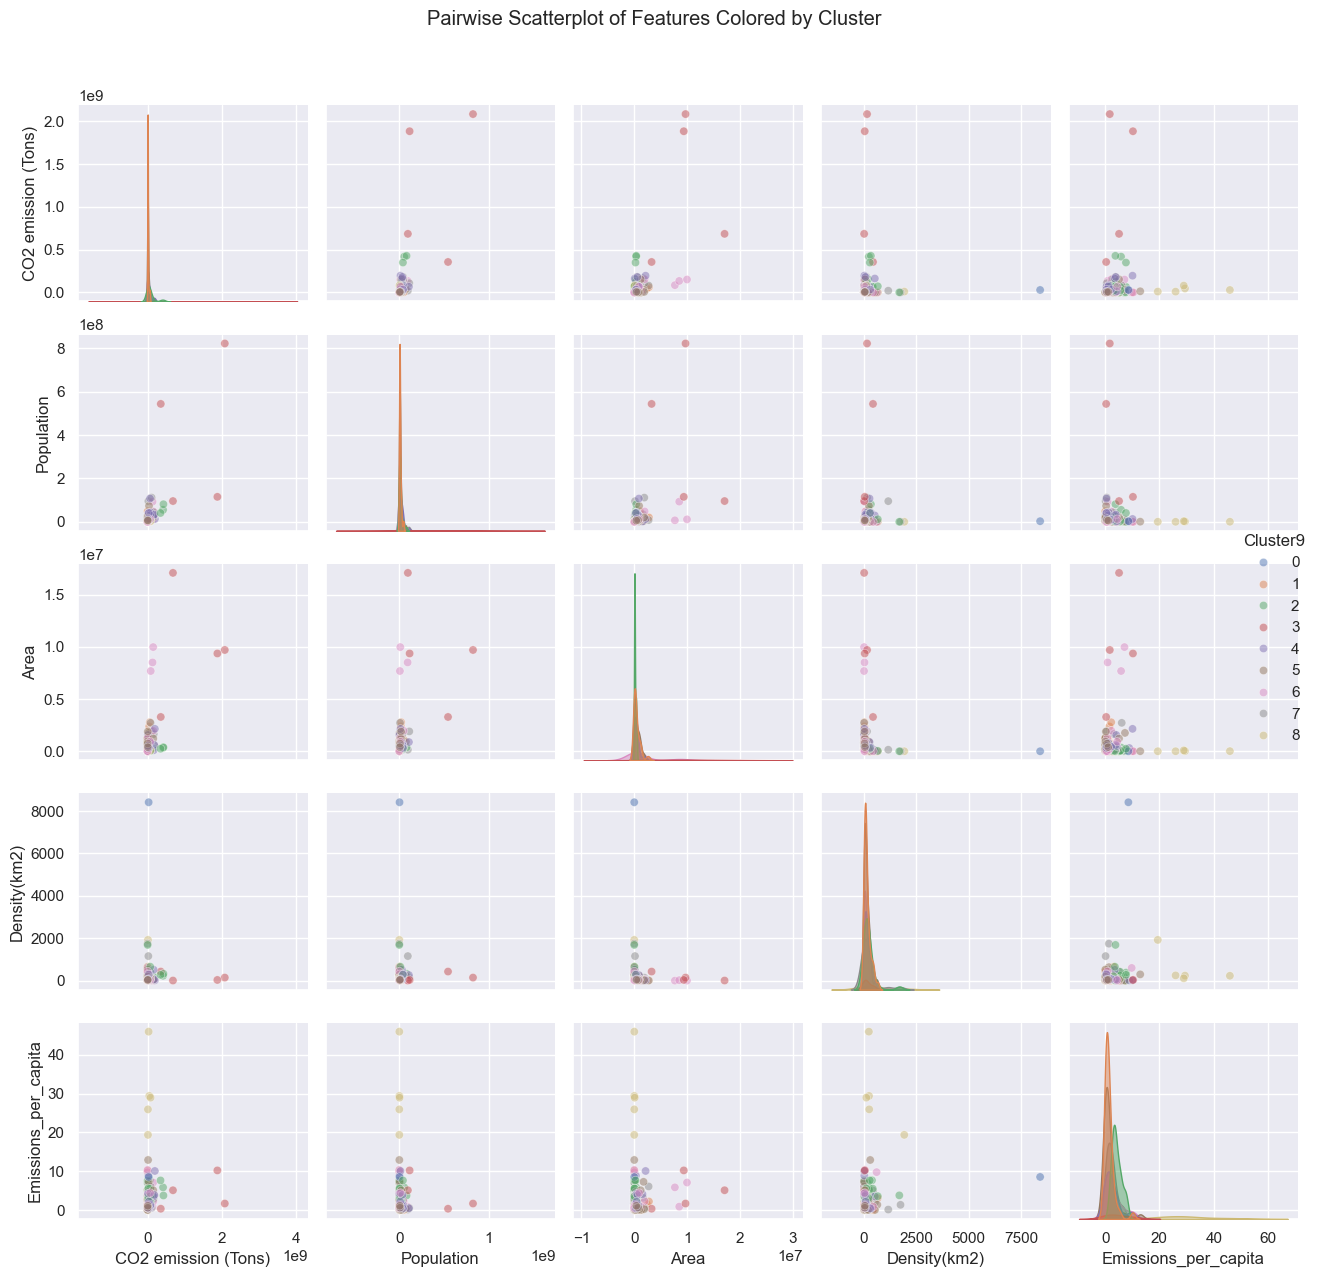

In [1616]:
# Select the relevant features for the scatter plot
features = ["CO2 emission (Tons)", "Population", "Area", "Density(km2)", "Emissions_per_capita"]

# Create a copy of the grouped data with only the selected features and the cluster labels
plot_data = grouped_data[features + ["Cluster9"]].copy() # type: ignore

# Create the pairwise scatter plot
sns.set_theme()
sns.pairplot(plot_data, hue="Cluster9", plot_kws={"alpha": 0.5}, diag_kws={"alpha": 0.5}, palette="deep")
plt.suptitle("Pairwise Scatterplot of Features Colored by Cluster", y=1.02)
plt.tight_layout()
plt.show()

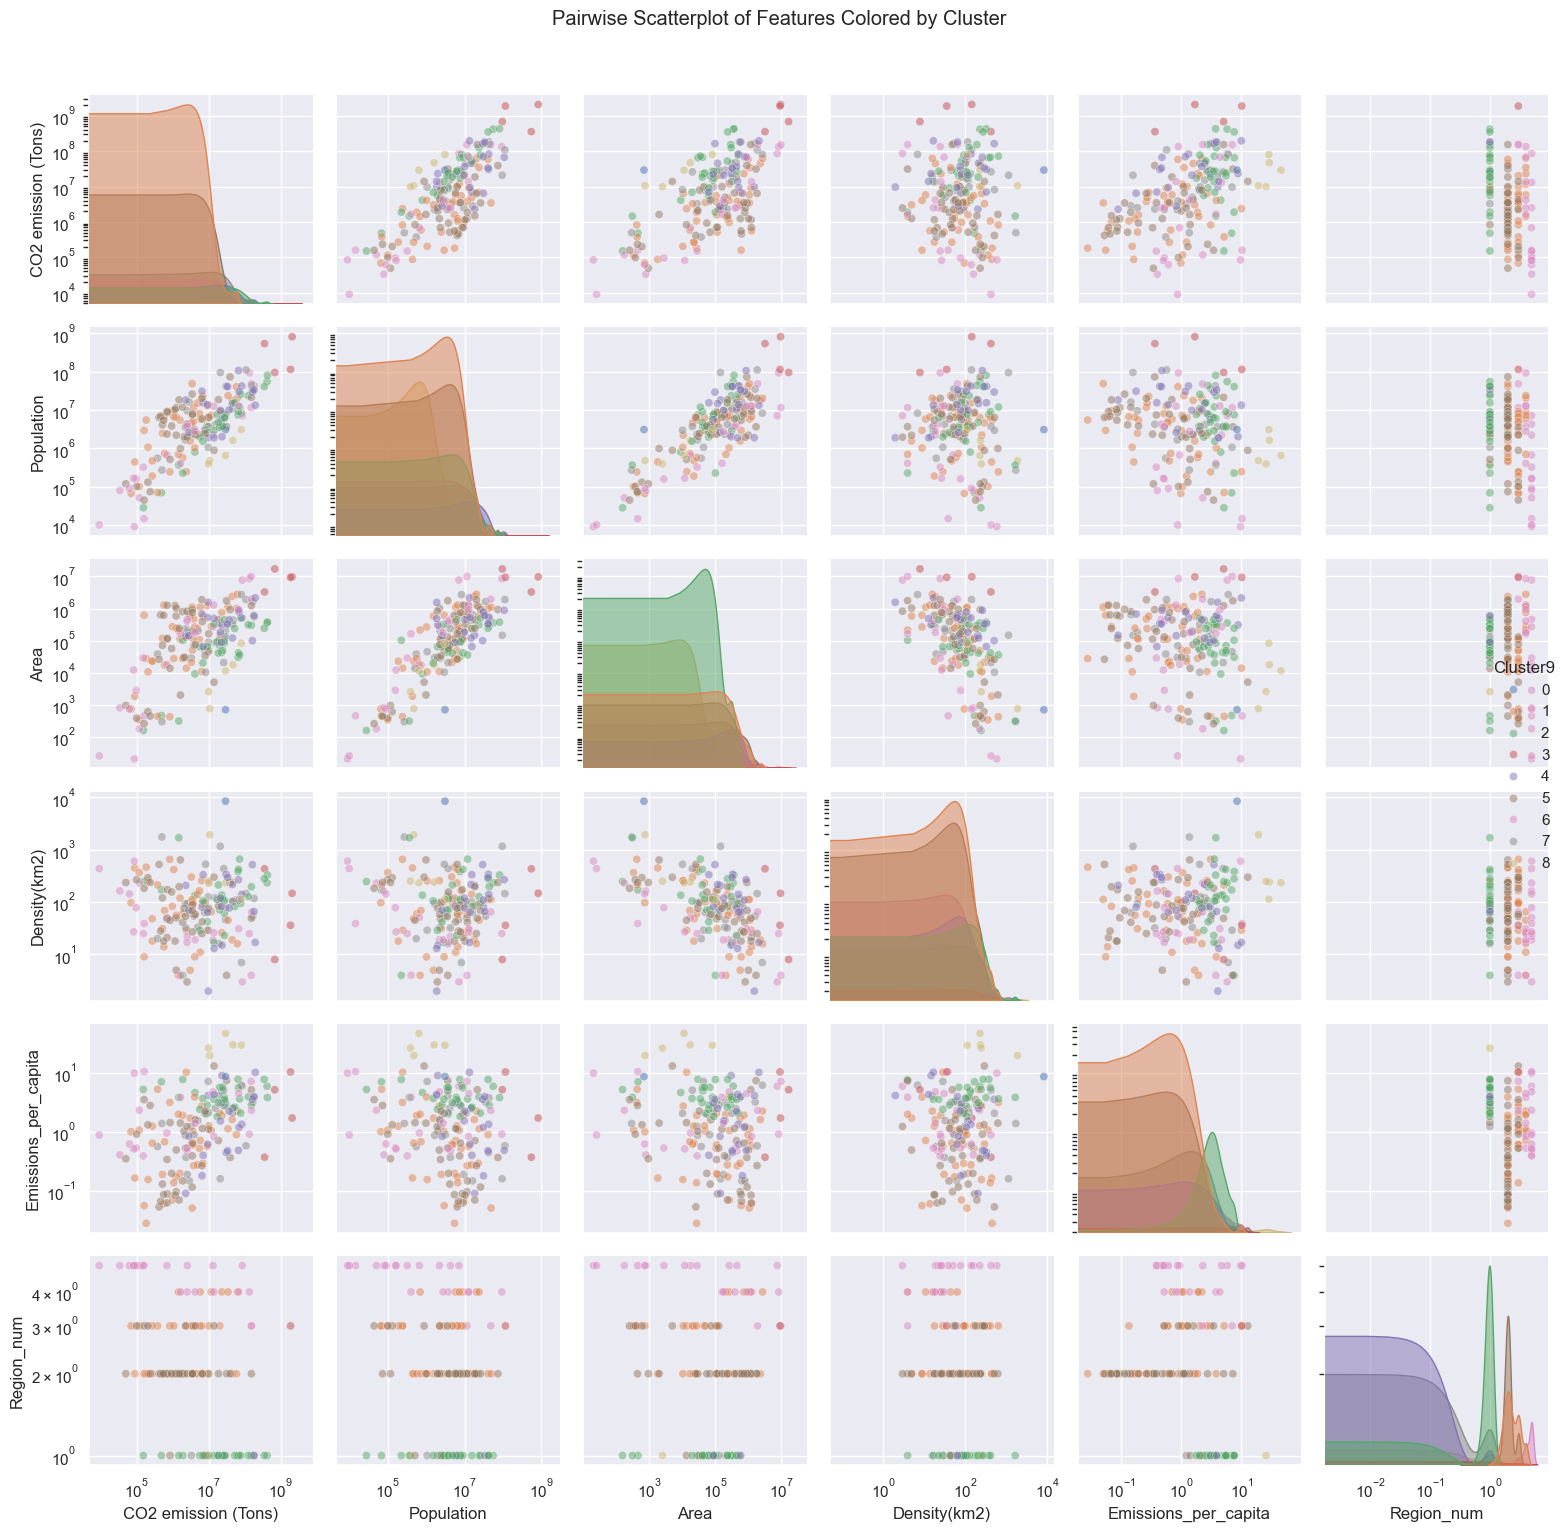

In [1617]:
# Select the relevant features for the scatter plot
features = ["CO2 emission (Tons)", "Population", "Area", "Density(km2)", "Emissions_per_capita", "Region_num"]

# Create a copy of the grouped data with only the selected features and the cluster labels
plot_data = grouped_data[features + ["Cluster9"]].copy() # type: ignore

# Create the pairwise scatter plot
sns.set_theme()
g = sns.pairplot(plot_data, hue="Cluster9", plot_kws={"alpha": 0.5}, diag_kws={"alpha": 0.5}, palette="deep")

# Apply log scale to all axes
for ax in g.axes.flat:
    ax.set_xscale("log")
    ax.set_yscale("log")

plt.suptitle("Pairwise Scatterplot of Features Colored by Cluster", y=1.02)
plt.tight_layout()
plt.show()

### 1.6.3 Selection of features

#### 1.6.3.1 Pickle

##### 1.6.3.1.1 Pickle on local machine

In [1618]:
#with open("clean_data-cluster.pickle", "wb") as f:
    #pickle.dump([grouped_data, plot_data], f)

##### 1.6.3.1.2 Pickle on Google Colab

In [1619]:
#with open(outputFilePath+"clean_data-cluster.pickle", "wb") as f:
#    pickle.dump([grouped_data, plot_data], f)


#### 1.6.3.2 Save data to excel

##### 1.6.3.2.1 Save data to excel on local machine

In [1620]:
#Saving the data in three different excel files
#see: https://pandas.pydata.org/pandas-docs/stable/user_guide/io.html#io-excel-writer
#If you want to save new versions with the same name they will write over the old version.
#But be sure not to have the files open in Excel when you try to create a new version of the file.

import openpyxl

clean_data.to_excel("clean_data.xlsx", sheet_name="clean_data")
grouped_data.to_excel("grouped_data.xlsx", sheet_name="grouped_data") # type: ignore
plot_data.to_excel("plot_data.xlsx", sheet_name="plot_data")

##### 1.6.3.2.2 Save data to excel on Google Colab

In [1621]:
#clean_data.to_excel(outputFilePath+"clean_data.xlsx", sheet_name="clean_data")
#grouped_data.to_excel(outputFilePath+"grouped_data.xlsx", sheet_name="grouped_data")
#plot_data.to_excel(outputFilePath+"plot_data.xlsx", sheet_name="plot_data")


## 1.7 Understanding Data with Tableau

![Persien Gulf](https://images.soulant.com/Top8CountryEmission.png)


After analyzing the data in Tableau, we discovered through visual aids that the countries with the highest emissions were all located around the Persian Gulf. Initially, our group hypothesized that the primary reason for this was the abundance of oil in the region. However, further investigation revealed that while oil was the largest source of emissions for Saudi Arabia, the other countries in the area primarily relied on gas.

![Treemap](https://images.soulant.com/Treemap.jpg)

The treemap confirms the analysis regarding emissions in the region. As the treemap illustrates, Qatar has the highest emissions per capita, and most countries surrounding the Persian Gulf exhibit significant emissions levels.

### Emissions of the world

![World](https://images.soulant.com/world-map.jpg)

When examining the world map and focusing on emissions by country instead of per capita, the map visually confirms the intuitive notion that a country's size influences its emission levels. Besides the emission per country it is also noticeble witch world region that have the higest emission witch is Asia.

### Top 10 Emissions Per Capita With Occuring Year

![Top 10 Max Emissions Per Capita With Occuring Year](https://images.soulant.com/Top_10_max_emissions_per_capita2.png)

When examining the top CO2 emissions by a country during a year we found some interesting instances of countries having a higher than average CO2 emission which could potentially be tied to specific world events. For example the armed conflict in Kuwait 1991 oil deposites were set on fire which led to extremely high CO2 emissions.

### World Map with Average Total Emissions

![World Map with Average Total Emissions](https://images.soulant.com/World_Map_With_Emissions.png)

We also compared the average CO2 emissions per country compared to the average CO2 emissions per capita in countries. We could thereby identify the correlation between large emissions with larger populations whilst some populations in various countries were "worst" if you look at it from an individual perspective.

### World Map with Top 10 Emissions

![World Map with Top 10 Emissions](https://images.soulant.com/World_Map_With_Top_10_Emissions2.png)

Same as the one above, but with the top 10 countries in each category.
